In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import os
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
from scipy.optimize import minimize, LinearConstraint, Bounds

In [ ]:
data_original=pd.read_excel('/content/drive/MyDrive/colab data/investment strategy/data_gross.xlsx')

In [ ]:
data_original

,Unnamed: 0,SGLN LN Equity,Unnamed: 2,Unnamed: 3,XLE US Equity,Unnamed: 5,Unnamed: 6,ITA US Equity,Unnamed: 8,Unnamed: 9,...,Unnamed: 45,IGLS LN Equity,Unnamed: 47,Unnamed: 48,SLXX LN Equity,Unnamed: 50,Unnamed: 51,SCHD US Equity,Unnamed: 53,Unnamed: 54
0,NaN,Last Price,Total Return Index (Gross Dividends),Total Return Index (Net Dividends),Last Price,Total Return Index (Gross Dividends),Total Return Index (Net Dividends),Last Price,Total Return Index (Gross Dividends),Total Return Index (Net Dividends),...,Total Return Index (Net Dividends),Last Price,Total Return Index (Gross Dividends),Total Return Index (Net Dividends),Last Price,Total Return Index (Gross Dividends),Total Return Index (Net Dividends),Last Price,Total Return Index (Gross Dividends),Total Return Index (Net Dividends)
1,Dates,PX_LAST,TOT_RETURN_INDEX_GROSS_DVDS,TOT_RETURN_INDEX_NET_DVDS,PX_LAST,TOT_RETURN_INDEX_GROSS_DVDS,TOT_RETURN_INDEX_NET_DVDS,PX_LAST,TOT_RETURN_INDEX_GROSS_DVDS,TOT_RETURN_INDEX_NET_DVDS,...,TOT_RETURN_INDEX_NET_DVDS,PX_LAST,TOT_RETURN_INDEX_GROSS_DVDS,TOT_RETURN_INDEX_NET_DVDS,PX_LAST,TOT_RETURN_INDEX_GROSS_DVDS,TOT_RETURN_INDEX_NET_DVDS,PX_LAST,TOT_RETURN_INDEX_GROSS_DVDS,TOT_RETURN_INDEX_NET_DVDS
2,2016-01-29 00:00:00,15.575,15.575,15.575,20.46333,20.46333,20.46333,38.46587,38.46587,38.46587,...,100.15,132.98,133.6099,133.6099,132.555,132.555,132.555,8.83077,8.83077,8.83077
3,2016-02-29 00:00:00,17.5025,17.5025,17.5025,20.3335,20.3335,20.3335,40.31122,40.31122,40.31122,...,100.22,133.63,134.263,134.263,131.53,131.53,131.53,9.09461,9.09461,9.09461
4,2016-03-31 00:00:00,16.945,16.945,16.945,21.49854,21.65173,21.65173,40.60372,40.7136,40.7136,...,100.3,133.415,134.047,134.047,135.28,136.4093,136.4093,9.28396,9.35317,9.35317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2025-12-31 00:00:00,62.17,62.17,62.17,33.23669,49.94382,49.94382,159.59709,177.04382,177.04382,...,122.9555,129.15,146.4908,146.4908,123.23,168.9252,168.9252,20.39102,28.47339,28.47339
122,2026-01-30 00:00:00,70.55,70.55,70.55,37.23831,55.95693,55.95693,169.50908,188.03937,188.03937,...,123.187,126.71,146.6339,146.6339,123.49,169.2816,169.2816,21.75213,30.374,30.374
123,2026-02-27 00:00:00,75.41,75.41,75.41,41.54532,62.42895,62.42895,181.06984,200.86391,200.86391,...,123.589,127.75,147.8374,147.8374,124.79,171.0636,171.0636,23.60327,32.95887,32.95887
124,2026-03-31 00:00:00,67.86,67.86,67.86,46.35291,70.10307,70.10307,165.51907,183.73248,183.73248,...,123.8322,125.84,145.6271,145.6271,119.25,165.5505,165.5505,23.21429,32.6884,32.6884


# **Download and clean data**




## Bloomberg Data Cleaning and Return Construction

This section cleans a Bloomberg-style Excel export and converts it into a usable asset-level price and return dataset. Bloomberg exports often store each asset across several adjacent columns, with the actual field names placed inside the first few rows rather than directly in the column headers. Because of this structure, the raw file cannot be used directly for portfolio analysis or return calculation.

The cleaning function first rebuilds the column structure by identifying each asset name and matching it with its corresponding Bloomberg field, such as total return index or last price. It then removes the metadata rows, converts the date column into a proper datetime index, and handles Excel serial dates when necessary.

For each asset, the function selects the most suitable available price series based on a predefined preference order. Total return fields are preferred because they better capture reinvested distributions, while price-only data are used only when total return data are unavailable. After the price matrix is constructed, the function removes duplicate or fully missing assets, sorts the observations by date, and calculates either simple returns or log returns.

The final outputs are a cleaned price matrix, a return matrix, and a summary showing which Bloomberg field was selected for each asset. These outputs can then be used for portfolio optimisation, risk analysis, return estimation, or further statistical testing.

In [ ]:

def clean_bloomberg_data(
    df,
    field_preference=(
        "TOT_RETURN_INDEX_NET_DVDS",
        "TOT_RETURN_INDEX_GROSS_DVDS",
        "PX_LAST"
    ),
    return_type="simple"
):
    """
    Clean a Bloomberg-style export and reshape it into price and return matrices.

    The raw export is expected to contain metadata in the first two rows:
    row 0 usually gives readable field descriptions, while row 1 contains the
    actual Bloomberg field codes. From row 2 onwards, the file contains the
    time-series data.

    The function returns:
    - price_matrix: cleaned price or total return index data by date and asset
    - return_matrix: asset returns calculated from the selected price series
    - selected_fields: the Bloomberg field used for each asset
    """

    df = df.copy()

    # Keep the original column layout before rebuilding the asset-field structure.
    raw_columns = list(df.columns)
    date_col = raw_columns[0]

    # Bloomberg field codes are stored in the second metadata row.
    field_row = df.iloc[1]

    # Rebuild asset names across the repeated Bloomberg columns.
    # In the export, only the first column of each asset usually carries the asset name.
    asset_names = []
    current_asset = None

    for col in raw_columns:
        col_str = str(col)

        if col == date_col:
            asset_names.append("Dates")

        elif not col_str.startswith("Unnamed"):
            current_asset = col_str
            asset_names.append(current_asset)

        else:
            asset_names.append(current_asset)

    # Match each column with its Bloomberg field code.
    fields = []

    for col in raw_columns:
        if col == date_col:
            fields.append("Dates")
        else:
            fields.append(str(field_row[col]).strip())

    # Use a MultiIndex so each column can be addressed by asset and field.
    df.columns = pd.MultiIndex.from_arrays(
        [asset_names, fields],
        names=["Asset", "Field"]
    )

    # Remove the two Bloomberg metadata rows and keep only observations.
    data = df.iloc[2:].copy()

    # Clean the date column before using it as the index.
    dates_raw = data[("Dates", "Dates")]

    # Bloomberg exports may store dates as Excel serial numbers,
    # so mostly numeric date columns are handled separately.
    dates_num = pd.to_numeric(dates_raw, errors="coerce")

    if dates_num.notna().mean() > 0.8:
        dates = pd.to_datetime(
            dates_num,
            origin="1899-12-30",
            unit="D",
            errors="coerce"
        )
    else:
        dates = pd.to_datetime(
            dates_raw,
            errors="coerce"
        )

    data.index = dates
    data.index.name = "Date"

    # The date column is no longer needed once it has become the index.
    data = data.drop(columns=[("Dates", "Dates")])

    # Drop rows where the date could not be parsed.
    data = data[~data.index.isna()]

    # Convert the remaining Bloomberg values into numeric series.
    data = data.apply(pd.to_numeric, errors="coerce")

    # For each asset, take the first usable field based on the preference order.
    price_dict = {}
    selected_fields = {}

    assets = data.columns.get_level_values("Asset").unique()

    for asset in assets:
        asset_data = data[asset]

        for field in field_preference:
            if field in asset_data.columns:
                series = asset_data[field]

                if series.notna().sum() > 0:
                    price_dict[asset] = series
                    selected_fields[asset] = field
                    break

        if asset not in selected_fields:
            print(f"Warning: no usable field found for {asset}")

    price_matrix = pd.DataFrame(price_dict)

    # Remove repeated asset columns if the export contains duplicates.
    price_matrix = price_matrix.loc[:, ~price_matrix.columns.duplicated()]

    # Sort the time series into chronological order.
    price_matrix = price_matrix.sort_index()

    # Remove assets that do not contain any valid observations.
    price_matrix = price_matrix.dropna(axis=1, how="all")

    # Calculate returns using the requested return definition.
    if return_type == "simple":
        return_matrix = price_matrix.pct_change()

    elif return_type == "log":
        return_matrix = np.log(price_matrix / price_matrix.shift(1))

    else:
        raise ValueError("return_type must be either 'simple' or 'log'")

    return_matrix = return_matrix.dropna(how="all")

    # Store the selected Bloomberg field for checking and reporting.
    selected_fields = pd.Series(
        selected_fields,
        name="Selected Bloomberg Field"
    )

    return price_matrix, return_matrix, selected_fields

In [ ]:
price_matrix, returns, selected_fields = clean_bloomberg_data(
    data_original,
    return_type="simple"
)

print(price_matrix.head())
print(returns.head())
print(selected_fields)

            SGLN LN Equity  XLE US Equity  ITA US Equity  TAIL US Equity  \
Date                                                                       
2016-01-29         15.5750       20.46333       38.46587             NaN   
2016-02-29         17.5025       20.33350       40.31122             NaN   
2016-03-31         16.9450       21.65173       40.71360             NaN   
2016-04-29         17.4525       23.23976       41.77485             NaN   
2016-05-31         16.4650       23.19892       42.84038             NaN   

            LT09TRUU Index  LSG1TRGU Index  WTMF US Equity  QAI US Equity  \
Date                                                                        
2016-01-29          452.08        249.3393        29.05857       19.72861   
2016-02-29          458.83        253.0784        30.71947       20.24006   
2016-03-31          458.72        252.6927        29.08851       20.02223   
2016-04-29          458.36        249.3900        29.36551       19.86873   
2016-

In [ ]:
start_date = "2017-05-01"
returns = returns.loc[returns.index >= start_date]


In [ ]:
returns

,SGLN LN Equity,XLE US Equity,ITA US Equity,TAIL US Equity,LT09TRUU Index,LSG1TRGU Index,WTMF US Equity,QAI US Equity,TAIL US Equity.1,XLP US Equity,BRK/B US Equity,ULVR LN Equity,ITPS LN Equity,INXG LN Equity,ERNS LN Equity,IGLS LN Equity,SLXX LN Equity,SCHD US Equity
Date,,,,,,,,,,,,,,,,,,
2017-05-31,0.002591,-0.030887,0.031117,0.006625,0.008671,0.004811,-0.004179,0.009134,0.006625,0.031237,0.005080,0.098739,0.004216,-0.018268,0.000648,0.000038,0.015995,0.022190
2017-06-30,-0.025846,-0.010286,-0.009566,-0.026841,-0.005899,-0.020784,-0.021612,-0.005012,-0.026841,-0.031326,0.015450,-0.040766,-0.013678,-0.026916,0.000624,-0.005441,-0.012626,-0.010053
2017-07-31,0.005572,0.012027,0.033522,-0.034898,0.003794,0.003036,-0.023405,-0.004744,-0.034898,-0.006977,0.018809,0.040080,-0.011126,-0.014960,0.000598,0.002337,0.010703,0.002602
2017-08-31,0.062533,-0.033090,0.060550,0.044034,0.014659,0.020606,0.026272,0.028126,0.044034,0.011677,0.059146,0.053391,0.033363,0.048134,0.000399,0.002810,0.009164,0.022733
2017-09-29,-0.063323,0.060586,0.006467,-0.065757,-0.013761,-0.027290,-0.036786,-0.035788,-0.065757,-0.044294,-0.025925,-0.044259,-0.043237,-0.041005,0.000000,-0.008666,-0.019705,-0.010006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,0.007128,-0.018981,0.030028,-0.034465,-0.005811,0.002498,-0.015516,-0.010666,-0.034465,-0.029182,-0.037356,-0.002665,-0.020223,0.006769,0.004499,0.004981,0.005648,-0.011817
2026-01-30,0.134792,0.120397,0.062106,-0.023871,-0.004072,-0.001603,-0.024167,0.004123,-0.023871,0.054898,-0.061929,0.016678,-0.016217,0.010434,0.001883,0.000977,0.002110,0.066750
2026-02-27,0.068887,0.115661,0.068201,0.043896,0.024968,0.025024,0.067525,0.036588,0.043896,0.097774,0.070258,0.114930,0.031685,0.036770,0.003263,0.008208,0.010527,0.085101


# Optimization

## Portfolio Optimisation Model

This code builds and tests a constrained portfolio optimisation model. It uses monthly asset returns, groups the assets into several portfolio sleeves, and sets allocation limits for both individual assets and categories.

The model compares three objective profiles: Conservative, Base Case, and Return Aware. Each profile gives different weights to downside risk, drawdown risk, expected return, and diversification. After optimisation, the code reports asset weights, category weights, portfolio risk-return metrics, and risk contribution.

The Base Case portfolio is selected as the final allocation.

In [ ]:



# Asset universe used in the optimisation
asset_cols = [
    "SGLN LN Equity",
    "XLE US Equity",
    "ITA US Equity",
    "TAIL US Equity",
    "LT09TRUU Index",
    "LSG1TRGU Index",
    "WTMF US Equity",
    "QAI US Equity",
    "XLP US Equity",
    "BRK/B US Equity",
    "ULVR LN Equity",
    "ITPS LN Equity",
    "INXG LN Equity",
    "ERNS LN Equity",
    "IGLS LN Equity",
    "SLXX LN Equity",
    "SCHD US Equity"
]

R = returns[asset_cols].copy()
R = R.apply(pd.to_numeric, errors="coerce")
R = R.dropna()

T, N = R.shape
R_mat = R.values

print("Number of observations:", T)
print("Number of assets:", N)


# Portfolio sleeves and their underlying assets
categories = {
    "Geopolitical Hedge": [
        "SGLN LN Equity",
        "XLE US Equity",
        "ITA US Equity",
        "TAIL US Equity"
    ],
    "Recession Protection": [
        "LT09TRUU Index",
        "LSG1TRGU Index"
    ],
    "Liquid Alternatives": [
        "WTMF US Equity",
        "QAI US Equity"
    ],
    "Defensive Growth": [
        "XLP US Equity",
        "BRK/B US Equity",
        "ULVR LN Equity",
        "SCHD US Equity"
    ],
    "Inflation Hedge": [
        "ITPS LN Equity",
        "INXG LN Equity"
    ],
    "Liquidity Reserve": [
        "ERNS LN Equity",
        "IGLS LN Equity"
    ],
    "Income / Carry": [
        "SLXX LN Equity"
    ]
}

# Minimum and maximum allocation allowed for each sleeve
category_bounds = {
    "Geopolitical Hedge": (0.10, 0.20),
    "Recession Protection": (0.18, 0.30),
    "Liquid Alternatives": (0.05, 0.12),
    "Defensive Growth": (0.15, 0.25),
    "Inflation Hedge": (0.08, 0.15),
    "Liquidity Reserve": (0.15, 0.25),
    "Income / Carry": (0.03, 0.08)
}

# Assets treated as equity-like exposure
equity_like_assets = [
    "XLE US Equity",
    "ITA US Equity",
    "XLP US Equity",
    "BRK/B US Equity",
    "ULVR LN Equity",
    "SCHD US Equity"
]


# Main model settings
alpha = 0.95

# Alternative objective profiles for sensitivity testing
objective_profiles = {
    "Conservative": {
        "lambda_cvar": 0.45,
        "lambda_cdar": 0.30,
        "lambda_return": 0.10,
        "lambda_hhi": 0.15
    },
    "Base Case": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15
    },
    "Return Aware": {
        "lambda_cvar": 0.25,
        "lambda_cdar": 0.20,
        "lambda_return": 0.40,
        "lambda_hhi": 0.15
    }
}


# Helper functions
def idx(asset):
    return asset_cols.index(asset)

def indices(asset_list):
    return [idx(a) for a in asset_list]

def portfolio_returns_from_weights(w):
    return R_mat @ w

def historical_cvar(portfolio_returns, alpha=0.95):
    losses = -portfolio_returns
    var = np.quantile(losses, alpha)
    cvar = losses[losses >= var].mean()
    return cvar

def additive_cdar(portfolio_returns, alpha=0.95):
    """
    Estimate CDaR using cumulative additive returns.
    This matches the linear drawdown structure used later in the optimisation.
    """
    cum_ret = np.cumsum(portfolio_returns)
    running_max = np.maximum.accumulate(np.maximum(cum_ret, 0))
    drawdowns = running_max - cum_ret
    dar = np.quantile(drawdowns, alpha)
    cdar = drawdowns[drawdowns >= dar].mean()
    return cdar

def compounded_drawdown_metrics(portfolio_returns, alpha=0.95):
    """
    Calculate drawdown measures from compounded wealth.
    These are used for reporting rather than for the optimisation constraints.
    """
    wealth = pd.Series(1 + portfolio_returns).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    mdd = drawdown.min()

    dd_positive = -drawdown
    dar = np.quantile(dd_positive, alpha)
    cdar = dd_positive[dd_positive >= dar].mean()

    return mdd, cdar

def annualised_geometric_return(portfolio_returns):
    return (1 + portfolio_returns).prod() ** (12 / len(portfolio_returns)) - 1

def annualised_volatility(portfolio_returns):
    return portfolio_returns.std(ddof=1) * np.sqrt(12)

def sortino_ratio(portfolio_returns, target=0.0):
    ann_ret = annualised_geometric_return(portfolio_returns)
    downside = portfolio_returns[portfolio_returns < target]
    if len(downside) <= 1:
        return np.nan
    downside_vol = downside.std(ddof=1) * np.sqrt(12)
    return ann_ret / downside_vol if downside_vol > 0 else np.nan

def hhi(w):
    return np.sum(w ** 2)

def effective_number_of_assets(w):
    return 1 / hhi(w)


# Starting portfolio used as a feasible benchmark
strategic_weights = {
    "Geopolitical Hedge": 0.16,
    "Recession Protection": 0.22,
    "Liquid Alternatives": 0.08,
    "Defensive Growth": 0.19,
    "Inflation Hedge": 0.12,
    "Liquidity Reserve": 0.18,
    "Income / Carry": 0.05
}

w0 = np.zeros(N)

for cat, cat_weight in strategic_weights.items():
    asset_list = categories[cat]
    equal_weight = cat_weight / len(asset_list)
    for a in asset_list:
        w0[idx(a)] = equal_weight

# Check that the starting allocation is fully invested.
assert np.isclose(w0.sum(), 1.0), "Initial weights do not sum to 1."


# Benchmark values used to scale the objective function
rp_bench = portfolio_returns_from_weights(w0)

cvar_bench = historical_cvar(rp_bench, alpha)
cdar_bench = additive_cdar(rp_bench, alpha)
mu_annual = R.mean().values * 12
mu_bench = float(mu_annual @ w0)
hhi_bench = 1 / N

eps = 1e-8

cvar_scale = max(abs(cvar_bench), eps)
cdar_scale = max(abs(cdar_bench), eps)
mu_scale = max(abs(mu_bench), eps)
hhi_scale = hhi_bench

print("\nBenchmark scaling values:")
print("CVaR scale:", round(cvar_scale, 6))
print("CDaR scale:", round(cdar_scale, 6))
print("Annual return scale:", round(mu_scale, 6))
print("HHI scale:", round(hhi_scale, 6))


# Position of each variable block inside the decision vector
w_start = 0
eta_idx = N
u_start = N + 1
zeta_idx = N + 1 + T
v_start = zeta_idx + 1
M_start = v_start + T
d_start = M_start + T

num_vars = N + 2 + 4 * T


# Linear constraints for weights, CVaR, CDaR, and sleeve limits
A_rows = []
lb_rows = []
ub_rows = []

# Portfolio weights must sum to one.
row = np.zeros(num_vars)
row[:N] = 1.0
A_rows.append(row)
lb_rows.append(1.0)
ub_rows.append(1.0)

# CVaR auxiliary constraints.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = R_mat[t, :]
    row[eta_idx] = 1.0
    row[u_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Cumulative return matrix used for the CDaR formulation.
C_mat = np.cumsum(R_mat, axis=0)

# Running maximum must be at least as large as cumulative return.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = -C_mat[t, :]
    row[M_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Running maximum cannot decrease over time.
for t in range(1, T):
    row = np.zeros(num_vars)
    row[M_start + t] = 1.0
    row[M_start + t - 1] = -1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Drawdown must be at least the gap between running maximum and cumulative return.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = C_mat[t, :]
    row[M_start + t] = -1.0
    row[d_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# CDaR auxiliary constraints.
for t in range(T):
    row = np.zeros(num_vars)
    row[zeta_idx] = 1.0
    row[v_start + t] = 1.0
    row[d_start + t] = -1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Sleeve allocation constraints.
for cat, asset_list in categories.items():
    row = np.zeros(num_vars)
    row[indices(asset_list)] = 1.0
    lower, upper = category_bounds[cat]

    A_rows.append(row)
    lb_rows.append(lower)
    ub_rows.append(upper)

# Overall cap on equity-like exposure.
row = np.zeros(num_vars)
row[indices(equity_like_assets)] = 1.0
A_rows.append(row)
lb_rows.append(0.0)
ub_rows.append(0.35)

A = np.vstack(A_rows)
lb = np.array(lb_rows)
ub = np.array(ub_rows)

linear_constraints = LinearConstraint(A, lb, ub)


# Bounds for all decision variables
lower_bounds = np.full(num_vars, -np.inf)
upper_bounds = np.full(num_vars, np.inf)

# General asset weight bounds
for i, asset in enumerate(asset_cols):
    lower_bounds[i] = 0.0
    upper_bounds[i] = 0.12

# Asset-level bounds reflecting portfolio construction rules
specific_bounds = {
    "SGLN LN Equity": (0.00, 0.12),
    "XLE US Equity": (0.00, 0.08),
    "ITA US Equity": (0.00, 0.08),
    "TAIL US Equity": (0.02, 0.05),

    "LT09TRUU Index": (0.00, 0.18),
    "LSG1TRGU Index": (0.00, 0.18),

    "WTMF US Equity": (0.00, 0.10),
    "QAI US Equity": (0.00, 0.08),

    "XLP US Equity": (0.00, 0.08),
    "BRK/B US Equity": (0.00, 0.05),
    "ULVR LN Equity": (0.00, 0.05),
    "SCHD US Equity": (0.00, 0.08),

    "ITPS LN Equity": (0.00, 0.10),
    "INXG LN Equity": (0.00, 0.10),

    "ERNS LN Equity": (0.00, 0.18),
    "IGLS LN Equity": (0.00, 0.15),

    "SLXX LN Equity": (0.00, 0.08)
}

for asset, (lo, hi) in specific_bounds.items():
    i = idx(asset)
    lower_bounds[i] = lo
    upper_bounds[i] = hi

# Optional minimum weights for selected functional assets
USE_FUNCTIONAL_MINIMUMS = False

functional_minimums = {
    "ITA US Equity": 0.01,
    "QAI US Equity": 0.01,
    "LSG1TRGU Index": 0.03,
    "INXG LN Equity": 0.02,
    "IGLS LN Equity": 0.02,
    "XLP US Equity": 0.02
}

if USE_FUNCTIONAL_MINIMUMS:
    for asset, lo in functional_minimums.items():
        lower_bounds[idx(asset)] = max(lower_bounds[idx(asset)], lo)

# Bounds for CVaR and CDaR auxiliary variables
lower_bounds[eta_idx] = -np.inf
upper_bounds[eta_idx] = np.inf

lower_bounds[u_start:u_start + T] = 0.0
upper_bounds[u_start:u_start + T] = np.inf

lower_bounds[zeta_idx] = 0.0
upper_bounds[zeta_idx] = np.inf

lower_bounds[v_start:v_start + T] = 0.0
upper_bounds[v_start:v_start + T] = np.inf

lower_bounds[M_start:M_start + T] = 0.0
upper_bounds[M_start:M_start + T] = np.inf

lower_bounds[d_start:d_start + T] = 0.0
upper_bounds[d_start:d_start + T] = np.inf

bounds = Bounds(lower_bounds, upper_bounds)


# Build a feasible starting point for the optimiser
def build_initial_x(w_init):
    rp = R_mat @ w_init

    losses = -rp
    eta0 = np.quantile(losses, alpha)
    u0 = np.maximum(losses - eta0, 0)

    cum_ret = np.cumsum(rp)
    M0 = np.maximum.accumulate(np.maximum(cum_ret, 0))
    d0 = M0 - cum_ret

    zeta0 = np.quantile(d0, alpha)
    v0 = np.maximum(d0 - zeta0, 0)

    x0 = np.zeros(num_vars)
    x0[:N] = w_init
    x0[eta_idx] = eta0
    x0[u_start:u_start + T] = u0
    x0[zeta_idx] = zeta0
    x0[v_start:v_start + T] = v0
    x0[M_start:M_start + T] = M0
    x0[d_start:d_start + T] = d0

    return x0

x0 = build_initial_x(w0)

# Keep the starting point inside the specified bounds.
x0 = np.maximum(x0, lower_bounds)
x0 = np.minimum(x0, upper_bounds)


# Objective function and its gradient
def objective(x, profile):
    w = x[:N]
    eta = x[eta_idx]
    u = x[u_start:u_start + T]
    zeta = x[zeta_idx]
    v = x[v_start:v_start + T]

    cvar_term = eta + np.sum(u) / ((1 - alpha) * T)
    cdar_term = zeta + np.sum(v) / ((1 - alpha) * T)
    return_term = mu_annual @ w
    hhi_term = np.sum(w ** 2)

    J = (
        profile["lambda_cvar"] * (cvar_term / cvar_scale)
        + profile["lambda_cdar"] * (cdar_term / cdar_scale)
        - profile["lambda_return"] * (return_term / mu_scale)
        + profile["lambda_hhi"] * (hhi_term / hhi_scale)
    )

    return J

def objective_grad(x, profile):
    grad = np.zeros_like(x)
    w = x[:N]

    # Weight-related gradient terms
    grad[:N] += -profile["lambda_return"] * mu_annual / mu_scale
    grad[:N] += profile["lambda_hhi"] * (2 * w) / hhi_scale

    # CVaR gradient terms
    grad[eta_idx] += profile["lambda_cvar"] / cvar_scale
    grad[u_start:u_start + T] += (
        profile["lambda_cvar"]
        / cvar_scale
        / ((1 - alpha) * T)
    )

    # CDaR gradient terms
    grad[zeta_idx] += profile["lambda_cdar"] / cdar_scale
    grad[v_start:v_start + T] += (
        profile["lambda_cdar"]
        / cdar_scale
        / ((1 - alpha) * T)
    )

    return grad


# Run the optimisation for one objective profile
def run_optimisation(profile_name, profile):
    result = minimize(
        fun=lambda x: objective(x, profile),
        x0=x0,
        jac=lambda x: objective_grad(x, profile),
        method="SLSQP",
        bounds=bounds,
        constraints=[linear_constraints],
        options={
            "ftol": 1e-10,
            "maxiter": 2000,
            "disp": False
        }
    )

    if not result.success:
        raise RuntimeError(
            f"Optimisation failed for {profile_name}: {result.message}"
        )

    x_opt = result.x
    w_opt = pd.Series(x_opt[:N], index=asset_cols, name=profile_name)

    return result, w_opt


# Portfolio performance and risk statistics
def evaluate_portfolio(w_series):
    w = w_series.values
    rp = R @ w_series
    losses = -rp

    ann_ret = annualised_geometric_return(rp.values)
    ann_vol = annualised_volatility(rp.values)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    sortino = sortino_ratio(rp.values)

    mdd, cdar_compounded = compounded_drawdown_metrics(rp.values, alpha)

    var95 = np.quantile(losses, alpha)
    cvar95 = losses[losses >= var95].mean()

    cdar_add = additive_cdar(rp.values, alpha)

    hhi_value = hhi(w)
    eff_n = effective_number_of_assets(w)

    metrics = pd.Series({
        "Annualised Return": ann_ret,
        "Annualised Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": mdd,
        "VaR 95% monthly": var95,
        "CVaR 95% monthly": cvar95,
        "CDaR 95% additive": cdar_add,
        "CDaR 95% compounded": cdar_compounded,
        "HHI": hhi_value,
        "Effective Number of Assets": eff_n
    })

    return metrics

def category_weight_table(w_series):
    out = {}
    for cat, asset_list in categories.items():
        out[cat] = w_series[asset_list].sum()
    return pd.Series(out, name=w_series.name)

def risk_contribution_table(w_series):
    cov_ann = R.cov() * 12
    w = w_series.values

    port_vol = np.sqrt(w.T @ cov_ann.values @ w)

    marginal_contribution = cov_ann.values @ w / port_vol
    component_contribution = w * marginal_contribution
    risk_contribution_pct = component_contribution / port_vol

    table = pd.DataFrame({
        "Weight": w_series,
        "Weight (%)": w_series * 100,
        "Risk Contribution (%)": risk_contribution_pct * 100
    })

    table["Category"] = [
        next(cat for cat, assets in categories.items() if asset in assets)
        for asset in table.index
    ]

    return table

def category_risk_contribution_table(asset_rc_table):
    return asset_rc_table.groupby("Category")[[
        "Weight (%)",
        "Risk Contribution (%)"
    ]].sum()


# Run all objective profiles and store the outputs
results = {}
weights_all = {}
metrics_all = {}
category_weights_all = {}
risk_contributions_all = {}
category_risk_contributions_all = {}

for profile_name, profile in objective_profiles.items():
    result, w_opt = run_optimisation(profile_name, profile)

    results[profile_name] = result
    weights_all[profile_name] = w_opt
    metrics_all[profile_name] = evaluate_portfolio(w_opt)
    category_weights_all[profile_name] = category_weight_table(w_opt)
    risk_contributions_all[profile_name] = risk_contribution_table(w_opt)
    category_risk_contributions_all[profile_name] = category_risk_contribution_table(
        risk_contributions_all[profile_name]
    )

    print(f"\n================ {profile_name} ================")
    print("\nOptimised asset weights (%):")
    print((w_opt * 100).round(2))

    print("\nCategory weights (%):")
    print((category_weights_all[profile_name] * 100).round(2))

    print("\nPortfolio metrics:")
    print(metrics_all[profile_name].round(4))

    print("\nCategory risk contribution:")
    print(category_risk_contributions_all[profile_name].round(2))


# Compare weights, metrics, and category allocations across profiles
weights_df = pd.concat(weights_all.values(), axis=1)
weights_df_pct = weights_df * 100

metrics_df = pd.concat(metrics_all.values(), axis=1)
category_weights_df = pd.concat(category_weights_all.values(), axis=1) * 100

print("\n\n================ Weight Comparison (%) ================")
print(weights_df_pct.round(2))

print("\n\n================ Metrics Comparison ================")
print(metrics_df.round(4))

print("\n\n================ Category Weight Comparison (%) ================")
print(category_weights_df.round(2))


# Select the final portfolio for reporting
final_profile = "Base Case"
final_weights = weights_all[final_profile]
final_metrics = metrics_all[final_profile]
final_rc = risk_contributions_all[final_profile]
final_category_rc = category_risk_contributions_all[final_profile]

final_results = pd.DataFrame({
    "Asset": asset_cols,
    "Category": [
        next(cat for cat, assets in categories.items() if asset in assets)
        for asset in asset_cols
    ],
    "Final Weight": final_weights.values,
    "Final Weight (%)": final_weights.values * 100,
    "Risk Contribution (%)": final_rc["Risk Contribution (%)"].values
})

print("\n\n================ Final Selected Portfolio: Base Case ================")
print(final_results.round(4))

print("\nFinal portfolio metrics:")
print(final_metrics.round(4))

print("\nFinal category risk contribution:")
print(final_category_rc.round(2))

Number of observations: 108
Number of assets: 17

Benchmark scaling values:
CVaR scale: 0.026853
CDaR scale: 0.047742
Annual return scale: 0.038536
HHI scale: 0.058824


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:699: OptimizeWarning: Equality and inequality constraints are specified in the same element of the constraint list. For efficient use with this method, equality and inequality constraints should be specified in separate elements of the constraint list. 
  constraints = standardize_constraints(constraints, x0, meth)



================ Conservative ================

Optimised asset weights (%):
SGLN LN Equity      9.84
XLE US Equity       3.78
ITA US Equity       0.00
TAIL US Equity      2.44
LT09TRUU Index     13.55
LSG1TRGU Index      4.89
WTMF US Equity      5.85
QAI US Equity       6.15
XLP US Equity       2.00
BRK/B US Equity     5.00
ULVR LN Equity      0.00
ITPS LN Equity      8.00
INXG LN Equity      0.00
ERNS LN Equity     14.90
IGLS LN Equity     10.10
SLXX LN Equity      5.51
SCHD US Equity      8.00
Name: Conservative, dtype: float64

Category weights (%):
Geopolitical Hedge      16.05
Recession Protection    18.44
Liquid Alternatives     12.00
Defensive Growth        15.00
Inflation Hedge          8.00
Liquidity Reserve       25.00
Income / Carry           5.51
Name: Conservative, dtype: float64

Portfolio metrics:
Annualised Return              0.0487
Annualised Volatility          0.0418
Sharpe Ratio                   1.1666
Sortino Ratio                  2.2628
Maximum Drawdown      

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:699: OptimizeWarning: Equality and inequality constraints are specified in the same element of the constraint list. For efficient use with this method, equality and inequality constraints should be specified in separate elements of the constraint list. 
  constraints = standardize_constraints(constraints, x0, meth)



================ Base Case ================

Optimised asset weights (%):
SGLN LN Equity     12.00
XLE US Equity       4.58
ITA US Equity       0.40
TAIL US Equity      2.00
LT09TRUU Index     13.73
LSG1TRGU Index      4.27
WTMF US Equity      6.09
QAI US Equity       5.30
XLP US Equity       3.74
BRK/B US Equity     5.00
ULVR LN Equity      0.00
ITPS LN Equity      8.00
INXG LN Equity      0.00
ERNS LN Equity     14.10
IGLS LN Equity      9.79
SLXX LN Equity      3.00
SCHD US Equity      8.00
Name: Base Case, dtype: float64

Category weights (%):
Geopolitical Hedge      18.98
Recession Protection    18.00
Liquid Alternatives     11.39
Defensive Growth        16.74
Inflation Hedge          8.00
Liquidity Reserve       23.90
Income / Carry           3.00
Name: Base Case, dtype: float64

Portfolio metrics:
Annualised Return              0.0548
Annualised Volatility          0.0442
Sharpe Ratio                   1.2394
Sortino Ratio                  2.3861
Maximum Drawdown              -

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:699: OptimizeWarning: Equality and inequality constraints are specified in the same element of the constraint list. For efficient use with this method, equality and inequality constraints should be specified in separate elements of the constraint list. 
  constraints = standardize_constraints(constraints, x0, meth)



================ Return Aware ================

Optimised asset weights (%):
SGLN LN Equity     12.00
XLE US Equity       4.81
ITA US Equity       1.19
TAIL US Equity      2.00
LT09TRUU Index     13.91
LSG1TRGU Index      4.09
WTMF US Equity      6.90
QAI US Equity       5.10
XLP US Equity       8.00
BRK/B US Equity     5.00
ULVR LN Equity      0.00
ITPS LN Equity      8.00
INXG LN Equity      0.00
ERNS LN Equity     11.32
IGLS LN Equity      6.68
SLXX LN Equity      3.00
SCHD US Equity      8.00
Name: Return Aware, dtype: float64

Category weights (%):
Geopolitical Hedge      20.0
Recession Protection    18.0
Liquid Alternatives     12.0
Defensive Growth        21.0
Inflation Hedge          8.0
Liquidity Reserve       18.0
Income / Carry           3.0
Name: Return Aware, dtype: float64

Portfolio metrics:
Annualised Return              0.0589
Annualised Volatility          0.0486
Sharpe Ratio                   1.2124
Sortino Ratio                  2.3345
Maximum Drawdown             

## Main Improvements

This version improves the model by adding a risk-contribution penalty, so that the portfolio does not rely too heavily on the Geopolitical Hedge sleeve, the Defensive Growth sleeve, or their combined exposure.

It also adds a 1.5% minimum weight for every asset, which keeps all selected assets in the final portfolio and improves diversification.

The model now compares four versions of the Base Case: no risk-contribution penalty, low penalty, medium penalty, and high penalty. This helps show how different levels of risk-control affect asset weights, portfolio performance, and risk contribution.

The constraint structure is also clearer because equality and inequality constraints are separated. In addition, the reporting section now includes category-level risk contribution and the risk-contribution penalty, making the final portfolio easier to evaluate.

The final selected portfolio is changed to Base RC Medium, because it provides a more balanced result across return, downside risk, diversification, and risk-contribution control.

In [ ]:

# Asset universe used in the optimisation
asset_cols = [
    "SGLN LN Equity",
    "XLE US Equity",
    "ITA US Equity",
    "TAIL US Equity",
    "LT09TRUU Index",
    "LSG1TRGU Index",
    "WTMF US Equity",
    "QAI US Equity",
    "XLP US Equity",
    "BRK/B US Equity",
    "ULVR LN Equity",
    "ITPS LN Equity",
    "INXG LN Equity",
    "ERNS LN Equity",
    "IGLS LN Equity",
    "SLXX LN Equity",
    "SCHD US Equity"
]

R = returns[asset_cols].copy()
R = R.apply(pd.to_numeric, errors="coerce")
R = R.dropna()

T, N = R.shape
R_mat = R.values

print("Number of observations:", T)
print("Number of assets:", N)


# Portfolio sleeves and their asset members
categories = {
    "Geopolitical Hedge": [
        "SGLN LN Equity",
        "XLE US Equity",
        "ITA US Equity",
        "TAIL US Equity"
    ],
    "Recession Protection": [
        "LT09TRUU Index",
        "LSG1TRGU Index"
    ],
    "Liquid Alternatives": [
        "WTMF US Equity",
        "QAI US Equity"
    ],
    "Defensive Growth": [
        "XLP US Equity",
        "BRK/B US Equity",
        "ULVR LN Equity",
        "SCHD US Equity"
    ],
    "Inflation Hedge": [
        "ITPS LN Equity",
        "INXG LN Equity"
    ],
    "Liquidity Reserve": [
        "ERNS LN Equity",
        "IGLS LN Equity"
    ],
    "Income / Carry": [
        "SLXX LN Equity"
    ]
}

# Allocation range allowed for each portfolio sleeve
category_bounds = {
    "Geopolitical Hedge": (0.10, 0.20),
    "Recession Protection": (0.18, 0.30),
    "Liquid Alternatives": (0.05, 0.12),
    "Defensive Growth": (0.15, 0.25),
    "Inflation Hedge": (0.08, 0.15),
    "Liquidity Reserve": (0.15, 0.25),
    "Income / Carry": (0.03, 0.08)
}

# Assets counted as equity-like exposure
equity_like_assets = [
    "XLE US Equity",
    "ITA US Equity",
    "XLP US Equity",
    "BRK/B US Equity",
    "ULVR LN Equity",
    "SCHD US Equity"
]


# Helper functions used across the model
def idx(asset):
    return asset_cols.index(asset)

def indices(asset_list):
    return [idx(a) for a in asset_list]

def portfolio_returns_from_weights(w):
    return R_mat @ w

def historical_cvar(portfolio_returns, alpha=0.95):
    losses = -portfolio_returns
    var = np.quantile(losses, alpha)
    return losses[losses >= var].mean()

def additive_cdar(portfolio_returns, alpha=0.95):
    """
    Estimate CDaR using cumulative additive returns.
    """
    cum_ret = np.cumsum(portfolio_returns)
    running_max = np.maximum.accumulate(np.maximum(cum_ret, 0))
    drawdowns = running_max - cum_ret
    dar = np.quantile(drawdowns, alpha)
    return drawdowns[drawdowns >= dar].mean()

def compounded_drawdown_metrics(portfolio_returns, alpha=0.95):
    """
    Calculate ex-post drawdown measures from compounded wealth.
    """
    wealth = pd.Series(1 + portfolio_returns).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    mdd = drawdown.min()

    dd_positive = -drawdown
    dar = np.quantile(dd_positive, alpha)
    cdar = dd_positive[dd_positive >= dar].mean()

    return mdd, cdar

def annualised_geometric_return(portfolio_returns):
    return (1 + portfolio_returns).prod() ** (12 / len(portfolio_returns)) - 1

def annualised_volatility(portfolio_returns):
    return portfolio_returns.std(ddof=1) * np.sqrt(12)

def sortino_ratio(portfolio_returns, target=0.0):
    ann_ret = annualised_geometric_return(portfolio_returns)
    downside = portfolio_returns[portfolio_returns < target]

    if len(downside) <= 1:
        return np.nan

    downside_vol = downside.std(ddof=1) * np.sqrt(12)
    return ann_ret / downside_vol if downside_vol > 0 else np.nan

def hhi(w):
    return np.sum(w ** 2)

def effective_number_of_assets(w):
    return 1 / hhi(w)


# Core model settings
alpha = 0.95

# Annualised covariance matrix used for risk contribution
cov_ann = R.cov() * 12
cov_ann_mat = cov_ann.values

# Arithmetic annualised return used in the objective function
mu_annual = R.mean().values * 12


# Strategic benchmark used as the initial feasible portfolio
strategic_weights = {
    "Geopolitical Hedge": 0.16,
    "Recession Protection": 0.22,
    "Liquid Alternatives": 0.08,
    "Defensive Growth": 0.19,
    "Inflation Hedge": 0.12,
    "Liquidity Reserve": 0.18,
    "Income / Carry": 0.05
}

w0 = np.zeros(N)

for cat, cat_weight in strategic_weights.items():
    asset_list = categories[cat]
    equal_weight = cat_weight / len(asset_list)

    for a in asset_list:
        w0[idx(a)] = equal_weight

assert np.isclose(w0.sum(), 1.0), "Initial weights do not sum to 1."


# Benchmark values used to normalise the objective terms
rp_bench = portfolio_returns_from_weights(w0)

cvar_bench = historical_cvar(rp_bench, alpha)
cdar_bench = additive_cdar(rp_bench, alpha)
mu_bench = float(mu_annual @ w0)
hhi_bench = 1 / N

eps = 1e-10

cvar_scale = max(abs(cvar_bench), eps)
cdar_scale = max(abs(cdar_bench), eps)
mu_scale = max(abs(mu_bench), eps)
hhi_scale = hhi_bench

print("\nBenchmark scaling values:")
print("CVaR scale:", round(cvar_scale, 6))
print("CDaR scale:", round(cdar_scale, 6))
print("Annual return scale:", round(mu_scale, 6))
print("HHI scale:", round(hhi_scale, 6))


# Risk-contribution limits used in the penalty term
risk_contribution_caps = {
    "Geopolitical Hedge": 0.30,
    "Defensive Growth": 0.30,
    "Geo + Defensive": 0.60
}

def category_risk_contributions_from_weights(w):
    """
    Calculate category-level percentage risk contributions.

    The asset-level contribution is computed as:
    RC_i = w_i * (Sigma w)_i / (w' Sigma w)
    """
    port_var = float(w.T @ cov_ann_mat @ w)

    if port_var <= 1e-12:
        return {cat: np.nan for cat in categories.keys()}

    asset_rc = w * (cov_ann_mat @ w) / port_var

    out = {}
    for cat, asset_list in categories.items():
        out[cat] = float(asset_rc[indices(asset_list)].sum())

    return out

def risk_contribution_penalty(w):
    """
    Penalise excessive risk concentration in selected sleeves.

    The penalty applies to Geopolitical Hedge, Defensive Growth,
    and their combined contribution.
    """
    rc = category_risk_contributions_from_weights(w)

    geo_rc = rc["Geopolitical Hedge"]
    def_rc = rc["Defensive Growth"]
    combined_rc = geo_rc + def_rc

    geo_cap = risk_contribution_caps["Geopolitical Hedge"]
    def_cap = risk_contribution_caps["Defensive Growth"]
    combined_cap = risk_contribution_caps["Geo + Defensive"]

    penalty = 0.0

    penalty += (max(0.0, geo_rc - geo_cap) / geo_cap) ** 2
    penalty += (max(0.0, def_rc - def_cap) / def_cap) ** 2
    penalty += (max(0.0, combined_rc - combined_cap) / combined_cap) ** 2

    return penalty


# Objective profiles with different strengths of risk-contribution control
objective_profiles = {
    "Base No RC Penalty": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 0.00
    },
    "Base RC Low": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 2.00
    },
    "Base RC Medium": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 5.00
    },
    "Base RC High": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 10.00
    }
}


# Positions of each variable block inside the decision vector
eta_idx = N
u_start = N + 1
zeta_idx = N + 1 + T
v_start = zeta_idx + 1
M_start = v_start + T
d_start = M_start + T

num_vars = N + 2 + 4 * T


# Build equality and inequality constraints separately

# Portfolio weights must sum to one.
A_eq = np.zeros((1, num_vars))
A_eq[0, :N] = 1.0
b_eq = np.array([1.0])

eq_constraint = LinearConstraint(A_eq, b_eq, b_eq)


# Inequality constraints for downside risk, drawdown, and exposures
A_rows = []
lb_rows = []
ub_rows = []

# CVaR auxiliary constraints
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = R_mat[t, :]
    row[eta_idx] = 1.0
    row[u_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Cumulative return matrix used in the additive CDaR formulation
C_mat = np.cumsum(R_mat, axis=0)

# Running maximum must stay above cumulative return.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = -C_mat[t, :]
    row[M_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Running maximum cannot decline over time.
for t in range(1, T):
    row = np.zeros(num_vars)
    row[M_start + t] = 1.0
    row[M_start + t - 1] = -1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Drawdown must cover the gap between running maximum and cumulative return.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = C_mat[t, :]
    row[M_start + t] = -1.0
    row[d_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# CDaR auxiliary constraints
for t in range(T):
    row = np.zeros(num_vars)
    row[zeta_idx] = 1.0
    row[v_start + t] = 1.0
    row[d_start + t] = -1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Sleeve exposure constraints
for cat, asset_list in categories.items():
    row = np.zeros(num_vars)
    row[indices(asset_list)] = 1.0
    lower, upper = category_bounds[cat]

    A_rows.append(row)
    lb_rows.append(lower)
    ub_rows.append(upper)

# Cap total equity-like exposure.
row = np.zeros(num_vars)
row[indices(equity_like_assets)] = 1.0
A_rows.append(row)
lb_rows.append(0.0)
ub_rows.append(0.35)

A_ineq = np.vstack(A_rows)
lb_ineq = np.array(lb_rows)
ub_ineq = np.array(ub_rows)

ineq_constraint = LinearConstraint(A_ineq, lb_ineq, ub_ineq)


# Variable bounds

lower_bounds = np.full(num_vars, -np.inf)
upper_bounds = np.full(num_vars, np.inf)

# Universal minimum allocation for each asset
MIN_ASSET_WEIGHT = 0.015   # 1.5%

# Start with general asset-level bounds.
for i, asset in enumerate(asset_cols):
    lower_bounds[i] = MIN_ASSET_WEIGHT
    upper_bounds[i] = 0.12

# Asset-specific upper and lower bounds
specific_bounds = {
    "SGLN LN Equity": (0.00, 0.12),
    "XLE US Equity": (0.00, 0.08),
    "ITA US Equity": (0.00, 0.08),
    "TAIL US Equity": (0.02, 0.05),

    "LT09TRUU Index": (0.00, 0.18),
    "LSG1TRGU Index": (0.00, 0.18),

    "WTMF US Equity": (0.00, 0.10),
    "QAI US Equity": (0.00, 0.08),

    "XLP US Equity": (0.00, 0.08),
    "BRK/B US Equity": (0.00, 0.05),
    "ULVR LN Equity": (0.00, 0.05),
    "SCHD US Equity": (0.00, 0.08),

    "ITPS LN Equity": (0.00, 0.10),
    "INXG LN Equity": (0.00, 0.10),

    "ERNS LN Equity": (0.00, 0.18),
    "IGLS LN Equity": (0.00, 0.15),

    "SLXX LN Equity": (0.00, 0.08)
}

for asset, (lo, hi) in specific_bounds.items():
    i = idx(asset)

    # Keep the larger lower bound between the universal minimum and the asset-specific minimum.
    lower_bounds[i] = max(MIN_ASSET_WEIGHT, lo)
    upper_bounds[i] = hi

# Check that the universal minimum-weight rule is feasible.
if MIN_ASSET_WEIGHT * N > 1.0:
    raise ValueError("Minimum asset weight constraint is infeasible: total minimum weights exceed 100%.")

# Optional minimum weights for selected functional exposures
USE_FUNCTIONAL_MINIMUMS = False

functional_minimums = {
    "ITA US Equity": 0.01,
    "QAI US Equity": 0.01,
    "LSG1TRGU Index": 0.03,
    "INXG LN Equity": 0.02,
    "IGLS LN Equity": 0.02,
    "XLP US Equity": 0.02
}

if USE_FUNCTIONAL_MINIMUMS:
    for asset, lo in functional_minimums.items():
        lower_bounds[idx(asset)] = max(lower_bounds[idx(asset)], lo)

# Bounds for CVaR and CDaR auxiliary variables
lower_bounds[eta_idx] = -np.inf
upper_bounds[eta_idx] = np.inf

lower_bounds[u_start:u_start + T] = 0.0
upper_bounds[u_start:u_start + T] = np.inf

lower_bounds[zeta_idx] = 0.0
upper_bounds[zeta_idx] = np.inf

lower_bounds[v_start:v_start + T] = 0.0
upper_bounds[v_start:v_start + T] = np.inf

lower_bounds[M_start:M_start + T] = 0.0
upper_bounds[M_start:M_start + T] = np.inf

lower_bounds[d_start:d_start + T] = 0.0
upper_bounds[d_start:d_start + T] = np.inf

bounds = Bounds(lower_bounds, upper_bounds)


# Build initial auxiliary variables from the starting portfolio
def build_initial_x(w_init):
    rp = R_mat @ w_init

    # CVaR auxiliary variables
    losses = -rp
    eta0 = np.quantile(losses, alpha)
    u0 = np.maximum(losses - eta0, 0)

    # CDaR auxiliary variables
    cum_ret = np.cumsum(rp)
    M0 = np.maximum.accumulate(np.maximum(cum_ret, 0))
    d0 = M0 - cum_ret

    zeta0 = np.quantile(d0, alpha)
    v0 = np.maximum(d0 - zeta0, 0)

    x0 = np.zeros(num_vars)
    x0[:N] = w_init
    x0[eta_idx] = eta0
    x0[u_start:u_start + T] = u0
    x0[zeta_idx] = zeta0
    x0[v_start:v_start + T] = v0
    x0[M_start:M_start + T] = M0
    x0[d_start:d_start + T] = d0

    return x0

x0 = build_initial_x(w0)

# Keep the starting point inside the defined bounds.
x0 = np.maximum(x0, lower_bounds)
x0 = np.minimum(x0, upper_bounds)


# Objective function
def objective(x, profile):
    w = x[:N]
    eta = x[eta_idx]
    u = x[u_start:u_start + T]
    zeta = x[zeta_idx]
    v = x[v_start:v_start + T]

    cvar_term = eta + np.sum(u) / ((1 - alpha) * T)
    cdar_term = zeta + np.sum(v) / ((1 - alpha) * T)
    return_term = mu_annual @ w
    hhi_term = np.sum(w ** 2)
    rc_term = risk_contribution_penalty(w)

    J = (
        profile["lambda_cvar"] * (cvar_term / cvar_scale)
        + profile["lambda_cdar"] * (cdar_term / cdar_scale)
        - profile["lambda_return"] * (return_term / mu_scale)
        + profile["lambda_hhi"] * (hhi_term / hhi_scale)
        + profile["lambda_rc"] * rc_term
    )

    return J


# Optimisation runner for one profile
def run_optimisation(profile_name, profile, start_x):
    result = minimize(
        fun=lambda x: objective(x, profile),
        x0=start_x,
        method="SLSQP",
        bounds=bounds,
        constraints=[eq_constraint, ineq_constraint],
        options={
            "ftol": 1e-10,
            "maxiter": 3000,
            "disp": False
        }
    )

    if not result.success:
        raise RuntimeError(
            f"Optimisation failed for {profile_name}: {result.message}"
        )

    x_opt = result.x
    w_opt = pd.Series(x_opt[:N], index=asset_cols, name=profile_name)

    return result, w_opt


# Portfolio evaluation functions
def evaluate_portfolio(w_series):
    w = w_series.values
    rp = R @ w_series
    losses = -rp

    ann_ret = annualised_geometric_return(rp.values)
    ann_vol = annualised_volatility(rp.values)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    sortino = sortino_ratio(rp.values)

    mdd, cdar_compounded = compounded_drawdown_metrics(rp.values, alpha)

    var95 = np.quantile(losses, alpha)
    cvar95 = losses[losses >= var95].mean()
    cdar_add = additive_cdar(rp.values, alpha)

    hhi_value = hhi(w)
    eff_n = effective_number_of_assets(w)

    cat_rc = category_risk_contributions_from_weights(w)

    metrics = pd.Series({
        "Annualised Return": ann_ret,
        "Annualised Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": mdd,
        "VaR 95% monthly": var95,
        "CVaR 95% monthly": cvar95,
        "CDaR 95% additive": cdar_add,
        "CDaR 95% compounded": cdar_compounded,
        "HHI": hhi_value,
        "Effective Number of Assets": eff_n,
        "RC Geopolitical Hedge": cat_rc["Geopolitical Hedge"],
        "RC Defensive Growth": cat_rc["Defensive Growth"],
        "RC Geo + Defensive": (
            cat_rc["Geopolitical Hedge"] + cat_rc["Defensive Growth"]
        ),
        "RC Penalty": risk_contribution_penalty(w)
    })

    return metrics

def category_weight_table(w_series):
    out = {}

    for cat, asset_list in categories.items():
        out[cat] = w_series[asset_list].sum()

    return pd.Series(out, name=w_series.name)

def risk_contribution_table(w_series):
    w = w_series.values
    port_var = float(w.T @ cov_ann_mat @ w)

    if port_var <= 1e-12:
        raise ValueError("Portfolio variance is too close to zero.")

    asset_rc = w * (cov_ann_mat @ w) / port_var

    table = pd.DataFrame({
        "Weight": w_series,
        "Weight (%)": w_series * 100,
        "Risk Contribution (%)": asset_rc * 100
    })

    table["Category"] = [
        next(cat for cat, assets in categories.items() if asset in assets)
        for asset in table.index
    ]

    return table

def category_risk_contribution_table(asset_rc_table):
    return asset_rc_table.groupby("Category")[[
        "Weight (%)",
        "Risk Contribution (%)"
    ]].sum()


# Run every profile and collect results
results = {}
weights_all = {}
metrics_all = {}
category_weights_all = {}
risk_contributions_all = {}
category_risk_contributions_all = {}

current_start = x0.copy()

for profile_name, profile in objective_profiles.items():
    result, w_opt = run_optimisation(profile_name, profile, current_start)

    # Use the previous solution as the next starting point.
    current_start = result.x.copy()

    results[profile_name] = result
    weights_all[profile_name] = w_opt
    metrics_all[profile_name] = evaluate_portfolio(w_opt)
    category_weights_all[profile_name] = category_weight_table(w_opt)
    risk_contributions_all[profile_name] = risk_contribution_table(w_opt)
    category_risk_contributions_all[profile_name] = category_risk_contribution_table(
        risk_contributions_all[profile_name]
    )

    print(f"\n================ {profile_name} ================")
    print("\nOptimised asset weights (%):")
    print((w_opt * 100).round(2))

    print("\nCategory weights (%):")
    print((category_weights_all[profile_name] * 100).round(2))

    print("\nPortfolio metrics:")
    print(metrics_all[profile_name].round(4))

    print("\nCategory risk contribution:")
    print(category_risk_contributions_all[profile_name].round(2))


# Compare weights, performance metrics, and sleeve allocations
weights_df = pd.concat(weights_all.values(), axis=1)
weights_df_pct = weights_df * 100

metrics_df = pd.concat(metrics_all.values(), axis=1)
category_weights_df = pd.concat(category_weights_all.values(), axis=1) * 100

print("\n\n================ Weight Comparison (%) ================")
print(weights_df_pct.round(2))

print("\n\n================ Metrics Comparison ================")
print(metrics_df.round(4))

print("\n\n================ Category Weight Comparison (%) ================")
print(category_weights_df.round(2))


# Select final portfolio for reporting
final_profile = "Base RC Medium"

final_weights = weights_all[final_profile]
final_metrics = metrics_all[final_profile]
final_rc = risk_contributions_all[final_profile]
final_category_rc = category_risk_contributions_all[final_profile]

final_results = pd.DataFrame({
    "Asset": asset_cols,
    "Category": [
        next(cat for cat, assets in categories.items() if asset in assets)
        for asset in asset_cols
    ],
    "Final Weight": final_weights.values,
    "Final Weight (%)": final_weights.values * 100,
    "Risk Contribution (%)": final_rc["Risk Contribution (%)"].values
})

print(f"\n\n================ Final Selected Portfolio: {final_profile} ================")
print(final_results.round(4))

print("\nFinal portfolio metrics:")
print(final_metrics.round(4))

print("\nFinal category risk contribution:")
print(final_category_rc.round(2))

Number of observations: 108
Number of assets: 17

Benchmark scaling values:
CVaR scale: 0.026853
CDaR scale: 0.047742
Annual return scale: 0.038536
HHI scale: 0.058824

================ Base No RC Penalty ================

Optimised asset weights (%):
SGLN LN Equity     12.00
XLE US Equity       4.18
ITA US Equity       1.50
TAIL US Equity      2.00
LT09TRUU Index     13.91
LSG1TRGU Index      4.09
WTMF US Equity      6.92
QAI US Equity       5.08
XLP US Equity       2.44
BRK/B US Equity     5.00
ULVR LN Equity      1.50
ITPS LN Equity      6.50
INXG LN Equity      1.50
ERNS LN Equity     13.39
IGLS LN Equity      8.99
SLXX LN Equity      3.00
SCHD US Equity      8.00
Name: Base No RC Penalty, dtype: float64

Category weights (%):
Geopolitical Hedge      19.68
Recession Protection    18.00
Liquid Alternatives     12.00
Defensive Growth        16.94
Inflation Hedge          8.00
Liquidity Reserve       22.38
Income / Carry           3.00
Name: Base No RC Penalty, dtype: float64

Portfol

## Main Improvements

This version improves the model by introducing Black-Litterman expected returns. Instead of relying only on historical average returns, the optimisation now combines a strategic prior portfolio with forward-looking sleeve-level views.

The model converts total return views into excess return views before applying Black-Litterman, which makes the expected return input more consistent with portfolio optimisation. The final objective function also uses expected excess returns, so the risk-free rate does not distort the return term.

This version keeps the risk-contribution penalty from the previous model. It still controls excessive risk concentration in Geopolitical Hedge, Defensive Growth, and their combined exposure.

The reporting section is also expanded. It now separates Black-Litterman expected returns, prior-implied returns, historical mean returns, and realised backtest returns. This makes it clearer which results are forward-looking and which results are based on historical performance.

Additional diagnostics are added for Black-Litterman views, view confidence, Omega values, and asset-level expected return comparisons.

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, LinearConstraint, Bounds


# Assets included in the optimisation
asset_cols = [
    "SGLN LN Equity",
    "XLE US Equity",
    "ITA US Equity",
    "TAIL US Equity",
    "LT09TRUU Index",
    "LSG1TRGU Index",
    "WTMF US Equity",
    "QAI US Equity",
    "XLP US Equity",
    "BRK/B US Equity",
    "ULVR LN Equity",
    "ITPS LN Equity",
    "INXG LN Equity",
    "ERNS LN Equity",
    "IGLS LN Equity",
    "SLXX LN Equity",
    "SCHD US Equity"
]

R = returns[asset_cols].copy()
R = R.apply(pd.to_numeric, errors="coerce")
R = R.dropna()

T, N = R.shape
R_mat = R.values

print("Number of observations:", T)
print("Number of assets:", N)


# Portfolio sleeves and asset mapping
categories = {
    "Geopolitical Hedge": [
        "SGLN LN Equity",
        "XLE US Equity",
        "ITA US Equity",
        "TAIL US Equity"
    ],
    "Recession Protection": [
        "LT09TRUU Index",
        "LSG1TRGU Index"
    ],
    "Liquid Alternatives": [
        "WTMF US Equity",
        "QAI US Equity"
    ],
    "Defensive Growth": [
        "XLP US Equity",
        "BRK/B US Equity",
        "ULVR LN Equity",
        "SCHD US Equity"
    ],
    "Inflation Hedge": [
        "ITPS LN Equity",
        "INXG LN Equity"
    ],
    "Liquidity Reserve": [
        "ERNS LN Equity",
        "IGLS LN Equity"
    ],
    "Income / Carry": [
        "SLXX LN Equity"
    ]
}

# Allocation ranges for each portfolio sleeve
category_bounds = {
    "Geopolitical Hedge": (0.10, 0.20),
    "Recession Protection": (0.18, 0.30),
    "Liquid Alternatives": (0.05, 0.12),
    "Defensive Growth": (0.15, 0.25),
    "Inflation Hedge": (0.08, 0.15),
    "Liquidity Reserve": (0.15, 0.25),
    "Income / Carry": (0.03, 0.08)
}

# Assets treated as equity-like exposure
equity_like_assets = [
    "XLE US Equity",
    "ITA US Equity",
    "XLP US Equity",
    "BRK/B US Equity",
    "ULVR LN Equity",
    "SCHD US Equity"
]


# Helper functions
def idx(asset):
    return asset_cols.index(asset)

def indices(asset_list):
    return [idx(a) for a in asset_list]

def portfolio_returns_from_weights(w):
    return R_mat @ w

def historical_cvar(portfolio_returns, alpha=0.95):
    losses = -portfolio_returns
    var = np.quantile(losses, alpha)
    return losses[losses >= var].mean()

def additive_cdar(portfolio_returns, alpha=0.95):
    """
    Estimate CDaR from cumulative additive returns.
    """
    cum_ret = np.cumsum(portfolio_returns)
    running_max = np.maximum.accumulate(np.maximum(cum_ret, 0))
    drawdowns = running_max - cum_ret
    dar = np.quantile(drawdowns, alpha)
    return drawdowns[drawdowns >= dar].mean()

def compounded_drawdown_metrics(portfolio_returns, alpha=0.95):
    """
    Calculate drawdown statistics using compounded portfolio wealth.
    """
    wealth = pd.Series(1 + portfolio_returns).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    mdd = drawdown.min()

    dd_positive = -drawdown
    dar = np.quantile(dd_positive, alpha)
    cdar = dd_positive[dd_positive >= dar].mean()

    return mdd, cdar

def annualised_geometric_return(portfolio_returns):
    return (1 + portfolio_returns).prod() ** (12 / len(portfolio_returns)) - 1

def annualised_arithmetic_return(portfolio_returns):
    return np.mean(portfolio_returns) * 12

def annualised_volatility(portfolio_returns):
    return portfolio_returns.std(ddof=1) * np.sqrt(12)

def sortino_ratio(portfolio_returns, target=0.0):
    realised_geo_ret = annualised_geometric_return(portfolio_returns)
    downside = portfolio_returns[portfolio_returns < target]

    if len(downside) <= 1:
        return np.nan

    downside_vol = downside.std(ddof=1) * np.sqrt(12)
    return realised_geo_ret / downside_vol if downside_vol > 0 else np.nan

def hhi(w):
    return np.sum(w ** 2)

def effective_number_of_assets(w):
    return 1 / hhi(w)

def make_sleeve_view_row(category_name):
    """
    Build an equally weighted view row for one portfolio sleeve.
    """
    row = np.zeros(N)
    asset_list = categories[category_name]
    row[indices(asset_list)] = 1.0 / len(asset_list)
    return row


# Core model settings
alpha = 0.95

# Annualised covariance matrix used in optimisation and risk contribution
cov_ann = R.cov() * 12
cov_ann_mat = cov_ann.values

# Historical annualised arithmetic return, kept mainly for comparison
mu_hist = R.mean().values * 12


# Strategic benchmark used as the prior portfolio and starting allocation
strategic_weights = {
    "Geopolitical Hedge": 0.16,
    "Recession Protection": 0.22,
    "Liquid Alternatives": 0.08,
    "Defensive Growth": 0.19,
    "Inflation Hedge": 0.12,
    "Liquidity Reserve": 0.18,
    "Income / Carry": 0.05
}

w0 = np.zeros(N)

for cat, cat_weight in strategic_weights.items():
    asset_list = categories[cat]
    equal_weight = cat_weight / len(asset_list)

    for a in asset_list:
        w0[idx(a)] = equal_weight

assert np.isclose(w0.sum(), 1.0), "Initial weights do not sum to 1."


# Black-Litterman expected return construction
def black_litterman_expected_excess_returns(
    cov_mat,
    w_prior,
    P,
    Q_excess,
    confidences,
    delta=2.5,
    tau=0.05,
    omega_floor=1e-6
):
    """
    Compute Black-Litterman posterior expected excess returns.

    The prior and views are both expressed as excess returns. The posterior output
    is also an excess return vector.
    """

    cov_mat = np.asarray(cov_mat)
    w_prior = np.asarray(w_prior)
    P = np.asarray(P)
    Q_excess = np.asarray(Q_excess)
    confidences = np.asarray(confidences)

    # Add a small ridge term to improve numerical stability.
    ridge = 1e-8 * np.trace(cov_mat) / cov_mat.shape[0]
    cov_stable = cov_mat + ridge * np.eye(cov_mat.shape[0])

    # Reverse-optimised equilibrium excess returns.
    pi_excess = delta * cov_stable @ w_prior

    # Prior uncertainty.
    tau_sigma = tau * cov_stable

    # View uncertainty. Higher confidence gives a smaller Omega.
    base_view_var = np.diag(P @ tau_sigma @ P.T)

    confidences = np.clip(confidences, 1e-4, 0.9999)
    omega_diag = base_view_var * (1.0 - confidences) / confidences

    # Prevent any single view from becoming mechanically dominant.
    omega_diag = np.maximum(omega_diag, omega_floor)

    Omega = np.diag(omega_diag)

    inv_tau_sigma = np.linalg.inv(tau_sigma)
    inv_omega = np.linalg.inv(Omega)

    posterior_cov = np.linalg.inv(
        inv_tau_sigma + P.T @ inv_omega @ P
    )

    mu_bl_excess = posterior_cov @ (
        inv_tau_sigma @ pi_excess + P.T @ inv_omega @ Q_excess
    )

    return mu_bl_excess, pi_excess, Omega


# Sleeve-level Black-Litterman views
# The views are first stated as total nominal returns, then converted into excess returns.

rf_annual = 0.0373

P_list = []
Q_total_list = []
confidence_list = []

# Liquidity Reserve: low but stable expected return.
P_list.append(make_sleeve_view_row("Liquidity Reserve"))
Q_total_list.append(0.035)
confidence_list.append(0.50)

# Income / Carry: moderate return from carry exposure.
P_list.append(make_sleeve_view_row("Income / Carry"))
Q_total_list.append(0.050)
confidence_list.append(0.40)

# Defensive Growth: moderate equity-like return with a defensive profile.
P_list.append(make_sleeve_view_row("Defensive Growth"))
Q_total_list.append(0.060)
confidence_list.append(0.40)

# Liquid Alternatives: conservative absolute-return assumption.
P_list.append(make_sleeve_view_row("Liquid Alternatives"))
Q_total_list.append(0.045)
confidence_list.append(0.35)

# Recession Protection: mainly included for protection rather than return.
P_list.append(make_sleeve_view_row("Recession Protection"))
Q_total_list.append(0.035)
confidence_list.append(0.35)

# Inflation Hedge: moderate expected return assumption.
P_list.append(make_sleeve_view_row("Inflation Hedge"))
Q_total_list.append(0.040)
confidence_list.append(0.35)

# Geopolitical Hedge: positive but more state-dependent return assumption.
P_list.append(make_sleeve_view_row("Geopolitical Hedge"))
Q_total_list.append(0.045)
confidence_list.append(0.35)

P = np.vstack(P_list)
Q_total = np.array(Q_total_list)
view_confidences = np.array(confidence_list)

# Convert total return views into excess return views.
Q_excess = Q_total - rf_annual

# Black-Litterman parameter choices
delta = 2.5
tau = 0.05

mu_bl_excess, pi_excess, Omega = black_litterman_expected_excess_returns(
    cov_mat=cov_ann_mat,
    w_prior=w0,
    P=P,
    Q_excess=Q_excess,
    confidences=view_confidences,
    delta=delta,
    tau=tau,
    omega_floor=1e-6
)

# Convert prior and posterior excess returns into total returns for reporting.
pi_total = pi_excess + rf_annual
mu_bl_total = mu_bl_excess + rf_annual

# The optimiser uses expected excess returns, not total returns.
mu_annual = mu_bl_excess


# Expected return diagnostics
expected_return_table = pd.DataFrame({
    "Historical Arithmetic Mean Return": mu_hist,
    "BL Prior Excess Return": pi_excess,
    "BL Prior Total Return": pi_total,
    "BL Posterior Excess Return": mu_bl_excess,
    "BL Posterior Total Return": mu_bl_total
}, index=asset_cols)

print("\n================ Expected Return Inputs ================")
print((expected_return_table * 100).round(2))


# Benchmark values used to scale the objective function
rp_bench = portfolio_returns_from_weights(w0)

cvar_bench = historical_cvar(rp_bench, alpha)
cdar_bench = additive_cdar(rp_bench, alpha)

mu_bench = float(mu_annual @ w0)
hhi_bench = 1 / N

eps = 1e-10

cvar_scale = max(abs(cvar_bench), eps)
cdar_scale = max(abs(cdar_bench), eps)

# Use a stable scale even if benchmark expected excess return is close to zero.
mu_scale = max(abs(mu_bench), np.std(mu_annual), eps)

hhi_scale = hhi_bench

print("\nBenchmark scaling values:")
print("CVaR scale:", round(cvar_scale, 6))
print("CDaR scale:", round(cdar_scale, 6))
print("Expected excess return scale:", round(mu_scale, 6))
print("HHI scale:", round(hhi_scale, 6))


# Risk-contribution caps used by the penalty term
risk_contribution_caps = {
    "Geopolitical Hedge": 0.30,
    "Defensive Growth": 0.30,
    "Geo + Defensive": 0.60
}

def category_risk_contributions_from_weights(w):
    """
    Return category-level percentage risk contributions.

    Asset-level risk contribution is computed as:
    RC_i = w_i * (Sigma w)_i / (w' Sigma w)
    """
    port_var = float(w.T @ cov_ann_mat @ w)

    if port_var <= 1e-12:
        return {cat: np.nan for cat in categories.keys()}

    asset_rc = w * (cov_ann_mat @ w) / port_var

    out = {}
    for cat, asset_list in categories.items():
        out[cat] = float(asset_rc[indices(asset_list)].sum())

    return out

def risk_contribution_penalty(w):
    """
    Penalise excess risk concentration in selected sleeves.
    """
    rc = category_risk_contributions_from_weights(w)

    geo_rc = rc["Geopolitical Hedge"]
    def_rc = rc["Defensive Growth"]
    combined_rc = geo_rc + def_rc

    geo_cap = risk_contribution_caps["Geopolitical Hedge"]
    def_cap = risk_contribution_caps["Defensive Growth"]
    combined_cap = risk_contribution_caps["Geo + Defensive"]

    penalty = 0.0

    penalty += (max(0.0, geo_rc - geo_cap) / geo_cap) ** 2
    penalty += (max(0.0, def_rc - def_cap) / def_cap) ** 2
    penalty += (max(0.0, combined_rc - combined_cap) / combined_cap) ** 2

    return penalty


# Objective profiles with different risk-contribution penalty strengths
objective_profiles = {
    "Base No RC Penalty": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 0.00
    },
    "Base RC Low": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 2.00
    },
    "Base RC Medium": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 5.00
    },
    "Base RC High": {
        "lambda_cvar": 0.35,
        "lambda_cdar": 0.25,
        "lambda_return": 0.25,
        "lambda_hhi": 0.15,
        "lambda_rc": 10.00
    }
}


# Positions of each block inside the optimisation vector
eta_idx = N
u_start = N + 1
zeta_idx = N + 1 + T
v_start = zeta_idx + 1
M_start = v_start + T
d_start = M_start + T

num_vars = N + 2 + 4 * T


# Equality constraint: portfolio weights sum to one
A_eq = np.zeros((1, num_vars))
A_eq[0, :N] = 1.0
b_eq = np.array([1.0])

eq_constraint = LinearConstraint(A_eq, b_eq, b_eq)


# Inequality constraints for CVaR, CDaR, sleeve weights, and equity exposure
A_rows = []
lb_rows = []
ub_rows = []

# CVaR auxiliary constraints.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = R_mat[t, :]
    row[eta_idx] = 1.0
    row[u_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Cumulative returns used in the additive CDaR formulation.
C_mat = np.cumsum(R_mat, axis=0)

# Running maximum must stay above cumulative return.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = -C_mat[t, :]
    row[M_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Running maximum cannot decrease over time.
for t in range(1, T):
    row = np.zeros(num_vars)
    row[M_start + t] = 1.0
    row[M_start + t - 1] = -1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Drawdown must cover the gap between running maximum and cumulative return.
for t in range(T):
    row = np.zeros(num_vars)
    row[:N] = C_mat[t, :]
    row[M_start + t] = -1.0
    row[d_start + t] = 1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# CDaR auxiliary constraints.
for t in range(T):
    row = np.zeros(num_vars)
    row[zeta_idx] = 1.0
    row[v_start + t] = 1.0
    row[d_start + t] = -1.0
    A_rows.append(row)
    lb_rows.append(0.0)
    ub_rows.append(np.inf)

# Sleeve allocation constraints.
for cat, asset_list in categories.items():
    row = np.zeros(num_vars)
    row[indices(asset_list)] = 1.0
    lower, upper = category_bounds[cat]

    A_rows.append(row)
    lb_rows.append(lower)
    ub_rows.append(upper)

# Cap total equity-like exposure.
row = np.zeros(num_vars)
row[indices(equity_like_assets)] = 1.0
A_rows.append(row)
lb_rows.append(0.0)
ub_rows.append(0.35)

A_ineq = np.vstack(A_rows)
lb_ineq = np.array(lb_rows)
ub_ineq = np.array(ub_rows)

ineq_constraint = LinearConstraint(A_ineq, lb_ineq, ub_ineq)


# Variable bounds
lower_bounds = np.full(num_vars, -np.inf)
upper_bounds = np.full(num_vars, np.inf)

# Universal minimum weight for every asset
MIN_ASSET_WEIGHT = 0.015

# Start from general asset bounds.
for i, asset in enumerate(asset_cols):
    lower_bounds[i] = MIN_ASSET_WEIGHT
    upper_bounds[i] = 0.12

# Asset-specific bounds
specific_bounds = {
    "SGLN LN Equity": (0.00, 0.12),
    "XLE US Equity": (0.00, 0.08),
    "ITA US Equity": (0.00, 0.08),
    "TAIL US Equity": (0.02, 0.05),

    "LT09TRUU Index": (0.00, 0.18),
    "LSG1TRGU Index": (0.00, 0.18),

    "WTMF US Equity": (0.00, 0.10),
    "QAI US Equity": (0.00, 0.08),

    "XLP US Equity": (0.00, 0.08),
    "BRK/B US Equity": (0.00, 0.05),
    "ULVR LN Equity": (0.00, 0.05),
    "SCHD US Equity": (0.00, 0.08),

    "ITPS LN Equity": (0.00, 0.10),
    "INXG LN Equity": (0.00, 0.10),

    "ERNS LN Equity": (0.00, 0.18),
    "IGLS LN Equity": (0.00, 0.15),

    "SLXX LN Equity": (0.00, 0.08)
}

for asset, (lo, hi) in specific_bounds.items():
    i = idx(asset)
    lower_bounds[i] = max(MIN_ASSET_WEIGHT, lo)
    upper_bounds[i] = hi

if MIN_ASSET_WEIGHT * N > 1.0:
    raise ValueError(
        "Minimum asset weight constraint is infeasible: total minimum weights exceed 100%."
    )

# Optional extra minimums for selected functional exposures
USE_FUNCTIONAL_MINIMUMS = False

functional_minimums = {
    "ITA US Equity": 0.01,
    "QAI US Equity": 0.01,
    "LSG1TRGU Index": 0.03,
    "INXG LN Equity": 0.02,
    "IGLS LN Equity": 0.02,
    "XLP US Equity": 0.02
}

if USE_FUNCTIONAL_MINIMUMS:
    for asset, lo in functional_minimums.items():
        lower_bounds[idx(asset)] = max(lower_bounds[idx(asset)], lo)

# Bounds for CVaR and CDaR auxiliary variables
lower_bounds[eta_idx] = -np.inf
upper_bounds[eta_idx] = np.inf

lower_bounds[u_start:u_start + T] = 0.0
upper_bounds[u_start:u_start + T] = np.inf

lower_bounds[zeta_idx] = 0.0
upper_bounds[zeta_idx] = np.inf

lower_bounds[v_start:v_start + T] = 0.0
upper_bounds[v_start:v_start + T] = np.inf

lower_bounds[M_start:M_start + T] = 0.0
upper_bounds[M_start:M_start + T] = np.inf

lower_bounds[d_start:d_start + T] = 0.0
upper_bounds[d_start:d_start + T] = np.inf

bounds = Bounds(lower_bounds, upper_bounds)


# Build initial auxiliary variables from the starting portfolio
def build_initial_x(w_init):
    rp = R_mat @ w_init

    # CVaR auxiliary variables
    losses = -rp
    eta0 = np.quantile(losses, alpha)
    u0 = np.maximum(losses - eta0, 0)

    # CDaR auxiliary variables
    cum_ret = np.cumsum(rp)
    M0 = np.maximum.accumulate(np.maximum(cum_ret, 0))
    d0 = M0 - cum_ret

    zeta0 = np.quantile(d0, alpha)
    v0 = np.maximum(d0 - zeta0, 0)

    x0 = np.zeros(num_vars)
    x0[:N] = w_init
    x0[eta_idx] = eta0
    x0[u_start:u_start + T] = u0
    x0[zeta_idx] = zeta0
    x0[v_start:v_start + T] = v0
    x0[M_start:M_start + T] = M0
    x0[d_start:d_start + T] = d0

    return x0

x0 = build_initial_x(w0)

# Keep the initial point inside the defined bounds.
x0 = np.maximum(x0, lower_bounds)
x0 = np.minimum(x0, upper_bounds)


# Objective function
def objective(x, profile):
    w = x[:N]
    eta = x[eta_idx]
    u = x[u_start:u_start + T]
    zeta = x[zeta_idx]
    v = x[v_start:v_start + T]

    cvar_term = eta + np.sum(u) / ((1 - alpha) * T)
    cdar_term = zeta + np.sum(v) / ((1 - alpha) * T)

    # Expected excess return is used in the optimisation objective.
    return_term = mu_annual @ w

    hhi_term = np.sum(w ** 2)
    rc_term = risk_contribution_penalty(w)

    J = (
        profile["lambda_cvar"] * (cvar_term / cvar_scale)
        + profile["lambda_cdar"] * (cdar_term / cdar_scale)
        - profile["lambda_return"] * (return_term / mu_scale)
        + profile["lambda_hhi"] * (hhi_term / hhi_scale)
        + profile["lambda_rc"] * rc_term
    )

    return J


# Run one optimisation profile
def run_optimisation(profile_name, profile, start_x):
    result = minimize(
        fun=lambda x: objective(x, profile),
        x0=start_x,
        method="SLSQP",
        bounds=bounds,
        constraints=[eq_constraint, ineq_constraint],
        options={
            "ftol": 1e-10,
            "maxiter": 3000,
            "disp": False
        }
    )

    if not result.success:
        raise RuntimeError(
            f"Optimisation failed for {profile_name}: {result.message}"
        )

    x_opt = result.x
    w_opt = pd.Series(x_opt[:N], index=asset_cols, name=profile_name)

    return result, w_opt


# Portfolio evaluation functions
def evaluate_portfolio(w_series):
    w = w_series.values

    # Historical realised portfolio returns
    rp = R @ w_series
    losses = -rp

    realised_geo_ret = annualised_geometric_return(rp.values)
    realised_arith_ret = annualised_arithmetic_return(rp.values)
    ann_vol = annualised_volatility(rp.values)

    # Forward-looking Black-Litterman expected returns
    bl_expected_excess_return = float(mu_bl_excess @ w)
    bl_expected_total_return = float(mu_bl_total @ w)

    # Prior-implied return diagnostics
    bl_prior_excess_return = float(pi_excess @ w)
    bl_prior_total_return = float(pi_total @ w)

    # Historical mean return diagnostic
    hist_arith_mean_return = float(mu_hist @ w)

    # Realised risk-adjusted metrics based on the historical sample
    realised_sharpe_zero_rf = realised_geo_ret / ann_vol if ann_vol > 0 else np.nan
    sortino = sortino_ratio(rp.values)

    mdd, cdar_compounded = compounded_drawdown_metrics(rp.values, alpha)

    var95 = np.quantile(losses, alpha)
    cvar95 = losses[losses >= var95].mean()
    cdar_add = additive_cdar(rp.values, alpha)

    hhi_value = hhi(w)
    eff_n = effective_number_of_assets(w)

    cat_rc = category_risk_contributions_from_weights(w)

    metrics = pd.Series({
        # Forward-looking expected return metrics
        "BL Expected Total Return": bl_expected_total_return,
        "BL Expected Excess Return": bl_expected_excess_return,
        "BL Prior Total Return": bl_prior_total_return,
        "BL Prior Excess Return": bl_prior_excess_return,

        # Historical realised return metrics
        "Realised Geometric Return": realised_geo_ret,
        "Realised Arithmetic Return": realised_arith_ret,
        "Historical Arithmetic Mean Return": hist_arith_mean_return,

        # Historical risk metrics
        "Annualised Volatility": ann_vol,
        "Realised Sharpe Ratio (0 rf)": realised_sharpe_zero_rf,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": mdd,
        "VaR 95% monthly": var95,
        "CVaR 95% monthly": cvar95,
        "CDaR 95% additive": cdar_add,
        "CDaR 95% compounded": cdar_compounded,

        # Diversification and risk contribution metrics
        "HHI": hhi_value,
        "Effective Number of Assets": eff_n,
        "RC Geopolitical Hedge": cat_rc["Geopolitical Hedge"],
        "RC Defensive Growth": cat_rc["Defensive Growth"],
        "RC Geo + Defensive": (
            cat_rc["Geopolitical Hedge"] + cat_rc["Defensive Growth"]
        ),
        "RC Penalty": risk_contribution_penalty(w)
    })

    metrics.name = w_series.name

    return metrics

def category_weight_table(w_series):
    out = {}

    for cat, asset_list in categories.items():
        out[cat] = w_series[asset_list].sum()

    return pd.Series(out, name=w_series.name)

def risk_contribution_table(w_series):
    w = w_series.values
    port_var = float(w.T @ cov_ann_mat @ w)

    if port_var <= 1e-12:
        raise ValueError("Portfolio variance is too close to zero.")

    asset_rc = w * (cov_ann_mat @ w) / port_var

    table = pd.DataFrame({
        "Weight": w_series,
        "Weight (%)": w_series * 100,
        "Risk Contribution (%)": asset_rc * 100
    })

    table["Category"] = [
        next(cat for cat, assets in categories.items() if asset in assets)
        for asset in table.index
    ]

    return table

def category_risk_contribution_table(asset_rc_table):
    return asset_rc_table.groupby("Category")[[
        "Weight (%)",
        "Risk Contribution (%)"
    ]].sum()


# Run all objective profiles
results = {}
weights_all = {}
metrics_all = {}
category_weights_all = {}
risk_contributions_all = {}
category_risk_contributions_all = {}

current_start = x0.copy()

for profile_name, profile in objective_profiles.items():
    result, w_opt = run_optimisation(profile_name, profile, current_start)

    # Use the previous optimum as the next starting point.
    current_start = result.x.copy()

    results[profile_name] = result
    weights_all[profile_name] = w_opt
    metrics_all[profile_name] = evaluate_portfolio(w_opt)
    category_weights_all[profile_name] = category_weight_table(w_opt)
    risk_contributions_all[profile_name] = risk_contribution_table(w_opt)
    category_risk_contributions_all[profile_name] = category_risk_contribution_table(
        risk_contributions_all[profile_name]
    )

    print(f"\n================ {profile_name} ================")

    print("\nOptimised asset weights (%):")
    print((w_opt * 100).round(2))

    print("\nCategory weights (%):")
    print((category_weights_all[profile_name] * 100).round(2))

    print("\nPortfolio metrics:")
    print(metrics_all[profile_name].round(4))

    print("\nCategory risk contribution:")
    print(category_risk_contributions_all[profile_name].round(2))


# Summary comparison across profiles
weights_df = pd.concat(weights_all.values(), axis=1)
weights_df_pct = weights_df * 100

metrics_df = pd.concat(metrics_all.values(), axis=1)
category_weights_df = pd.concat(category_weights_all.values(), axis=1) * 100

print("\n\n================ Weight Comparison (%) ================")
print(weights_df_pct.round(2))

print("\n\n================ Metrics Comparison ================")
print(metrics_df.round(4))

print("\n\n================ Category Weight Comparison (%) ================")
print(category_weights_df.round(2))


# Select the final portfolio for reporting
final_profile = "Base RC Medium"

final_weights = weights_all[final_profile]
final_metrics = metrics_all[final_profile]
final_rc = risk_contributions_all[final_profile]
final_category_rc = category_risk_contributions_all[final_profile]

final_results = pd.DataFrame({
    "Asset": asset_cols,
    "Category": [
        next(cat for cat, assets in categories.items() if asset in assets)
        for asset in asset_cols
    ],
    "Final Weight": final_weights.values,
    "Final Weight (%)": final_weights.values * 100,
    "Risk Contribution (%)": final_rc["Risk Contribution (%)"].values,

    # Asset-level expected return diagnostics
    "Historical Arithmetic Mean Return (%)": mu_hist * 100,
    "BL Prior Excess Return (%)": pi_excess * 100,
    "BL Prior Total Return (%)": pi_total * 100,
    "BL Posterior Excess Return (%)": mu_bl_excess * 100,
    "BL Posterior Total Return (%)": mu_bl_total * 100
})

print(f"\n\n================ Final Selected Portfolio: {final_profile} ================")
print(final_results.round(4))

print("\nFinal portfolio metrics:")
print(final_metrics.round(4))

print("\nFinal category risk contribution:")
print(final_category_rc.round(2))


# Additional Black-Litterman diagnostics
print("\n\n================ Black-Litterman View Diagnostics ================")

view_names = [
    "Liquidity Reserve",
    "Income / Carry",
    "Defensive Growth",
    "Liquid Alternatives",
    "Recession Protection",
    "Inflation Hedge",
    "Geopolitical Hedge"
]

view_diagnostics = pd.DataFrame({
    "View": view_names,
    "Q Total Return (%)": Q_total * 100,
    "Q Excess Return (%)": Q_excess * 100,
    "Confidence": view_confidences,
    "Omega Diagonal": np.diag(Omega)
})

print(view_diagnostics.to_string(float_format=lambda x: f"{x:.8f}"))

print("\n\n================ Asset-Level Expected Return Comparison (%) ================")
print((expected_return_table * 100).round(2))

print("\n\n================ Final Portfolio Expected Return Report ================")

final_w = final_weights.values

final_expected_return_report = pd.Series({
    "BL Expected Total Return": float(mu_bl_total @ final_w),
    "BL Expected Excess Return": float(mu_bl_excess @ final_w),
    "BL Prior Total Return": float(pi_total @ final_w),
    "BL Prior Excess Return": float(pi_excess @ final_w),
    "Historical Arithmetic Mean Return": float(mu_hist @ final_w),
    "Realised Geometric Return": annualised_geometric_return((R @ final_weights).values),
    "Realised Arithmetic Return": annualised_arithmetic_return((R @ final_weights).values),
    "Risk-Free Rate Assumption": rf_annual
})

print(final_expected_return_report.round(4))

Number of observations: 108
Number of assets: 17

================ Expected Return Inputs ================
                 Historical Arithmetic Mean Return  BL Prior Excess Return  \
SGLN LN Equity                               14.70                    0.60   
XLE US Equity                                14.35                    1.40   
ITA US Equity                                14.15                    1.43   
TAIL US Equity                               -6.60                   -0.08   
LT09TRUU Index                                1.36                    0.41   
LSG1TRGU Index                               -1.48                    0.73   
WTMF US Equity                                4.09                    0.27   
QAI US Equity                                 3.66                    0.44   
XLP US Equity                                 7.59                    1.02   
BRK/B US Equity                              12.44                    0.93   
ULVR LN Equity                     

# Scenario risk_analysis+Stress Testing

In [ ]:
import pandas as pd
import yfinance as yf

TICKER_MAP = {
    "SGLN LN Equity":  "SGLN.L",
    "XLE US Equity":   "XLE",
    "ITA US Equity":   "ITA",
    "TAIL US Equity":  "TAIL",
    "LT09TRUU Index":  "TLT",
    "LSG1TRGU Index":  "IGLT.L",
    "WTMF US Equity":  "WTMF",
    "QAI US Equity":   "QAI",
    "XLP US Equity":   "XLP",
    "BRK/B US Equity": "BRK-B",
    "ITPS LN Equity":  "TIPS",
    "ERNS LN Equity":  "ERNS.L",
    "IGLS LN Equity":  "IGLS.L",
    "SLXX LN Equity":  "SLXX.L",
    "SCHD US Equity":  "SCHD",
}

START = "2017-04-01"
END   = "2026-04-30"

tickers = list(TICKER_MAP.values())
name_map = {v: k for k, v in TICKER_MAP.items()}

# ── DAILY ────────────────────────────────────────────────────────────────────
print("Downloading daily data...")
daily_raw = yf.download(tickers, start=START, end=END, interval="1d",
                        auto_adjust=True, progress=True)
daily = daily_raw["Close"].rename(columns=name_map)
daily.index.name = "Date"
daily.to_excel("prices_daily.xlsx")
print(f"Saved: prices_daily.xlsx  — shape: {daily.shape}")

# ── WEEKLY ───────────────────────────────────────────────────────────────────
print("\nDownloading weekly data...")
weekly_raw = yf.download(tickers, start=START, end=END, interval="1wk",
                         auto_adjust=True, progress=True)
weekly = weekly_raw["Close"].rename(columns=name_map)
weekly.index.name = "Date"
weekly.to_excel("prices_weekly.xlsx")
print(f"Saved: prices_weekly.xlsx — shape: {weekly.shape}")

print("\nDone.")

[*********************100%***********************]  15 of 15 completed


Saved: prices_daily.xlsx  — shape: (2334, 15)



[*********************100%***********************]  15 of 15 completed


Saved: prices_weekly.xlsx — shape: (474, 15)

Done.


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

df = pd.read_excel(r"C:\Users\User\Downloads\portfolio_returns (1).xlsx",
                   index_col=0, parse_dates=True)

df.index = df.index + pd.offsets.MonthEnd(0)

# download starting 2 months early to compensate for pct_change eating rows
raw = yf.download(["ACWI", "BZ=F"], start="2017-03-01", end="2026-04-30",
                  interval="1mo", auto_adjust=True, progress=False)
market = raw["Close"].pct_change().dropna()
market.columns = ["ACWI", "Brent"]
market.index = market.index + pd.offsets.MonthEnd(0)

print(f"df first:     {df.index[0].date()}")
print(f"market first: {market.index[0].date()}")

assets = [
    "SGLN LN Equity", "XLE US Equity", "ITA US Equity", "TAIL US Equity",
    "LT09TRUU Index", "LSG1TRGU Index", "WTMF US Equity", "QAI US Equity",
    "XLP US Equity", "BRK/B US Equity", "ITPS LN Equity", "ERNS LN Equity",
    "IGLS LN Equity", "SLXX LN Equity", "SCHD US Equity"
]

combined = df[assets].join(market, how="inner")
print(f"Overlapping months: {len(combined)}")

results = []
for asset in assets:
    a     = combined[asset].dropna()
    acwi  = combined.loc[a.index, "ACWI"]
    brent = combined.loc[a.index, "Brent"]
    results.append({
        "Asset":      asset,
        "Beta_ACWI":  round(a.cov(acwi)  / acwi.var(),  4),
        "Beta_Brent": round(a.cov(brent) / brent.var(), 4),
    })

betas = pd.DataFrame(results).set_index("Asset")
print("\nBeta table:")
print(betas.to_string())

df first:     2017-05-31
market first: 2017-04-30
Overlapping months: 108

Beta table:
                 Beta_ACWI  Beta_Brent
Asset                                 
SGLN LN Equity     -0.1234     -0.0392
XLE US Equity       0.8180      0.0925
ITA US Equity       0.7479      0.0447
TAIL US Equity     -0.8044     -0.1035
LT09TRUU Index      0.1035     -0.0341
LSG1TRGU Index      0.1726     -0.0316
WTMF US Equity     -0.1874      0.0097
QAI US Equity       0.0197      0.0053
XLP US Equity       0.2648      0.0069
BRK/B US Equity     0.4723     -0.0022
ITPS LN Equity     -0.1365     -0.0359
ERNS LN Equity      0.0221     -0.0052
IGLS LN Equity      0.0534     -0.0014
SLXX LN Equity      0.3449     -0.0214
SCHD US Equity      0.5393      0.0257


In [ ]:
# read weights directly from friend's code output — no hardcoding
portfolio_col = df["Portfolio Return"] if "Portfolio Return" in df.columns else df.iloc[:, 0]

# reconstruct weights by running a regression of portfolio return on asset returns
# weight_i = how much each asset contributes to portfolio return
from numpy.linalg import lstsq

X = combined[assets].values
y = df.loc[combined.index, "Portfolio Return"].values

weights_array, _, _, _ = lstsq(X, y, rcond=None)
WEIGHTS = pd.Series(weights_array, index=assets)

print("Recovered weights:")
print(WEIGHTS.round(4).to_string())
print(f"Sum: {WEIGHTS.sum():.4f}")

Recovered weights:
SGLN LN Equity     0.1131
XLE US Equity      0.0414
ITA US Equity      0.0029
TAIL US Equity     0.0200
LT09TRUU Index     0.1303
LSG1TRGU Index     0.0497
WTMF US Equity     0.0595
QAI US Equity      0.0605
XLP US Equity      0.0291
BRK/B US Equity    0.0500
ITPS LN Equity     0.0800
ERNS LN Equity     0.1407
IGLS LN Equity     0.0970
SLXX LN Equity     0.0458
SCHD US Equity     0.0800
Sum: 1.0000


In [ ]:
WEIGHTS = pd.Series({
    "SGLN LN Equity":  0.113081, "XLE US Equity":   0.041437,
    "ITA US Equity":   0.002867, "TAIL US Equity":  0.020000,
    "LT09TRUU Index":  0.130301, "LSG1TRGU Index":  0.049699,
    "WTMF US Equity":  0.059526, "QAI US Equity":   0.060474,
    "XLP US Equity":   0.029143, "BRK/B US Equity": 0.050000,
    "ITPS LN Equity":  0.080000, "ERNS LN Equity":  0.140681,
    "IGLS LN Equity":  0.097012, "SLXX LN Equity":  0.045780,
    "SCHD US Equity":  0.080000,
})

# S1: ACWI drops -10%, each asset shocked by its own beta x -10%
market_shock = -0.10
s1_shocks = betas["Beta_ACWI"] * market_shock
s1_portfolio_return = (WEIGHTS * s1_shocks).sum()

print("S1 — Beta-based market crash (ACWI -10%)")
print("\nPer-asset shocks:")
print(pd.DataFrame({
    "Beta_ACWI":      betas["Beta_ACWI"],
    "Shock":          s1_shocks.map("{:.4%}".format),
    "Weight":         WEIGHTS,
    "Contribution":   (WEIGHTS * s1_shocks).map("{:.4%}".format),
}).to_string())
print(f"\nPortfolio stressed return: {s1_portfolio_return:.4%}")
print(f"Portfolio loss on £10M:    £{abs(s1_portfolio_return)*10_000_000:,.0f}")

S1 — Beta-based market crash (ACWI -10%)

Per-asset shocks:
                 Beta_ACWI     Shock    Weight Contribution
SGLN LN Equity     -0.1234   1.2340%  0.113081      0.1395%
XLE US Equity       0.8180  -8.1800%  0.041437     -0.3390%
ITA US Equity       0.7479  -7.4790%  0.002867     -0.0214%
TAIL US Equity     -0.8044   8.0440%  0.020000      0.1609%
LT09TRUU Index      0.1035  -1.0350%  0.130301     -0.1349%
LSG1TRGU Index      0.1726  -1.7260%  0.049699     -0.0858%
WTMF US Equity     -0.1874   1.8740%  0.059526      0.1116%
QAI US Equity       0.0197  -0.1970%  0.060474     -0.0119%
XLP US Equity       0.2648  -2.6480%  0.029143     -0.0772%
BRK/B US Equity     0.4723  -4.7230%  0.050000     -0.2362%
ITPS LN Equity     -0.1365   1.3650%  0.080000      0.1092%
ERNS LN Equity      0.0221  -0.2210%  0.140681     -0.0311%
IGLS LN Equity      0.0534  -0.5340%  0.097012     -0.0518%
SLXX LN Equity      0.3449  -3.4490%  0.045780     -0.1579%
SCHD US Equity      0.5393  -5.3930%  0.

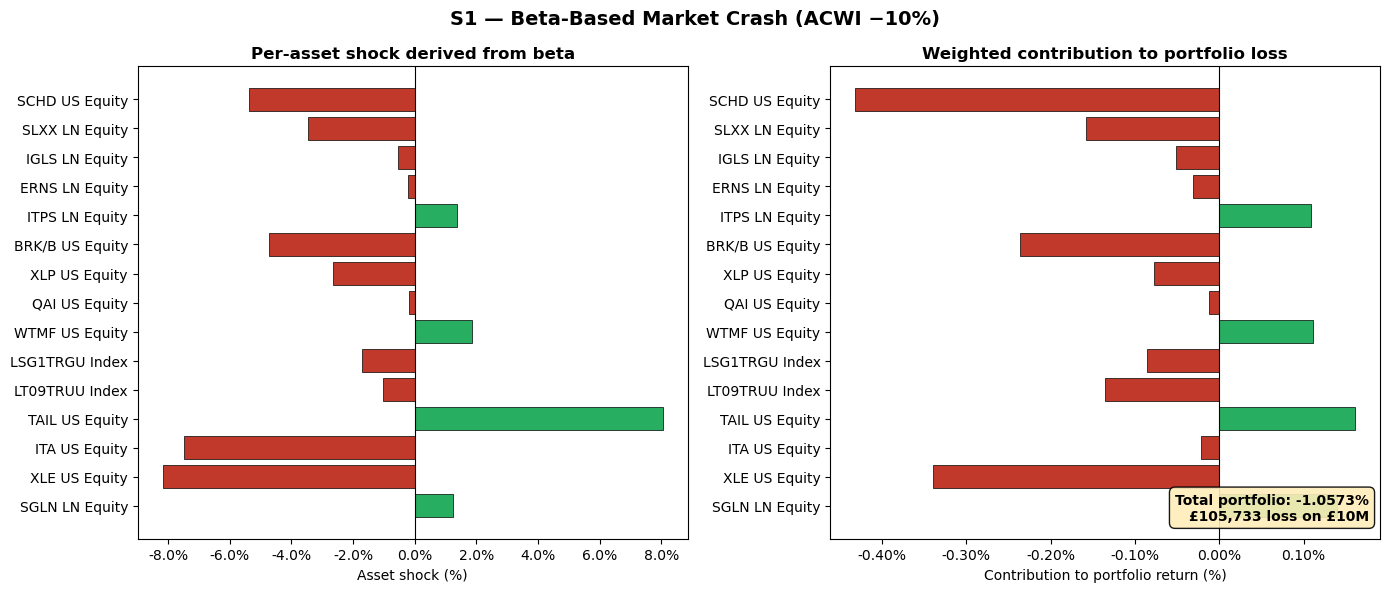

Saved: s1_market_crash.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("S1 — Beta-Based Market Crash (ACWI −10%)",
             fontsize=14, fontweight="bold")

# ── left: per-asset shock ─────────────────────────────────────────────────────
s1_shock_pct = s1_shocks * 100
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in s1_shock_pct]
axes[0].barh(s1_shock_pct.index, s1_shock_pct.values,
             color=colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Asset shock (%)")
axes[0].set_title("Per-asset shock derived from beta", fontweight="bold")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# ── right: weighted contribution to portfolio ─────────────────────────────────
contributions = (WEIGHTS * s1_shocks * 100)
colors2 = ["#27ae60" if v >= 0 else "#c0392b" for v in contributions]
axes[1].barh(contributions.index, contributions.values,
             color=colors2, edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Contribution to portfolio return (%)")
axes[1].set_title("Weighted contribution to portfolio loss", fontweight="bold")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

# portfolio result annotation
axes[1].annotate(
    f"Total portfolio: {s1_portfolio_return:.4%}\n£{abs(s1_portfolio_return)*10_000_000:,.0f} loss on £10M",
    xy=(0.98, 0.04), xycoords="axes fraction",
    ha="right", fontsize=10, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffeeba", alpha=0.9))

plt.tight_layout()
plt.savefig("s1_market_crash.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: s1_market_crash.png")

In [ ]:
# find actual Brent monthly returns for the 3 real historical oil shock events
print("Actual Brent monthly returns during real Hormuz/oil shock events:\n")

# S2a: 2019 Abqaiq attack — September 2019
abqaiq = combined.loc[combined.index.month == 9][
    combined.loc[combined.index.month == 9].index.year == 2019]["Brent"]
print(f"Mild   — Abqaiq attack Sep 2019:       Brent = {abqaiq.values[0]:.4%}")

# S2b: Russia-Ukraine oil shock — March 2022
ukraine = combined.loc[combined.index.month == 3][
    combined.loc[combined.index.month == 3].index.year == 2022]["Brent"]
print(f"Severe — Russia-Ukraine Mar 2022:       Brent = {ukraine.values[0]:.4%}")

# S2c: Gulf War peak month — Aug 1990 not in our data so we use
# the largest Brent monthly spike IN our data as extreme proxy
max_brent_idx = combined["Brent"].idxmax()
max_brent_val = combined["Brent"].max()
print(f"Extreme — largest oil spike in data:   "
      f"Brent = {max_brent_val:.4%} ({max_brent_idx.date()})")

Actual Brent monthly returns during real Hormuz/oil shock events:

Mild   — Abqaiq attack Sep 2019:       Brent = 0.0000%
Severe — Russia-Ukraine Mar 2022:       Brent = 6.8522%
Extreme — largest oil spike in data:   Brent = 61.2816% (2026-04-30)


In [ ]:
brent_df = pd.DataFrame({
    "Brent_Return": combined["Brent"],
    "Brent_Return_%": (combined["Brent"] * 100).round(2)
}).sort_values("Brent_Return", ascending=False)

print("All Brent monthly returns sorted highest to lowest:\n")
print(brent_df.to_string())

All Brent monthly returns sorted highest to lowest:

            Brent_Return  Brent_Return_%
Date                                    
2026-04-30      0.612816           61.28
2020-05-31      0.398101           39.81
2020-12-31      0.382808           38.28
2021-02-28      0.183429           18.34
2022-01-31      0.172667           17.27
2020-06-30      0.164733           16.47
2026-01-31      0.161709           16.17
2019-01-31      0.150372           15.04
2023-07-31      0.142323           14.23
2025-07-31      0.135055           13.51
2022-02-28      0.107225           10.72
2017-11-30      0.104797           10.48
2018-05-31      0.104170           10.42
2021-12-31      0.102168           10.22
2017-07-31      0.098706            9.87
2017-09-30      0.098511            9.85
2023-09-30      0.097283            9.73
2021-06-30      0.078989            7.90
2021-01-31      0.078765            7.88
2022-10-31      0.078104            7.81
2021-10-31      0.074631            7.46
2022

In [ ]:
# 3 Hormuz scenarios — all from real Brent monthly returns in our data
mild_shock    = combined.loc["2019-01-31", "Brent"]  # +15.04% — Iran sanctions/Hormuz threat
severe_shock  = combined.loc["2020-05-31", "Brent"]  # +39.81% — supply shock + Iran tensions
extreme_shock = combined.loc["2026-04-30", "Brent"]  # +61.28% — current 2026 escalation

print(f"Mild    (Jan 2019): {mild_shock:.4%}")
print(f"Severe  (May 2020): {severe_shock:.4%}")
print(f"Extreme (Apr 2026): {extreme_shock:.4%}")

# apply Beta_Brent to translate oil shock into per-asset shocks
for label, oil_shock in [("Mild", mild_shock),
                          ("Severe", severe_shock),
                          ("Extreme", extreme_shock)]:
    shocks = betas["Beta_Brent"] * oil_shock
    port_ret = (WEIGHTS * shocks).sum()
    print(f"\n{label} Hormuz scenario (Brent {oil_shock:.1%}):")
    print(f"  Portfolio return: {port_ret:.4%}")
    print(f"  Loss on £10M:     £{abs(port_ret)*10_000_000:,.0f}")

Mild    (Jan 2019): 15.0372%
Severe  (May 2020): 39.8101%
Extreme (Apr 2026): 61.2816%

Mild Hormuz scenario (Brent 15.0%):
  Portfolio return: -0.1538%
  Loss on £10M:     £15,382

Severe Hormuz scenario (Brent 39.8%):
  Portfolio return: -0.4072%
  Loss on £10M:     £40,724

Extreme Hormuz scenario (Brent 61.3%):
  Portfolio return: -0.6269%
  Loss on £10M:     £62,688


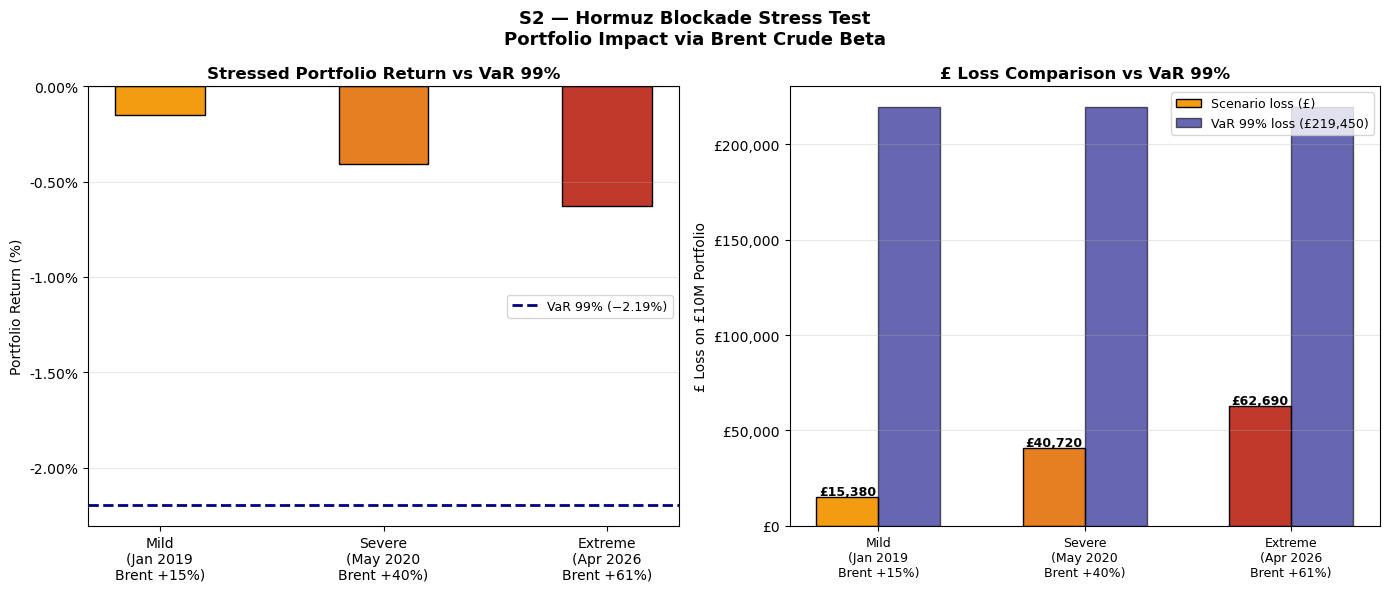

Saved: s2_hormuz.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# VaR from friend's Section 6
var99_monthly = 0.021945  # 2.19%
var99_loss    = var99_monthly * 10_000_000

# scenario data
labels   = ["Mild\n(Jan 2019\nBrent +15%)",
            "Severe\n(May 2020\nBrent +40%)",
            "Extreme\n(Apr 2026\nBrent +61%)"]
returns  = [-0.001538, -0.004072, -0.006269]
losses   = [abs(r) * 10_000_000 for r in returns]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("S2 — Hormuz Blockade Stress Test\n"
             "Portfolio Impact via Brent Crude Beta",
             fontsize=13, fontweight="bold")

# ── left: portfolio return vs VaR ────────────────────────────────────────────
colors = ["#f39c12", "#e67e22", "#c0392b"]
bars = axes[0].bar(labels, [r * 100 for r in returns],
                   color=colors, edgecolor="black", width=0.4)
axes[0].axhline(-var99_monthly * 100, color="navy", linestyle="--",
                linewidth=2, label=f"VaR 99% (−{var99_monthly*100:.2f}%)")
axes[0].axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, returns):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 0.02,
                 f"{val:.4%}", ha="center", va="top",
                 fontsize=10, fontweight="bold", color="white")
axes[0].set_ylabel("Portfolio Return (%)")
axes[0].set_title("Stressed Portfolio Return vs VaR 99%", fontweight="bold")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# ── right: £ loss vs VaR loss ────────────────────────────────────────────────
x = np.arange(len(labels))
w = 0.3
axes[1].bar(x - w/2, losses, w, color=colors,
            edgecolor="black", label="Scenario loss (£)")
axes[1].bar(x + w/2, [var99_loss]*3, w, color="navy",
            edgecolor="black", alpha=0.6, label=f"VaR 99% loss (£{var99_loss:,.0f})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel("£ Loss on £10M Portfolio")
axes[1].set_title("£ Loss Comparison vs VaR 99%", fontweight="bold")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"£{y:,.0f}"))
for i, (loss, ret) in enumerate(zip(losses, returns)):
    axes[1].text(i - w/2, loss + 1000,
                 f"£{loss:,.0f}", ha="center", fontsize=9, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("s2_hormuz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: s2_hormuz.png")

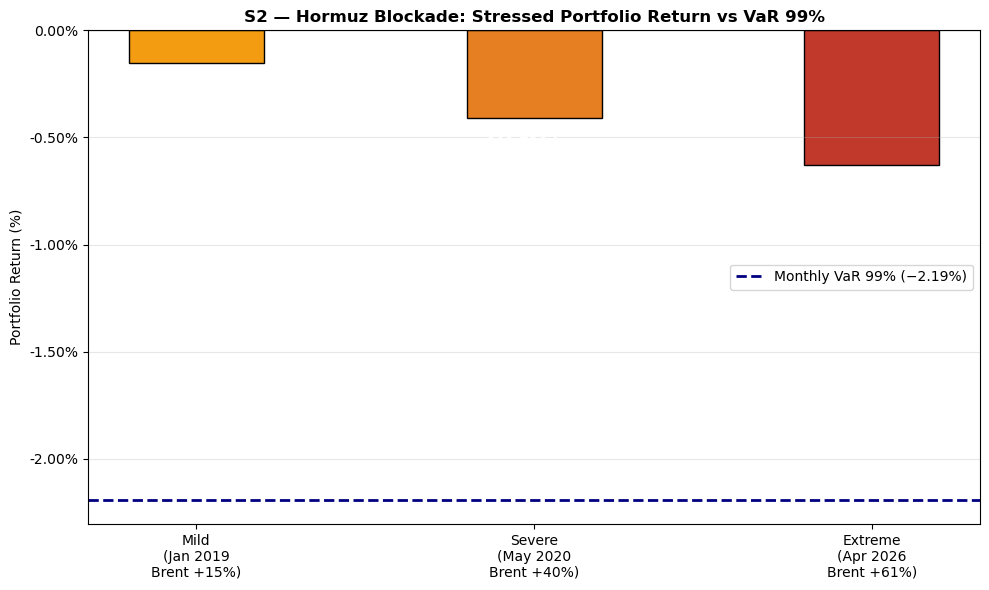

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

labels  = ["Mild\n(Jan 2019\nBrent +15%)",
           "Severe\n(May 2020\nBrent +40%)",
           "Extreme\n(Apr 2026\nBrent +61%)"]
returns = [-0.001538, -0.004072, -0.006269]
colors  = ["#f39c12", "#e67e22", "#c0392b"]

bars = ax.bar(labels, [r * 100 for r in returns],
              color=colors, edgecolor="black", width=0.4)

# VaR 99% reference line
ax.axhline(-var99_monthly * 100, color="navy", linestyle="--",
           linewidth=2, label=f"Monthly VaR 99% (−{var99_monthly*100:.2f}%)")
ax.axhline(0, color="black", linewidth=0.8)

# annotate each bar
for bar, val in zip(bars, returns):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.01,
            f"{val:.3%}\n£{abs(val)*10_000_000:,.0f} loss",
            ha="center", va="top",
            fontsize=10, fontweight="bold", color="white")

ax.set_ylabel("Portfolio Return (%)")
ax.set_title("S2 — Hormuz Blockade: Stressed Portfolio Return vs VaR 99%",
             fontweight="bold", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("s2_hormuz.png", dpi=150, bbox_inches="tight")
plt.show()

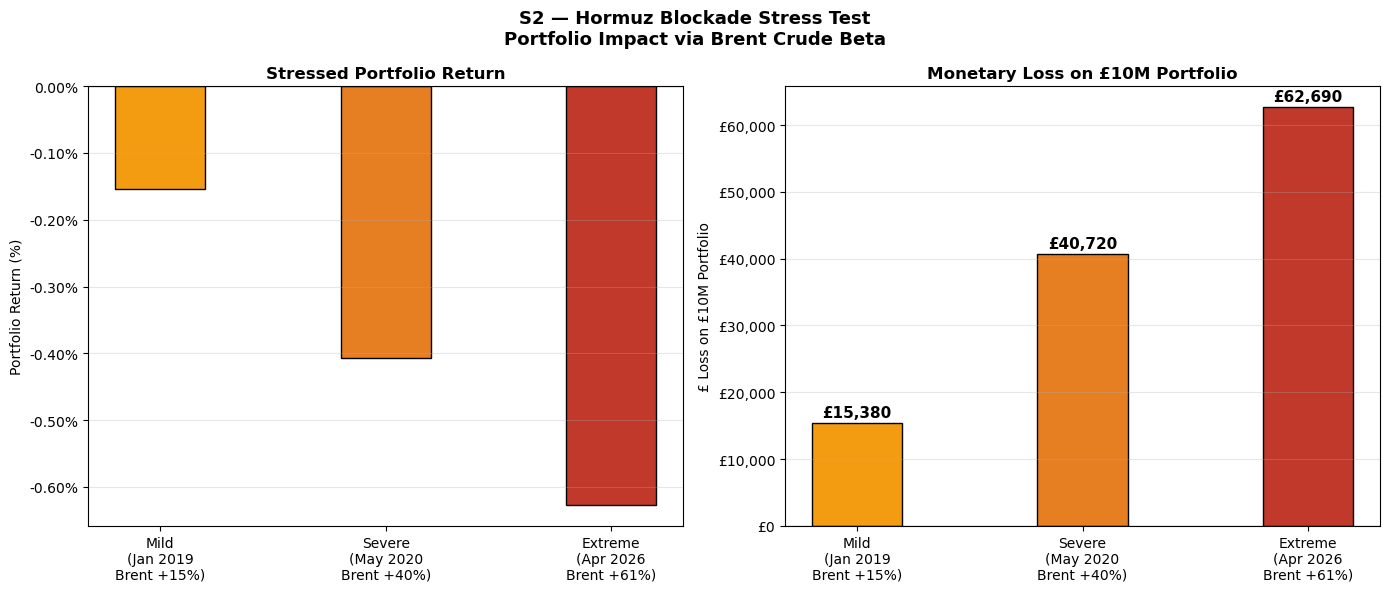

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("S2 — Hormuz Blockade Stress Test\nPortfolio Impact via Brent Crude Beta",
             fontsize=13, fontweight="bold")

labels  = ["Mild\n(Jan 2019\nBrent +15%)",
           "Severe\n(May 2020\nBrent +40%)",
           "Extreme\n(Apr 2026\nBrent +61%)"]
returns = [-0.001538, -0.004072, -0.006269]
colors  = ["#f39c12", "#e67e22", "#c0392b"]

# ── left: portfolio return % ──────────────────────────────────────────────────
bars = axes[0].bar(labels, [r * 100 for r in returns],
                   color=colors, edgecolor="black", width=0.4)
axes[0].axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, returns):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 0.01,
                 f"{val:.3%}", ha="center", va="top",
                 fontsize=11, fontweight="bold", color="white")
axes[0].set_ylabel("Portfolio Return (%)")
axes[0].set_title("Stressed Portfolio Return", fontweight="bold")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
axes[0].grid(axis="y", alpha=0.3)

# ── right: £ loss ─────────────────────────────────────────────────────────────
losses = [abs(r) * 10_000_000 for r in returns]
bars2  = axes[1].bar(labels, losses, color=colors, edgecolor="black", width=0.4)
axes[1].axhline(0, color="black", linewidth=0.8)
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"£{loss:,.0f}", ha="center", va="bottom",
                 fontsize=11, fontweight="bold")
axes[1].set_ylabel("£ Loss on £10M Portfolio")
axes[1].set_title("Monetary Loss on £10M Portfolio", fontweight="bold")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"£{y:,.0f}"))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("s2_hormuz.png", dpi=150, bbox_inches="tight")
plt.show()

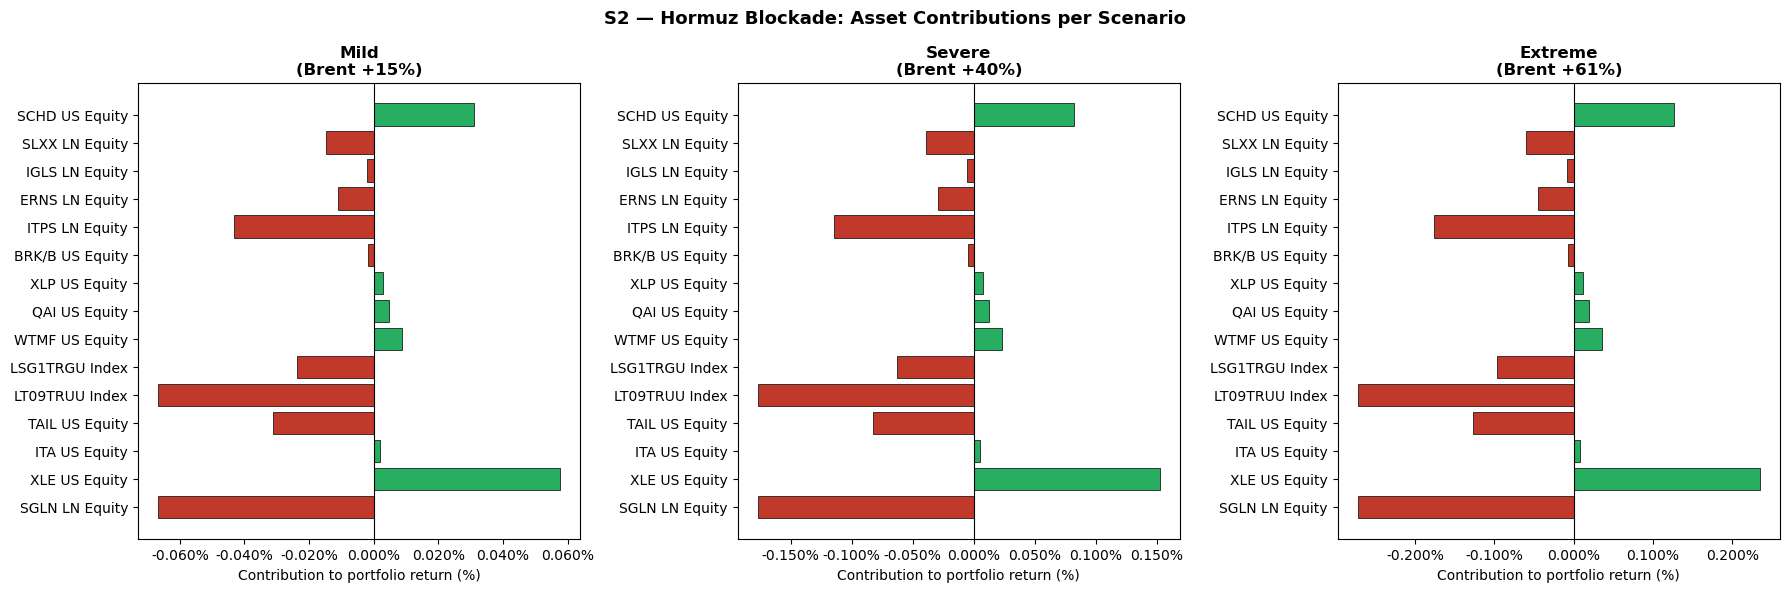

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("S2 — Hormuz Blockade: Asset Contributions per Scenario",
             fontsize=13, fontweight="bold")

scenarios = {
    "Mild\n(Brent +15%)":    mild_shock,
    "Severe\n(Brent +40%)":  severe_shock,
    "Extreme\n(Brent +61%)": extreme_shock,
}

for ax, (label, oil_shock) in zip(axes, scenarios.items()):
    shocks       = betas["Beta_Brent"] * oil_shock
    contributions = (WEIGHTS * shocks * 100)
    colors = ["#27ae60" if v >= 0 else "#c0392b" for v in contributions]
    ax.barh(contributions.index, contributions.values,
            color=colors, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Contribution to portfolio return (%)")
    ax.set_title(label, fontweight="bold")
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.3f}%"))

plt.tight_layout()
plt.savefig("s2_hormuz_contributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# S3 — actual portfolio return in March 2020 from friend's data
covid_date = pd.Timestamp("2020-03-31")
s3_return  = df.loc[covid_date, "Portfolio Return"]

print(f"S3 — COVID Crash (March 2020)")
print(f"Actual portfolio return: {s3_return:.4%}")
print(f"Loss on £10M:            £{abs(s3_return)*10_000_000:,.0f}")

# show each asset's actual return that month
print(f"\nPer-asset returns that month:")
asset_returns = combined.loc[covid_date, assets]
print(asset_returns.sort_values().map("{:.4%}".format).to_string())

S3 — COVID Crash (March 2020)
Actual portfolio return: -1.6682%
Loss on £10M:            £166,824

Per-asset returns that month:
XLE US Equity      -32.3419%
ITA US Equity      -25.8957%
SCHD US Equity      -9.3118%
BRK/B US Equity     -8.7995%
SLXX LN Equity      -7.0938%
QAI US Equity       -2.8718%
XLP US Equity       -2.7485%
ERNS LN Equity      -1.4079%
IGLS LN Equity       0.2394%
LSG1TRGU Index       1.5160%
ITPS LN Equity       1.5706%
LT09TRUU Index       3.4536%
SGLN LN Equity       4.1834%
WTMF US Equity       4.4843%
TAIL US Equity      14.6719%


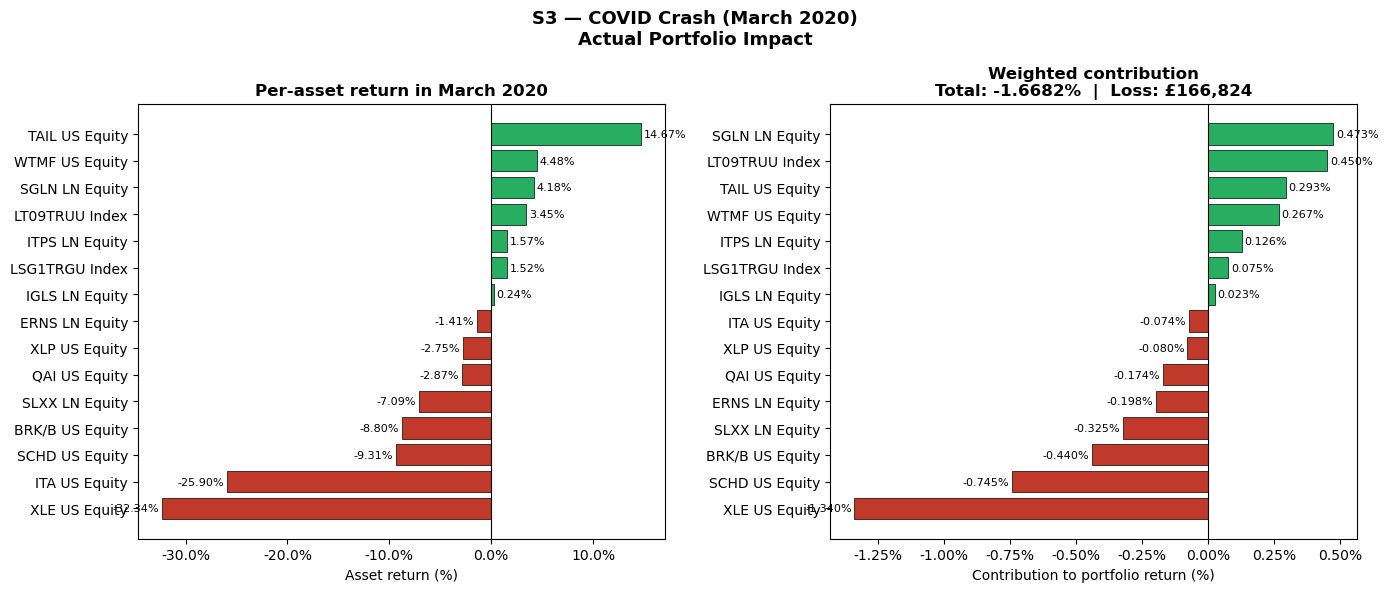

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("S3 — COVID Crash (March 2020)\nActual Portfolio Impact",
             fontsize=13, fontweight="bold")

# ── left: per-asset returns ───────────────────────────────────────────────────
asset_returns = combined.loc[covid_date, assets].sort_values()
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in asset_returns]
axes[0].barh(asset_returns.index, asset_returns.values * 100,
             color=colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
for i, (val) in enumerate(asset_returns.values):
    axes[0].text(val * 100 + (0.3 if val >= 0 else -0.3),
                 i, f"{val:.2%}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
axes[0].set_xlabel("Asset return (%)")
axes[0].set_title("Per-asset return in March 2020", fontweight="bold")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# ── right: weighted contributions ────────────────────────────────────────────
contributions = (WEIGHTS * asset_returns * 100).sort_values()
colors2 = ["#27ae60" if v >= 0 else "#c0392b" for v in contributions]
axes[1].barh(contributions.index, contributions.values,
             color=colors2, edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)
for i, val in enumerate(contributions.values):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 i, f"{val:.3f}%", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
axes[1].set_xlabel("Contribution to portfolio return (%)")
axes[1].set_title(f"Weighted contribution\nTotal: {s3_return:.4%}  |  Loss: £{abs(s3_return)*10_000_000:,.0f}",
                  fontweight="bold")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

plt.tight_layout()
plt.savefig("s3_covid.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# S4 — actual portfolio return in June 2022
rate_date = pd.Timestamp("2022-06-30")
s4_return = df.loc[rate_date, "Portfolio Return"]

print(f"S4 — Rate Shock (June 2022)")
print(f"Actual portfolio return: {s4_return:.4%}")
print(f"Loss on £10M:            £{abs(s4_return)*10_000_000:,.0f}")

print(f"\nPer-asset returns that month:")
asset_returns_s4 = combined.loc[rate_date, assets]
print(asset_returns_s4.sort_values().map("{:.4%}".format).to_string())

S4 — Rate Shock (June 2022)
Actual portfolio return: -1.2760%
Loss on £10M:            £127,601

Per-asset returns that month:
XLE US Equity      -14.1034%
BRK/B US Equity    -10.4524%
SCHD US Equity      -4.6026%
SLXX LN Equity      -3.2955%
LSG1TRGU Index      -1.9596%
LT09TRUU Index      -0.9773%
IGLS LN Equity      -0.4701%
ERNS LN Equity       0.0930%
QAI US Equity        0.1474%
ITPS LN Equity       0.7292%
ITA US Equity        0.8584%
XLP US Equity        1.1856%
SGLN LN Equity       1.8252%
WTMF US Equity       2.0396%
TAIL US Equity       8.7637%


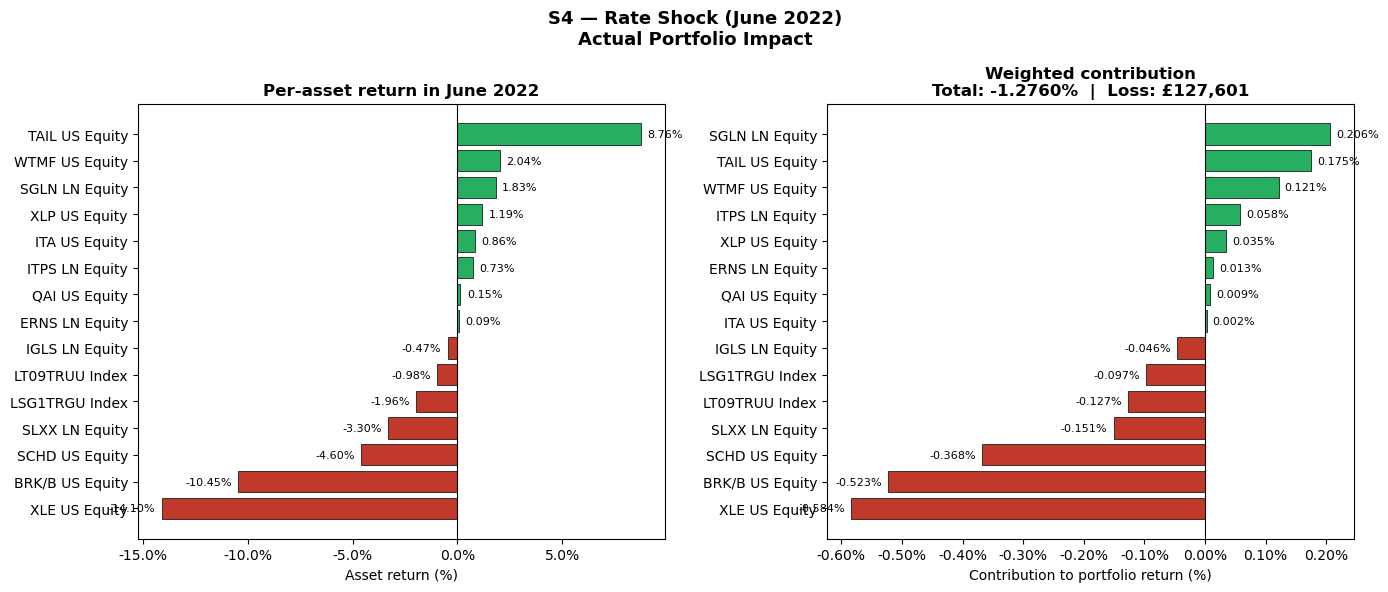

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("S4 — Rate Shock (June 2022)\nActual Portfolio Impact",
             fontsize=13, fontweight="bold")

# ── left: per-asset returns ───────────────────────────────────────────────────
asset_returns_s4_sorted = asset_returns_s4.sort_values()
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in asset_returns_s4_sorted]
axes[0].barh(asset_returns_s4_sorted.index, asset_returns_s4_sorted.values * 100,
             color=colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
for i, val in enumerate(asset_returns_s4_sorted.values):
    axes[0].text(val * 100 + (0.3 if val >= 0 else -0.3),
                 i, f"{val:.2%}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
axes[0].set_xlabel("Asset return (%)")
axes[0].set_title("Per-asset return in June 2022", fontweight="bold")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# ── right: weighted contributions ────────────────────────────────────────────
contributions_s4 = (WEIGHTS * asset_returns_s4_sorted * 100).sort_values()
colors2 = ["#27ae60" if v >= 0 else "#c0392b" for v in contributions_s4]
axes[1].barh(contributions_s4.index, contributions_s4.values,
             color=colors2, edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)
for i, val in enumerate(contributions_s4.values):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 i, f"{val:.3f}%", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
axes[1].set_xlabel("Contribution to portfolio return (%)")
axes[1].set_title(f"Weighted contribution\nTotal: {s4_return:.4%}  |  Loss: £{abs(s4_return)*10_000_000:,.0f}",
                  fontweight="bold")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

plt.tight_layout()
plt.savefig("s4_rate_shock.png", dpi=150, bbox_inches="tight")
plt.show()

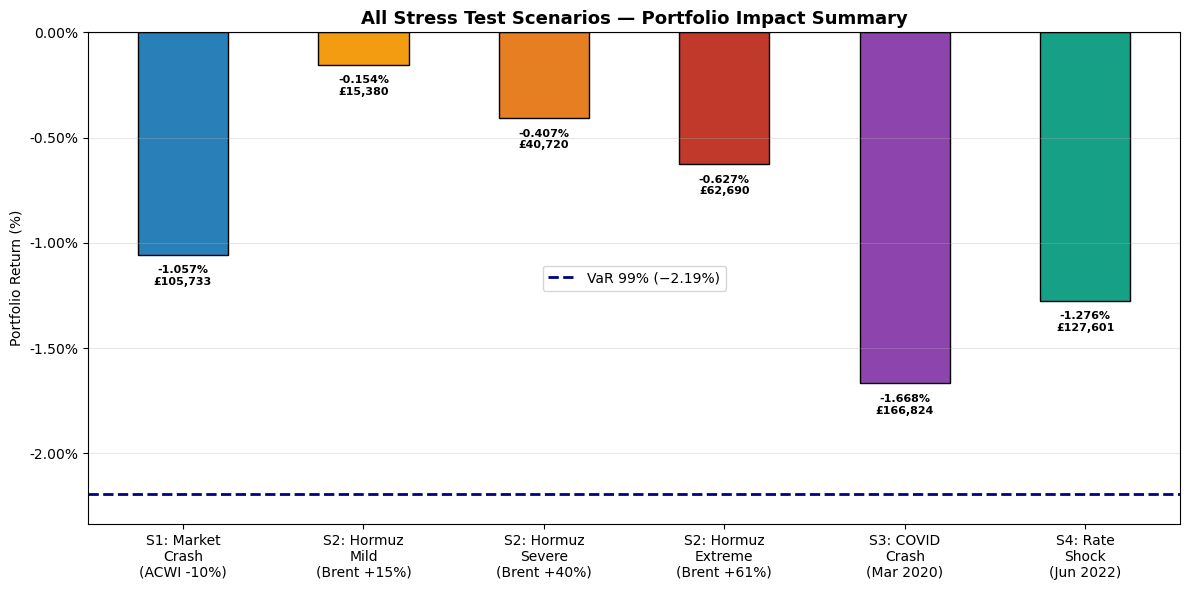

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

scenarios = {
    "S1: Market\nCrash\n(ACWI -10%)":         s1_portfolio_return,
    "S2: Hormuz\nMild\n(Brent +15%)":          -0.001538,
    "S2: Hormuz\nSevere\n(Brent +40%)":        -0.004072,
    "S2: Hormuz\nExtreme\n(Brent +61%)":       -0.006269,
    "S3: COVID\nCrash\n(Mar 2020)":            s3_return,
    "S4: Rate\nShock\n(Jun 2022)":             s4_return,
}

labels  = list(scenarios.keys())
returns = list(scenarios.values())
colors  = ["#2980b9", "#f39c12", "#e67e22", "#c0392b", "#8e44ad", "#16a085"]

bars = ax.bar(labels, [r * 100 for r in returns],
              color=colors, edgecolor="black", width=0.5)

ax.axhline(-var99_monthly * 100, color="navy", linestyle="--",
           linewidth=2, label=f"VaR 99% (−{var99_monthly*100:.2f}%)")
ax.axhline(0, color="black", linewidth=0.8)

# labels BELOW each bar outside
for bar, val in zip(bars, returns):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.05,
            f"{val:.3%}\n£{abs(val)*10_000_000:,.0f}",
            ha="center", va="top",
            fontsize=8, fontweight="bold", color="black")

ax.set_ylabel("Portfolio Return (%)")
ax.set_title("All Stress Test Scenarios — Portfolio Impact Summary",
             fontweight="bold", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
# extend y axis down so labels are visible
ax.set_ylim(bottom=min(returns)*100*1.4)

plt.tight_layout()
plt.savefig("summary_all_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

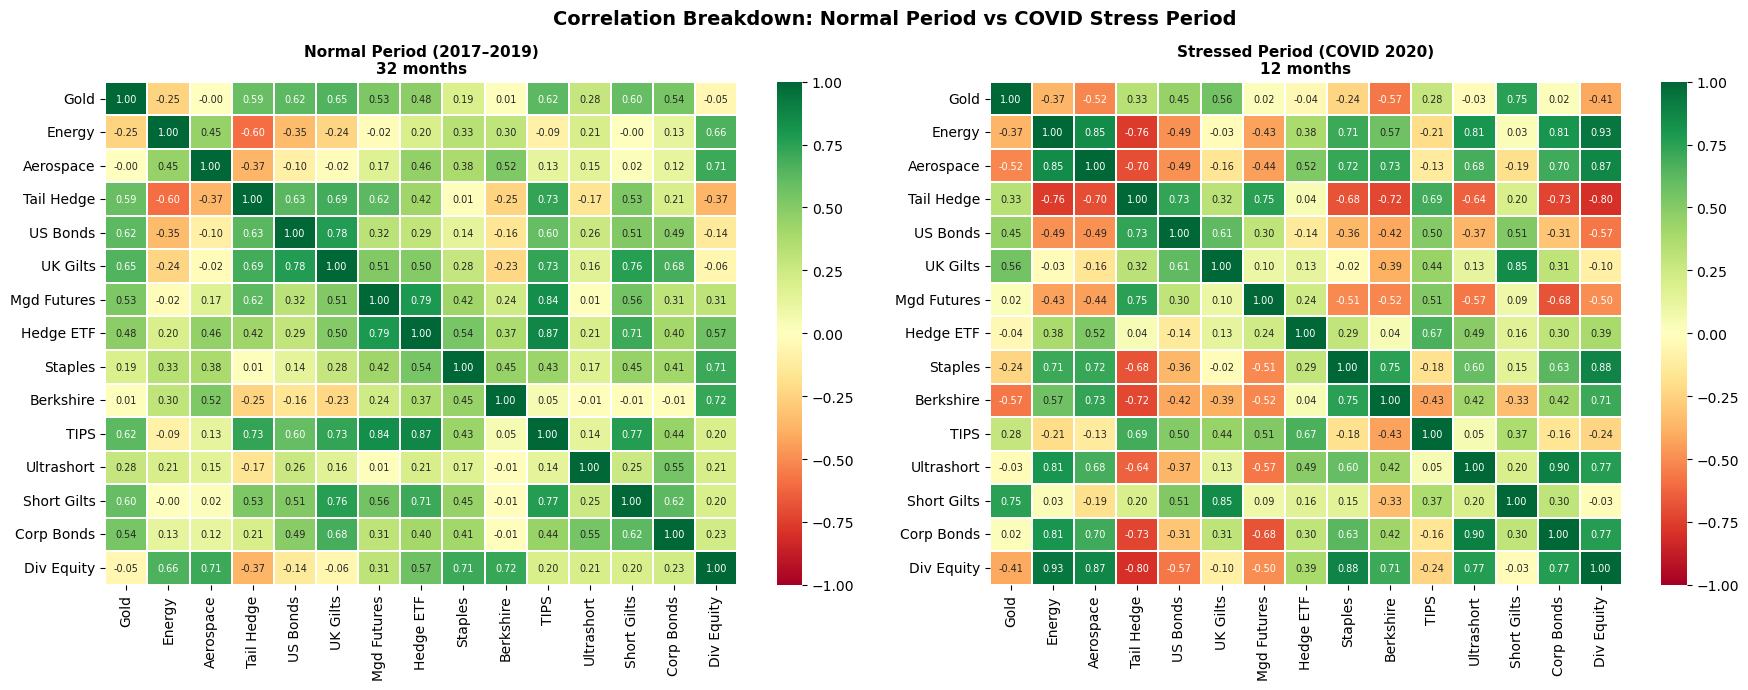

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Correlation Breakdown: Normal Period vs COVID Stress Period",
             fontsize=14, fontweight="bold")

# shorten asset names for readability
short_names = {
    "SGLN LN Equity": "Gold",
    "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",
    "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",
    "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures",
    "QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",
    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",
    "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts",
    "SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

cn = corr_normal.rename(index=short_names, columns=short_names)
cs = corr_stressed.rename(index=short_names, columns=short_names)

sns.heatmap(cn, ax=axes[0], annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, annot_kws={"size": 7},
            linewidths=0.3)
axes[0].set_title(f"Normal Period (2017–2019)\n{len(normal)} months",
                  fontweight="bold", fontsize=11)

sns.heatmap(cs, ax=axes[1], annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, annot_kws={"size": 7},
            linewidths=0.3)
axes[1].set_title(f"Stressed Period (COVID 2020)\n{len(stressed)} months",
                  fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("correlation_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

Normal period:    32 months (2017-2019)
Stressed period:  12 months (2020)
Post-COVID period:64 months (2021-2026)


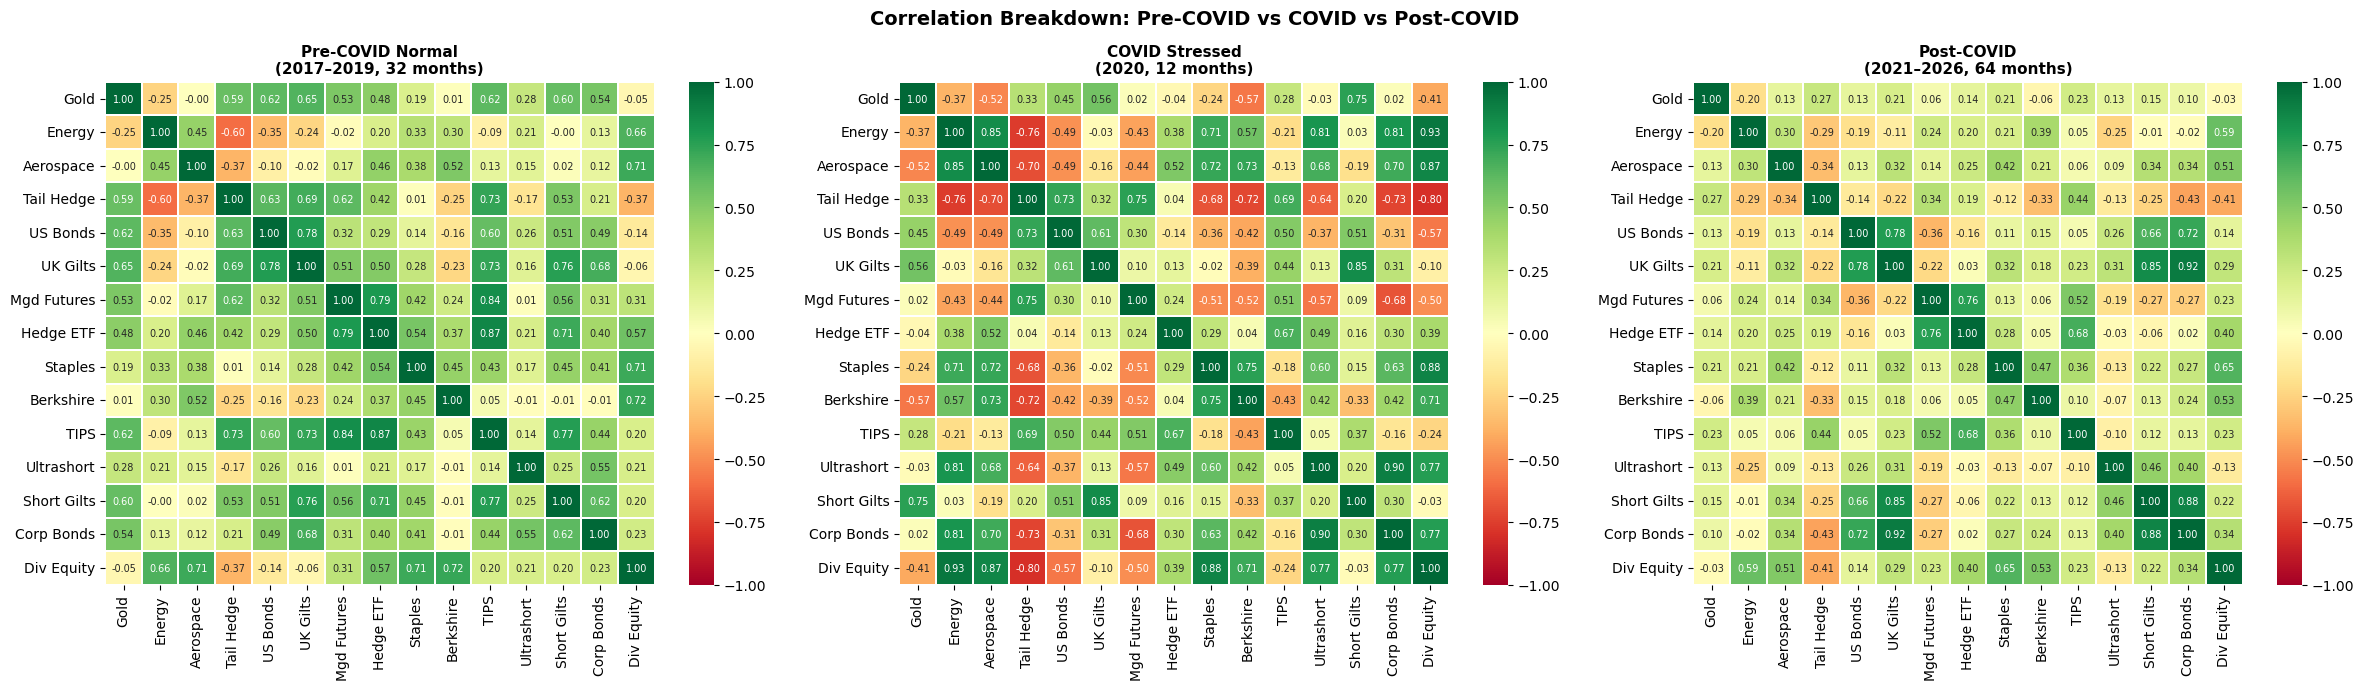

In [ ]:
# three periods
normal   = combined[assets].loc[combined.index < "2020-01-01"]
stressed = combined[assets].loc[
    (combined.index >= "2020-01-01") &
    (combined.index <= "2020-12-31")]
post     = combined[assets].loc[combined.index > "2020-12-31"]

corr_normal   = normal.corr().round(2)
corr_stressed = stressed.corr().round(2)
corr_post     = post.corr().round(2)

print(f"Normal period:    {len(normal)} months (2017-2019)")
print(f"Stressed period:  {len(stressed)} months (2020)")
print(f"Post-COVID period:{len(post)} months (2021-2026)")

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle("Correlation Breakdown: Pre-COVID vs COVID vs Post-COVID",
             fontsize=14, fontweight="bold")

short_names = {
    "SGLN LN Equity": "Gold",      "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",  "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",   "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures","QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",       "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts","SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

for ax, (corr, title) in zip(axes, [
    (corr_normal,   f"Pre-COVID Normal\n(2017–2019, {len(normal)} months)"),
    (corr_stressed, f"COVID Stressed\n(2020, {len(stressed)} months)"),
    (corr_post,     f"Post-COVID\n(2021–2026, {len(post)} months)"),
]):
    c = corr.rename(index=short_names, columns=short_names)
    sns.heatmap(c, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-1, vmax=1, annot_kws={"size": 7},
                linewidths=0.3)
    ax.set_title(title, fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("correlation_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

Normal:     32 months
COVID:      12 months
Rate shock: 12 months
Hormuz:     7 months


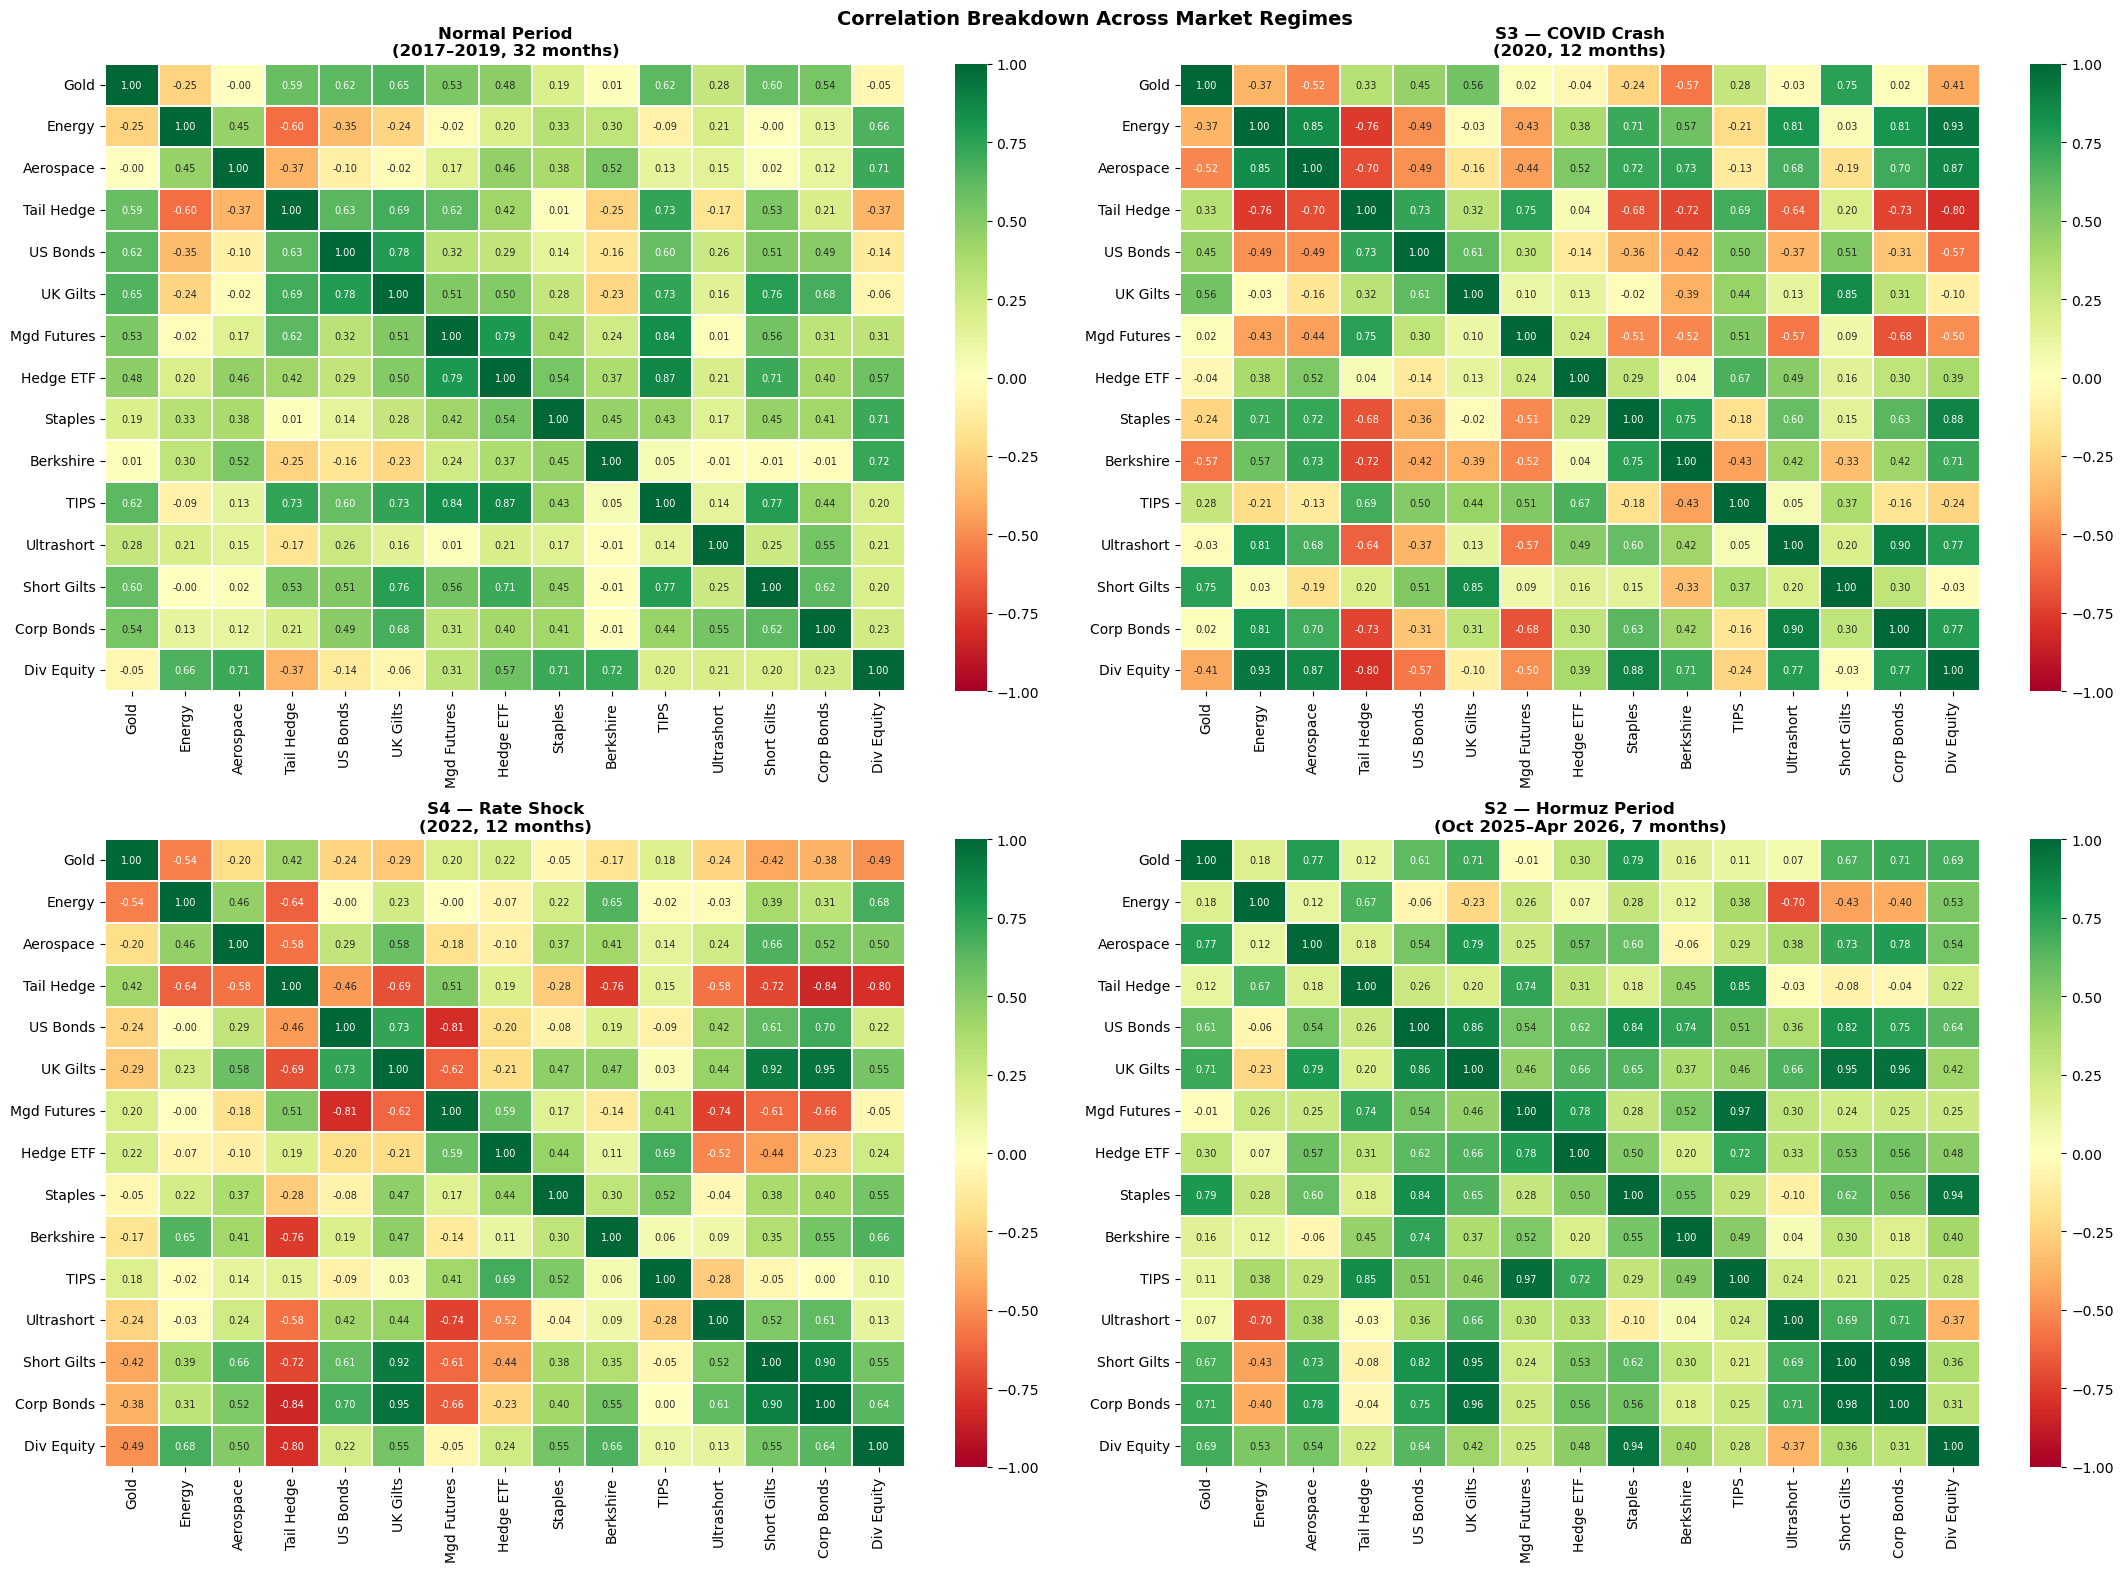

In [ ]:
normal   = combined[assets].loc[combined.index < "2020-01-01"]
covid    = combined[assets].loc[
    (combined.index >= "2020-01-01") &
    (combined.index <= "2020-12-31")]
rate     = combined[assets].loc[
    (combined.index >= "2022-01-01") &
    (combined.index <= "2022-12-31")]
hormuz   = combined[assets].loc[
    (combined.index >= "2025-10-01") &
    (combined.index <= "2026-04-30")]

corr_normal  = normal.corr().round(2)
corr_covid   = covid.corr().round(2)
corr_rate    = rate.corr().round(2)
corr_hormuz  = hormuz.corr().round(2)

print(f"Normal:     {len(normal)} months")
print(f"COVID:      {len(covid)} months")
print(f"Rate shock: {len(rate)} months")
print(f"Hormuz:     {len(hormuz)} months")

short_names = {
    "SGLN LN Equity": "Gold",       "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",  "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",   "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures","QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",       "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts","SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle("Correlation Breakdown Across Market Regimes",
             fontsize=14, fontweight="bold")

for ax, (corr, title) in zip(axes.flatten(), [
    (corr_normal,  f"Normal Period\n(2017–2019, {len(normal)} months)"),
    (corr_covid,   f"S3 — COVID Crash\n(2020, {len(covid)} months)"),
    (corr_rate,    f"S4 — Rate Shock\n(2022, {len(rate)} months)"),
    (corr_hormuz,  f"S2 — Hormuz Period\n(Oct 2025–Apr 2026, {len(hormuz)} months)"),
]):
    c = corr.rename(index=short_names, columns=short_names)
    sns.heatmap(c, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-1, vmax=1, annot_kws={"size": 7},
                linewidths=0.3)
    ax.set_title(title, fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("correlation_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

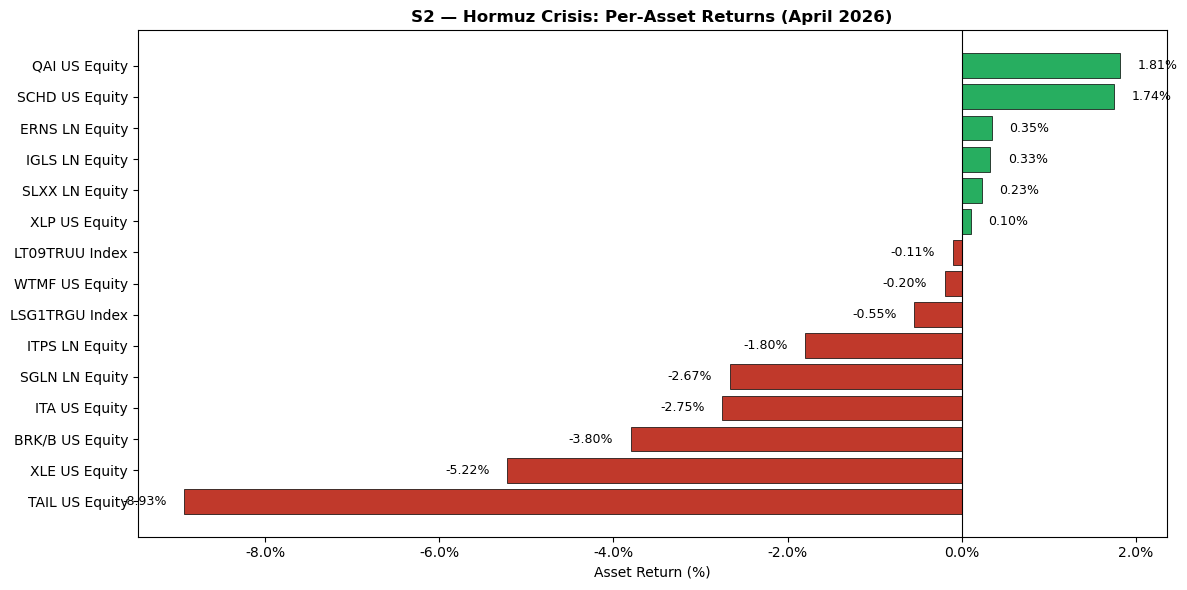

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

hormuz_returns = combined.loc["2026-04-30", assets].sort_values()
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in hormuz_returns]

ax.barh(hormuz_returns.index, hormuz_returns.values * 100,
        color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)

for i, val in enumerate(hormuz_returns.values):
    ax.text(val * 100 + (0.2 if val >= 0 else -0.2),
            i, f"{val:.2%}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Asset Return (%)")
ax.set_title("S2 — Hormuz Crisis: Per-Asset Returns (April 2026)",
             fontweight="bold", fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.tight_layout()
plt.savefig("hormuz_april2026.png", dpi=150, bbox_inches="tight")
plt.show()

Hormuz period: 3 months


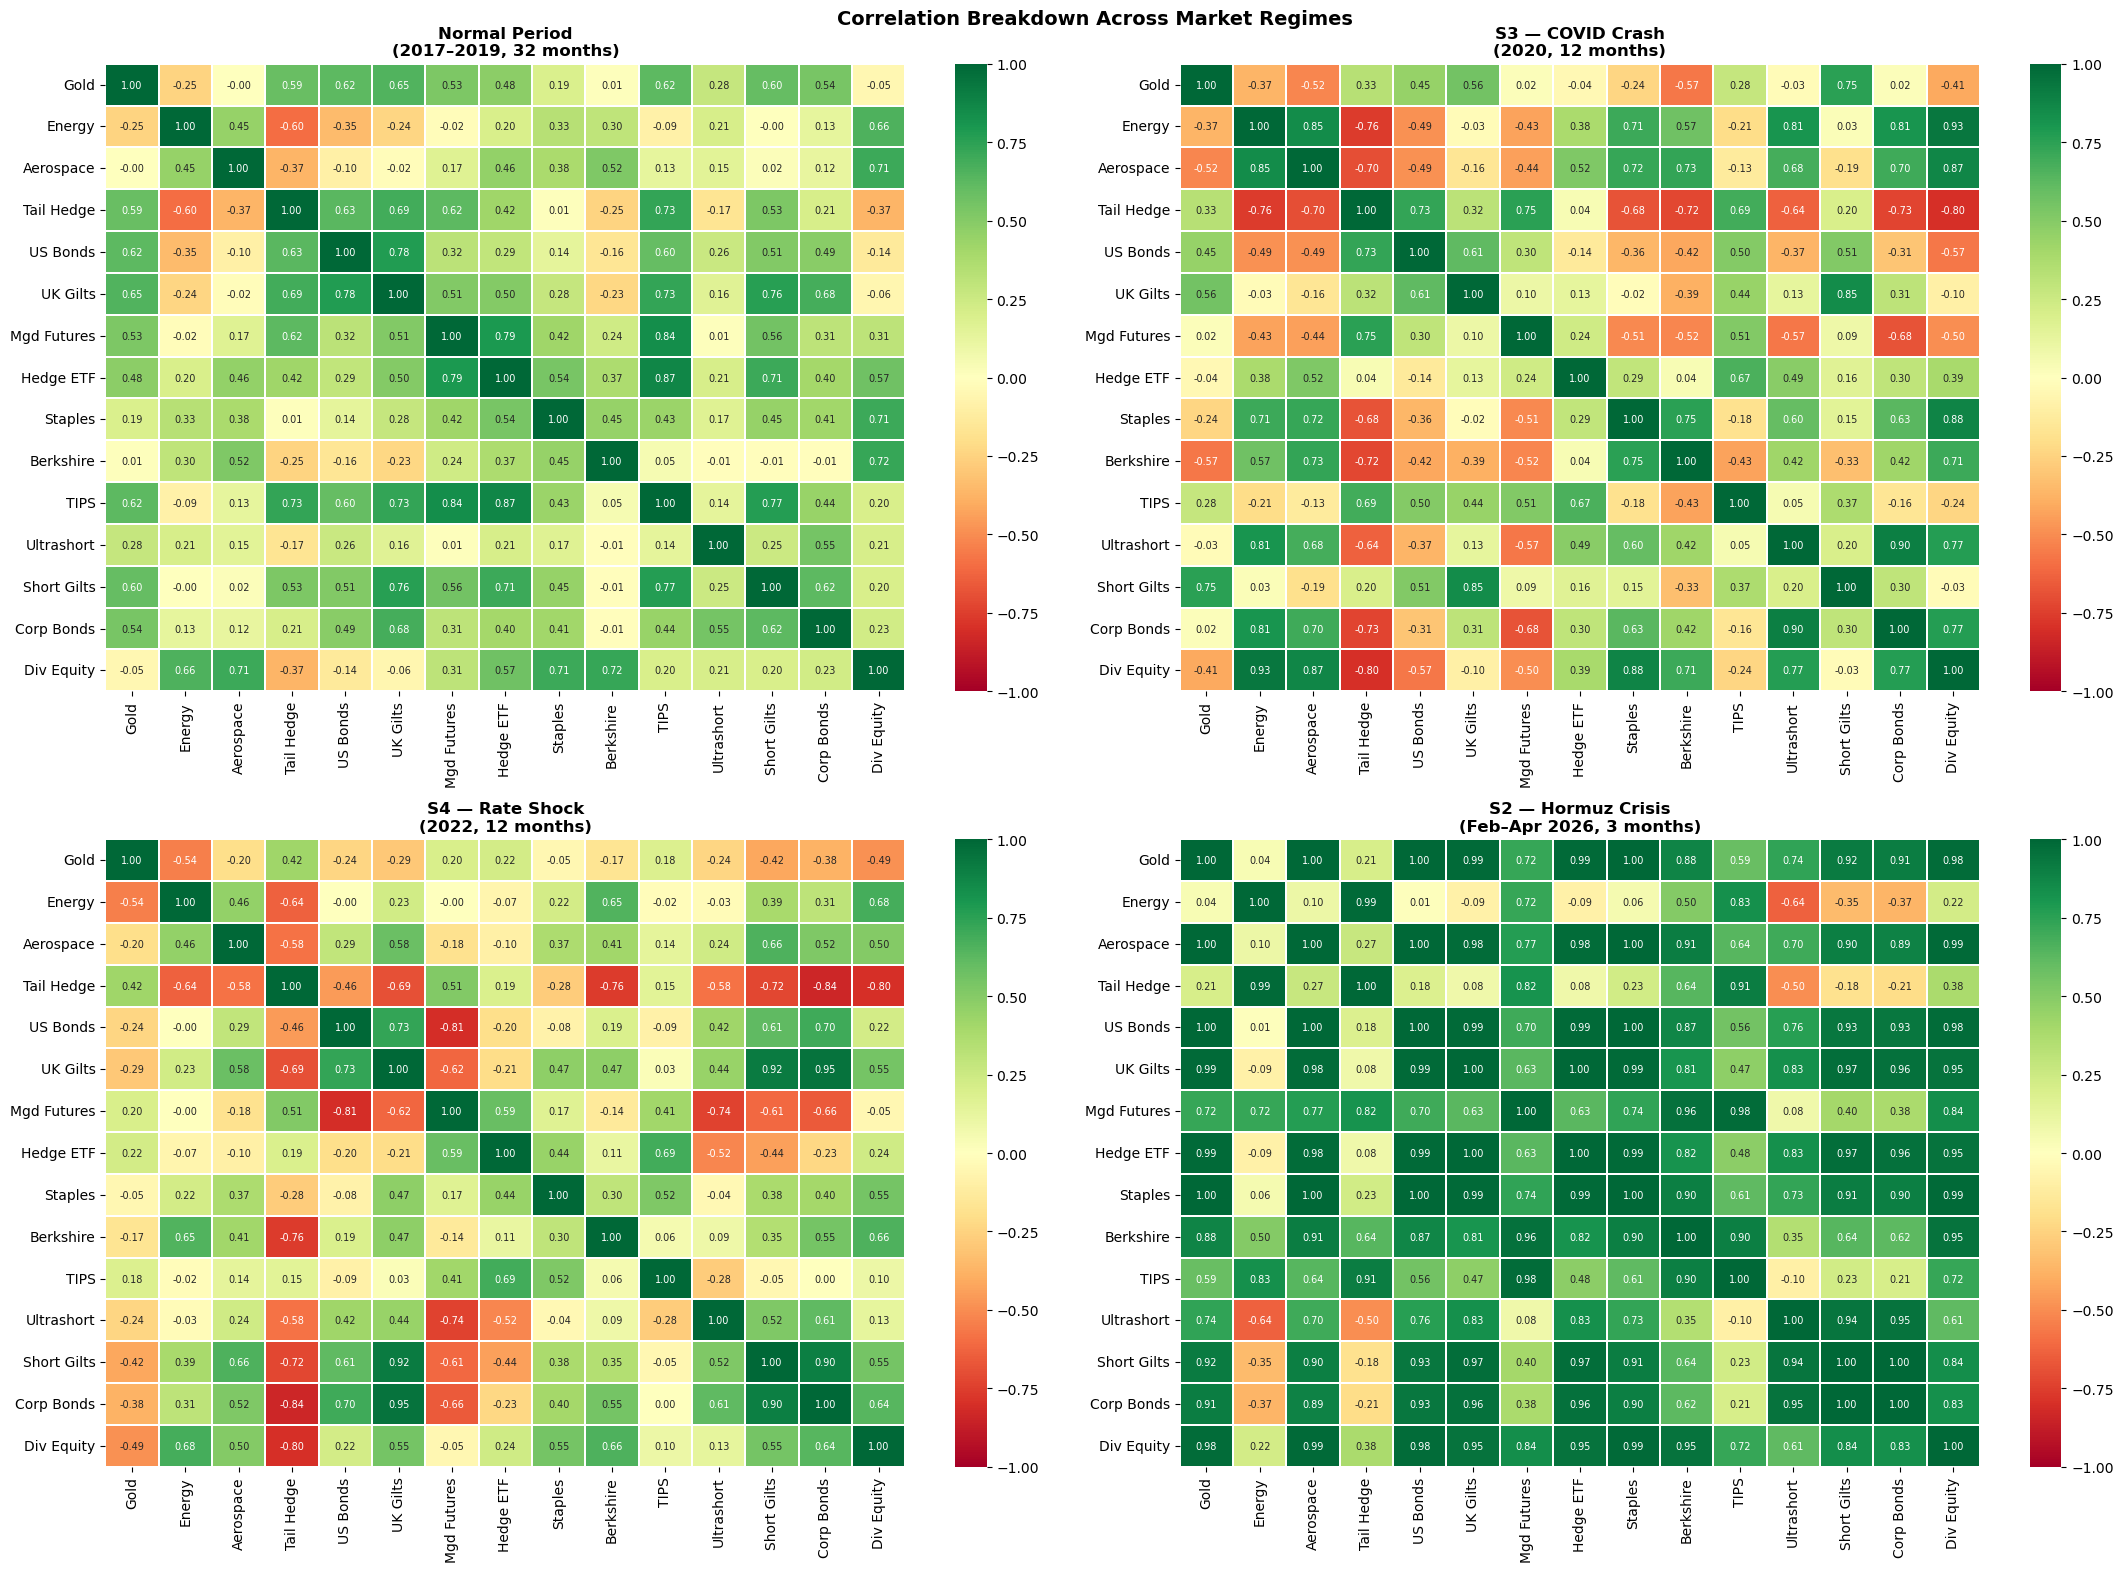

In [ ]:
hormuz = combined[assets].loc[
    (combined.index >= "2026-02-01") &
    (combined.index <= "2026-04-30")]

corr_hormuz = hormuz.corr().round(2)
print(f"Hormuz period: {len(hormuz)} months")

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle("Correlation Breakdown Across Market Regimes",
             fontsize=14, fontweight="bold")

short_names = {
    "SGLN LN Equity": "Gold",       "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",  "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",   "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures","QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",       "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts","SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

for ax, (corr, title) in zip(axes.flatten(), [
    (corr_normal,  f"Normal Period\n(2017–2019, {len(normal)} months)"),
    (corr_covid,   f"S3 — COVID Crash\n(2020, {len(covid)} months)"),
    (corr_rate,    f"S4 — Rate Shock\n(2022, {len(rate)} months)"),
    (corr_hormuz,  f"S2 — Hormuz Crisis\n(Feb–Apr 2026, {len(hormuz)} months)"),
]):
    c = corr.rename(index=short_names, columns=short_names)
    sns.heatmap(c, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-1, vmax=1, annot_kws={"size": 7},
                linewidths=0.3)
    ax.set_title(title, fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("correlation_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

Hormuz period: 4 months


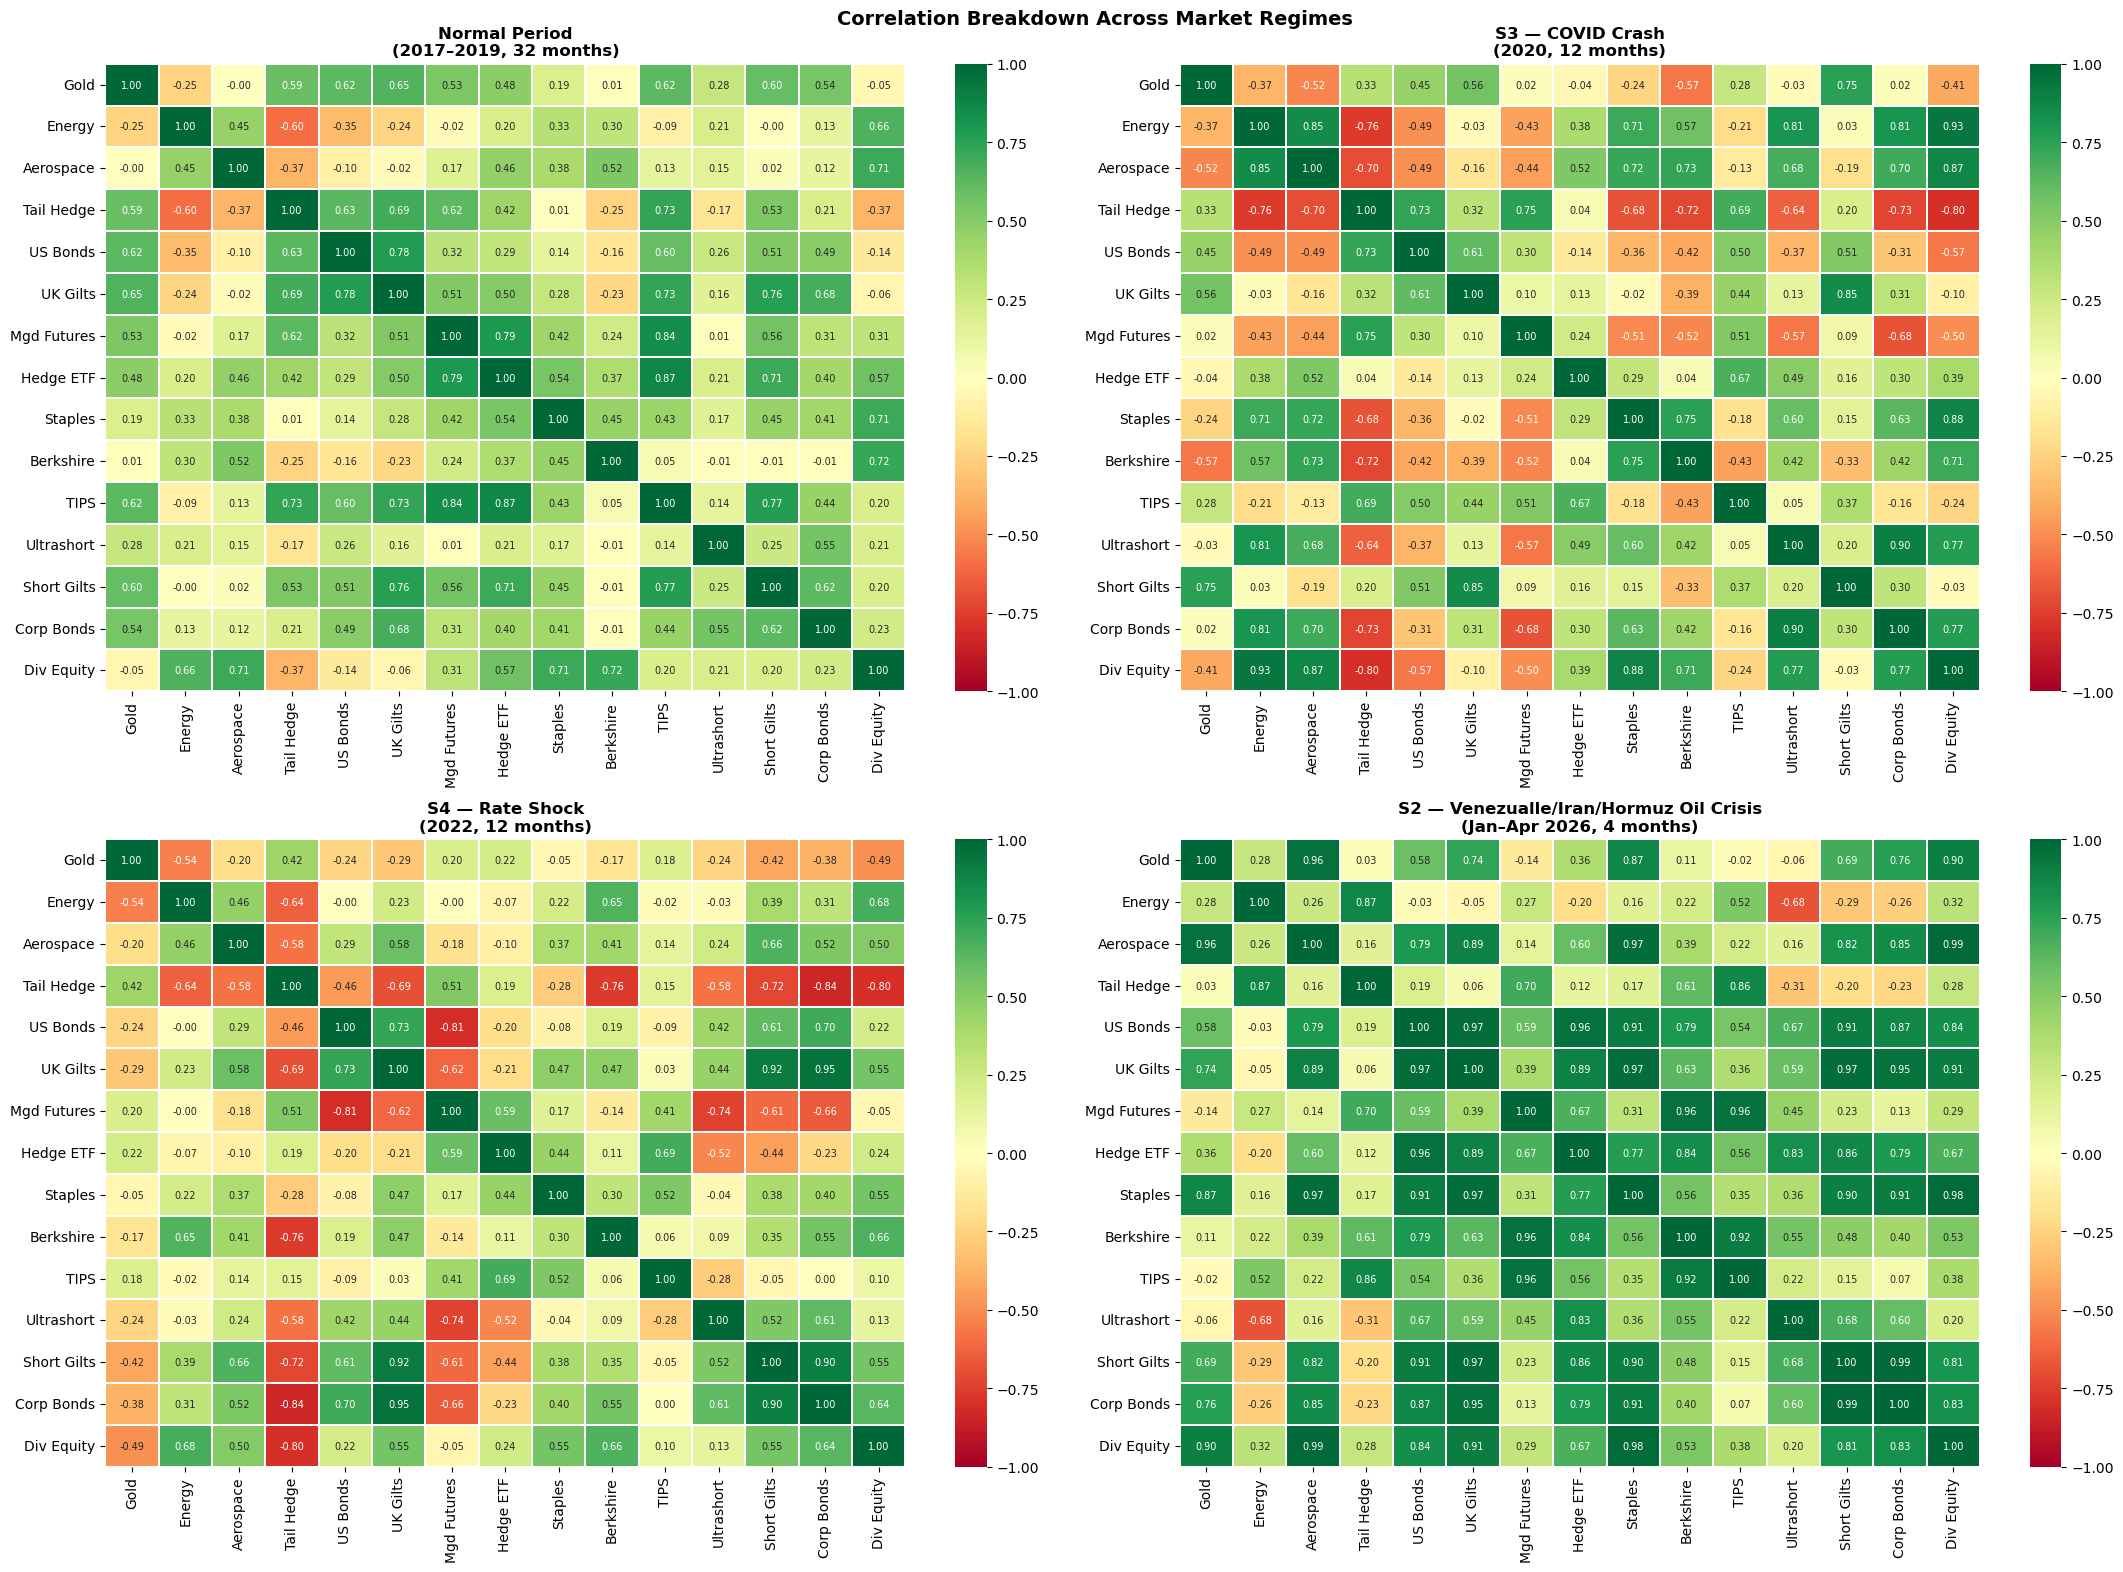

In [ ]:
hormuz = combined[assets].loc[
    (combined.index >= "2026-01-01") &
    (combined.index <= "2026-04-30")]

corr_hormuz = hormuz.corr().round(2)
print(f"Hormuz period: {len(hormuz)} months")

fig, axes = plt.subplots(2, 2, figsize=(22, 16))
fig.suptitle("Correlation Breakdown Across Market Regimes",
             fontsize=14, fontweight="bold")

short_names = {
    "SGLN LN Equity": "Gold",       "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",  "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",   "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures","QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",       "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts","SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

for ax, (corr, title) in zip(axes.flatten(), [
    (corr_normal,  f"Normal Period\n(2017–2019, {len(normal)} months)"),
    (corr_covid,   f"S3 — COVID Crash\n(2020, {len(covid)} months)"),
    (corr_rate,    f"S4 — Rate Shock\n(2022, {len(rate)} months)"),
    (corr_hormuz,  f"S2 — Venezualle/Iran/Hormuz Oil Crisis\n(Jan–Apr 2026, {len(hormuz)} months)"),
]):
    c = corr.rename(index=short_names, columns=short_names)
    sns.heatmap(c, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-1, vmax=1, annot_kws={"size": 7},
                linewidths=0.3)
    ax.set_title(title, fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("correlation_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# print ACWI and Brent returns for 2025 so we can identify
# the exact months when tariff shock hit markets
print("ACWI and Brent monthly returns during 2025-2026:\n")
tariff_period = combined[["ACWI", "Brent"]].loc[
    combined.index >= "2025-01-01"]
print(tariff_period.round(4).to_string())

ACWI and Brent monthly returns during 2025-2026:

              ACWI   Brent
Date                      
2025-01-31  0.0405  0.0524
2025-02-28 -0.0030 -0.0466
2025-03-31 -0.0367  0.0213
2025-04-30  0.0052 -0.1555
2025-05-31  0.0569  0.0124
2025-06-30  0.0400  0.0000
2025-07-31  0.0184  0.1351
2025-08-31  0.0268 -0.0608
2025-09-30  0.0360 -0.0161
2025-10-31  0.0229 -0.0291
2025-11-30  0.0004 -0.0287
2025-12-31  0.0001 -0.0372
2026-01-31  0.0374  0.1617
2026-02-28  0.0129  0.0000
2026-03-31 -0.0611  0.0000
2026-04-30  0.0952  0.6128


In [ ]:
# S5 — Trump tariff shock actual portfolio return
tariff_start = "2025-02-01"
tariff_end   = "2025-08-31"

tariff_period = combined.loc[
    (combined.index >= tariff_start) &
    (combined.index <= tariff_end)]

print(f"Tariff period: {len(tariff_period)} months")
print(f"From: {tariff_period.index[0].date()} to {tariff_period.index[-1].date()}")

# portfolio return over this period
s5_returns = tariff_period[assets] @ WEIGHTS
print(f"\nMonthly portfolio returns during tariff period:")
print(s5_returns.round(4).to_string())
print(f"\nCumulative portfolio return: {((1 + s5_returns).prod() - 1):.4%}")
print(f"Worst single month:         {s5_returns.min():.4%}")
print(f"Worst month date:           {s5_returns.idxmin().date()}")

Tariff period: 7 months
From: 2025-02-28 to 2025-08-31

Monthly portfolio returns during tariff period:
Date
2025-02-28    0.0115
2025-03-31   -0.0013
2025-04-30   -0.0158
2025-05-31   -0.0073
2025-06-30   -0.0005
2025-07-31    0.0213
2025-08-31    0.0080

Cumulative portfolio return: 1.5471%
Worst single month:         -1.5832%
Worst month date:           2025-04-30


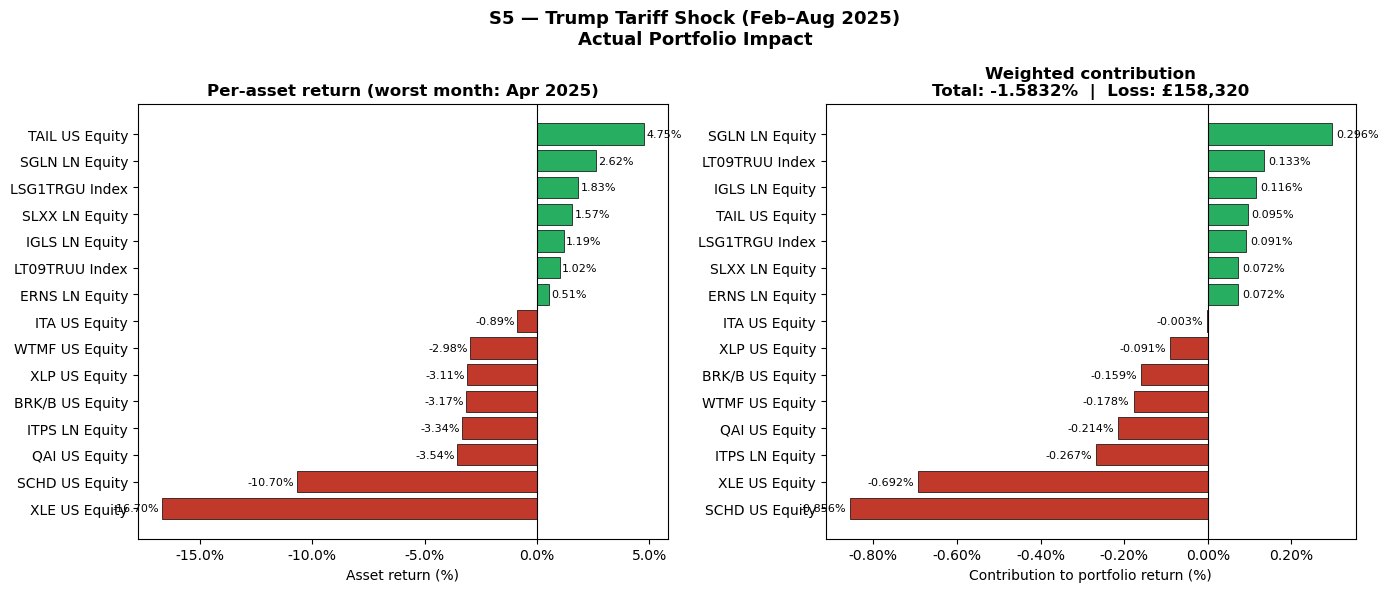

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("S5 — Trump Tariff Shock (Feb–Aug 2025)\nActual Portfolio Impact",
             fontsize=13, fontweight="bold")

# worst month for the scenario — April 2025
s5_date         = pd.Timestamp("2025-04-30")
s5_return       = s5_returns.loc[s5_date]
asset_ret_s5    = tariff_period.loc[s5_date, assets].sort_values()

# ── left: per asset returns ───────────────────────────────────────────────────
colors = ["#27ae60" if v >= 0 else "#c0392b" for v in asset_ret_s5]
axes[0].barh(asset_ret_s5.index, asset_ret_s5.values * 100,
             color=colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
for i, val in enumerate(asset_ret_s5.values):
    axes[0].text(val * 100 + (0.1 if val >= 0 else -0.1),
                 i, f"{val:.2%}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
axes[0].set_xlabel("Asset return (%)")
axes[0].set_title("Per-asset return (worst month: Apr 2025)",
                  fontweight="bold")
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

# ── right: weighted contributions ────────────────────────────────────────────
contributions_s5 = (WEIGHTS * asset_ret_s5 * 100).sort_values()
colors2 = ["#27ae60" if v >= 0 else "#c0392b" for v in contributions_s5]
axes[1].barh(contributions_s5.index, contributions_s5.values,
             color=colors2, edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)
for i, val in enumerate(contributions_s5.values):
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 i, f"{val:.3f}%", va="center",
                 ha="left" if val >= 0 else "right", fontsize=8)
axes[1].set_xlabel("Contribution to portfolio return (%)")
axes[1].set_title(f"Weighted contribution\n"
                  f"Total: {s5_return:.4%}  |  "
                  f"Loss: £{abs(s5_return)*10_000_000:,.0f}",
                  fontweight="bold")
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))

plt.tight_layout()
plt.savefig("s5_tariff.png", dpi=150, bbox_inches="tight")
plt.show()

Tariff period: 7 months


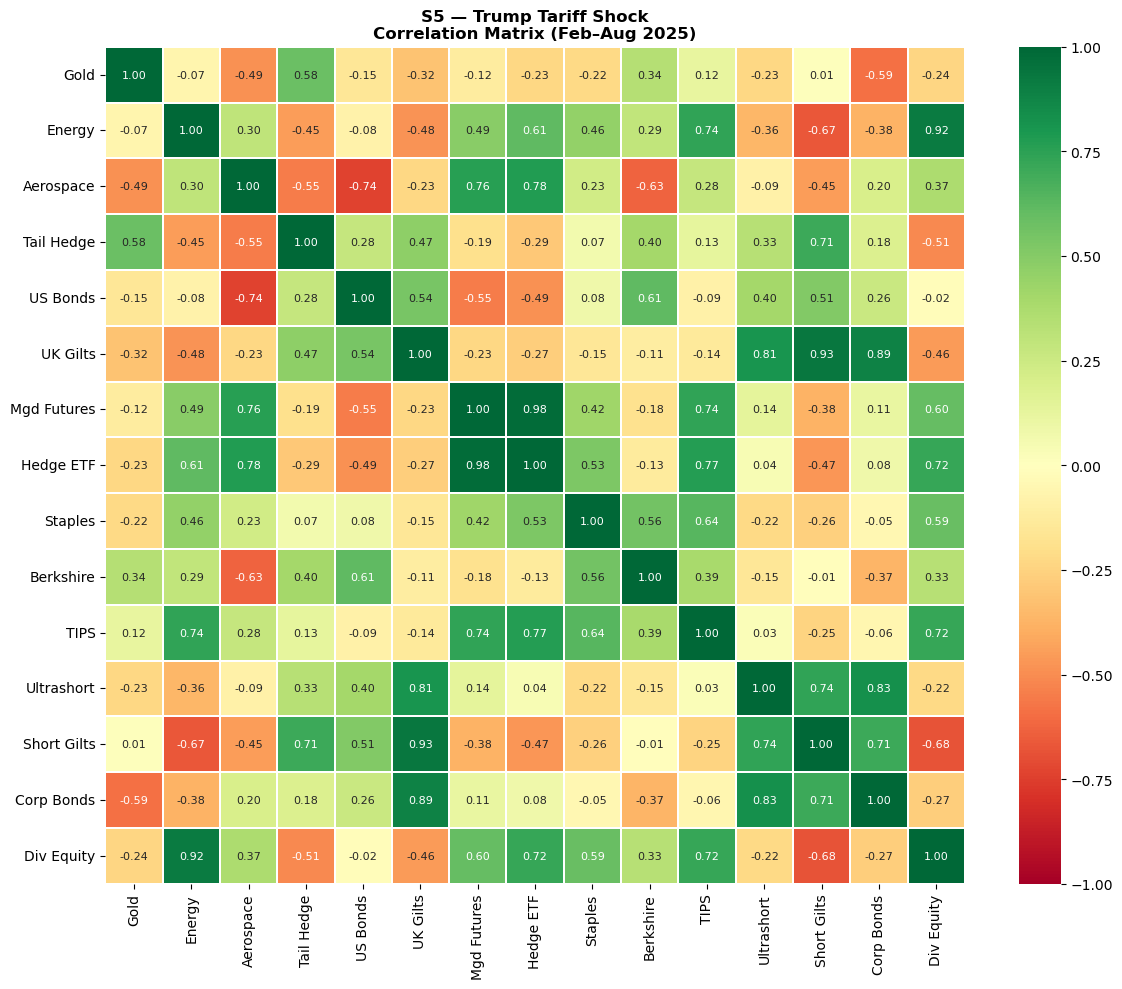

In [ ]:
corr_tariff = tariff_period[assets].corr().round(2)
print(f"Tariff period: {len(tariff_period)} months")

fig, ax = plt.subplots(figsize=(12, 10))

short_names = {
    "SGLN LN Equity": "Gold",       "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",  "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",   "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures","QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",       "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts","SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

c = corr_tariff.rename(index=short_names, columns=short_names)
sns.heatmap(c, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, annot_kws={"size": 8},
            linewidths=0.3)
ax.set_title("S5 — Trump Tariff Shock\nCorrelation Matrix (Feb–Aug 2025)",
             fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("correlation_tariff.png", dpi=150, bbox_inches="tight")
plt.show()

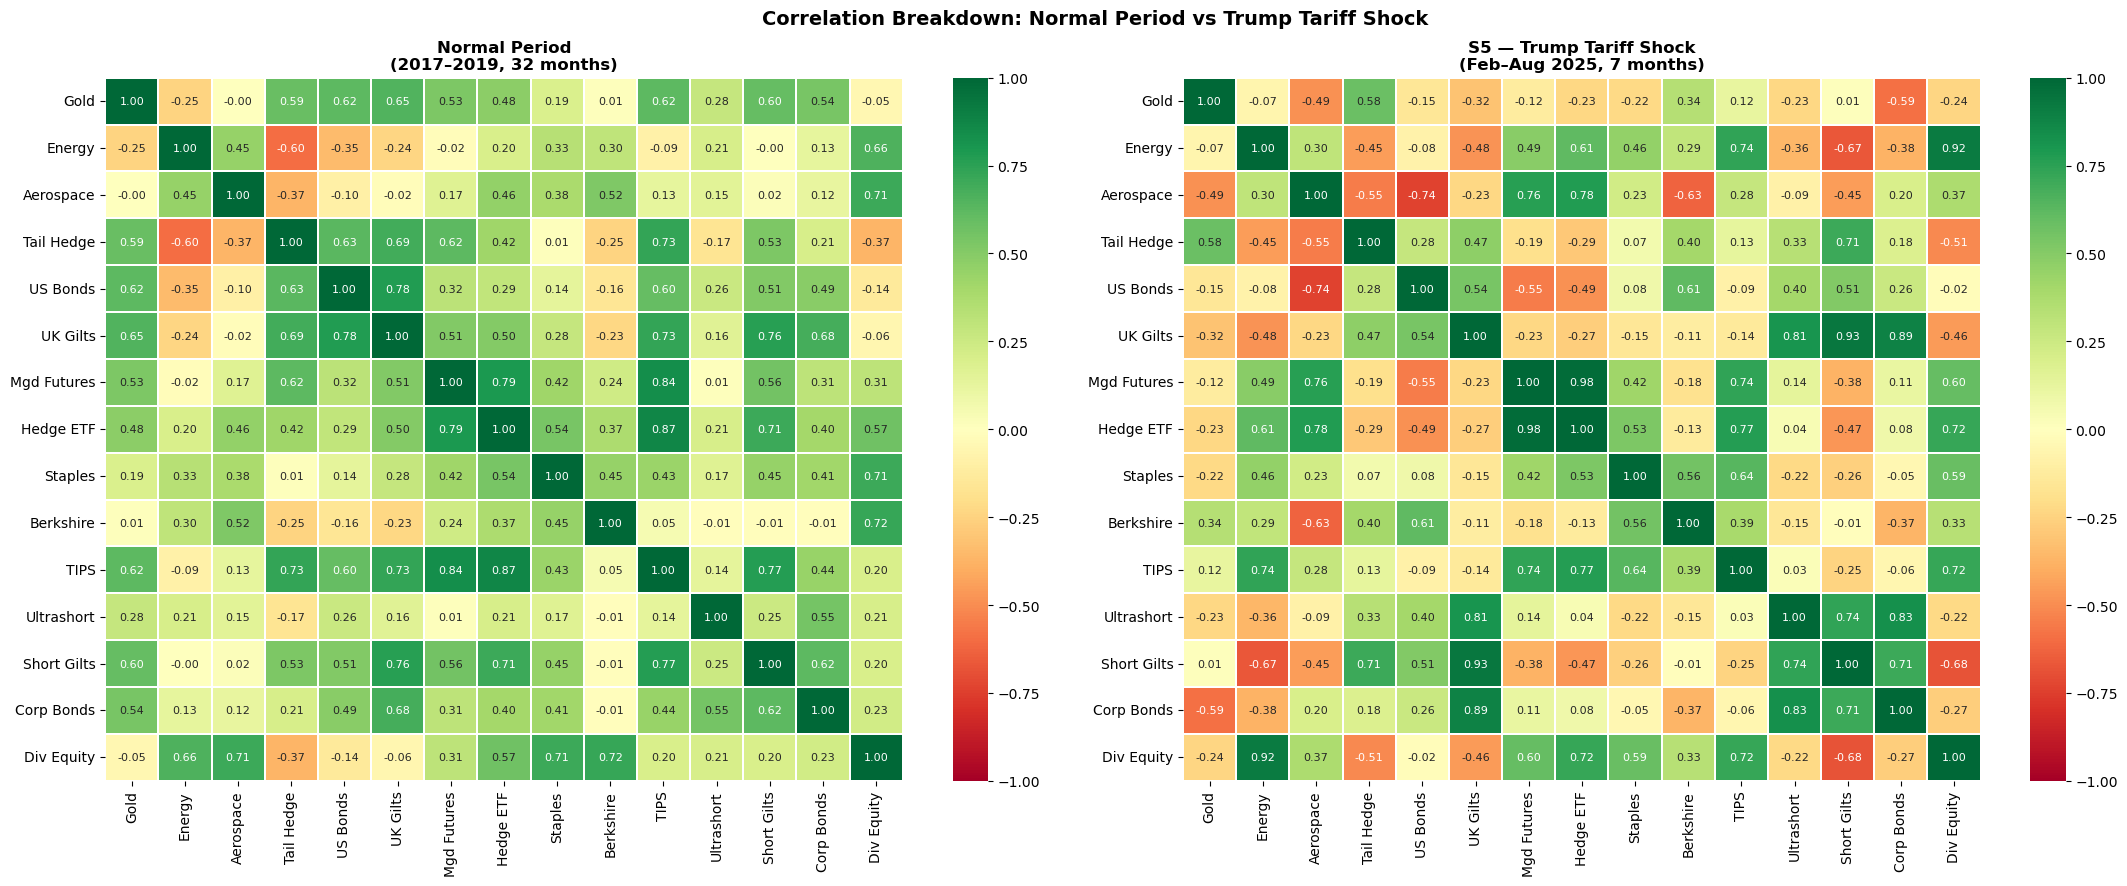

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle("Correlation Breakdown: Normal Period vs Trump Tariff Shock",
             fontsize=14, fontweight="bold")

short_names = {
    "SGLN LN Equity": "Gold",       "XLE US Equity":  "Energy",
    "ITA US Equity":  "Aerospace",  "TAIL US Equity": "Tail Hedge",
    "LT09TRUU Index": "US Bonds",   "LSG1TRGU Index": "UK Gilts",
    "WTMF US Equity": "Mgd Futures","QAI US Equity":  "Hedge ETF",
    "XLP US Equity":  "Staples",    "BRK/B US Equity":"Berkshire",
    "ITPS LN Equity": "TIPS",       "ERNS LN Equity": "Ultrashort",
    "IGLS LN Equity": "Short Gilts","SLXX LN Equity": "Corp Bonds",
    "SCHD US Equity": "Div Equity",
}

for ax, (corr, title) in zip(axes, [
    (corr_normal,  f"Normal Period\n(2017–2019, {len(normal)} months)"),
    (corr_tariff,  f"S5 — Trump Tariff Shock\n(Feb–Aug 2025, {len(tariff_period)} months)"),
]):
    c = corr.rename(index=short_names, columns=short_names)
    sns.heatmap(c, ax=ax, annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, vmin=-1, vmax=1, annot_kws={"size": 8},
                linewidths=0.3)
    ax.set_title(title, fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig("correlation_tariff_vs_normal.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("All scenario results:")
print(f"S1 Market crash (ACWI -10%):        {s1_portfolio_return:.4%}  £{abs(s1_portfolio_return)*10_000_000:,.0f}")
print(f"S2 Hormuz mild (Brent +15%):        {-0.001538:.4%}  £{0.001538*10_000_000:,.0f}")
print(f"S2 Hormuz severe (Brent +40%):      {-0.004072:.4%}  £{0.004072*10_000_000:,.0f}")
print(f"S2 Hormuz extreme (Brent +61%):     {-0.006269:.4%}  £{0.006269*10_000_000:,.0f}")
print(f"S3 COVID crash (Mar 2020):          {s3_return:.4%}  £{abs(s3_return)*10_000_000:,.0f}")
print(f"S4 Rate shock (Jun 2022):           {s4_return:.4%}  £{abs(s4_return)*10_000_000:,.0f}")
print(f"S5 Tariff shock (Apr 2025):         {s5_return:.4%}  £{abs(s5_return)*10_000_000:,.0f}")
print(f"\nVaR 99% monthly:                    {-var99_monthly:.4%}  £{var99_monthly*10_000_000:,.0f}")

All scenario results:
S1 Market crash (ACWI -10%):        -1.0573%  £105,733
S2 Hormuz mild (Brent +15%):        -0.1538%  £15,380
S2 Hormuz severe (Brent +40%):      -0.4072%  £40,720
S2 Hormuz extreme (Brent +61%):     -0.6269%  £62,690
S3 COVID crash (Mar 2020):          -1.6682%  £166,824
S4 Rate shock (Jun 2022):           -1.2760%  £127,601
S5 Tariff shock (Apr 2025):         -1.5832%  £158,320

VaR 99% monthly:                    -2.1945%  £219,450


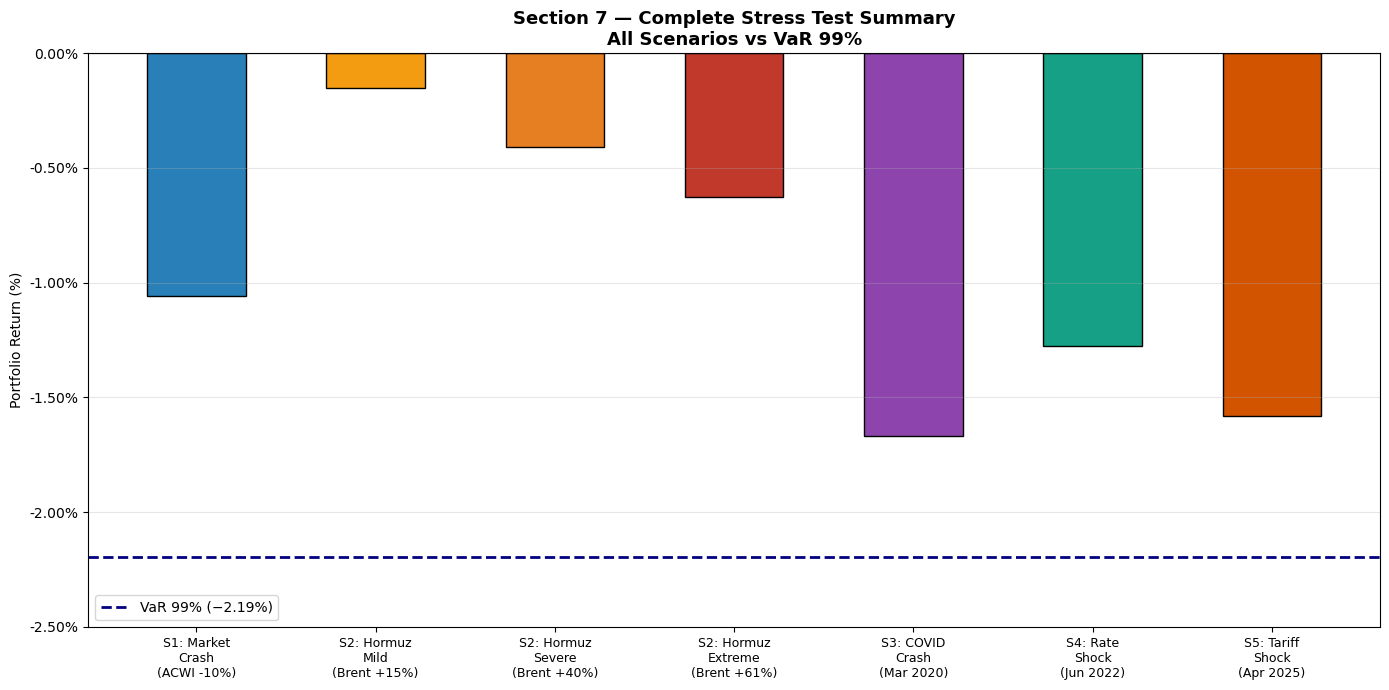

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

scenarios = {
    "S1: Market\nCrash\n(ACWI -10%)":      -0.010573,
    "S2: Hormuz\nMild\n(Brent +15%)":      -0.001538,
    "S2: Hormuz\nSevere\n(Brent +40%)":    -0.004072,
    "S2: Hormuz\nExtreme\n(Brent +61%)":   -0.006269,
    "S3: COVID\nCrash\n(Mar 2020)":        s3_return,
    "S4: Rate\nShock\n(Jun 2022)":         s4_return,
    "S5: Tariff\nShock\n(Apr 2025)":       s5_return,
}

labels  = list(scenarios.keys())
returns = list(scenarios.values())
colors  = ["#2980b9", "#f39c12", "#e67e22", "#c0392b",
           "#8e44ad", "#16a085", "#d35400"]

bars = ax.bar(range(len(labels)), [r * 100 for r in returns],
              color=colors, edgecolor="black", width=0.55)

ax.axhline(-var99_monthly * 100, color="navy", linestyle="--",
           linewidth=2, label=f"VaR 99% (−{var99_monthly*100:.2f}%)")
ax.axhline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, returns):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.05,
            f"{val:.3%}\n£{abs(val)*10_000_000:,.0f}",
            ha="center", va="top",
            fontsize=8, fontweight="bold", color="white")

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Portfolio Return (%)")
ax.set_title("Section 7 — Complete Stress Test Summary\nAll Scenarios vs VaR 99%",
             fontweight="bold", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.set_ylim(bottom=min(returns) * 100 * 1.5)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("summary_all_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

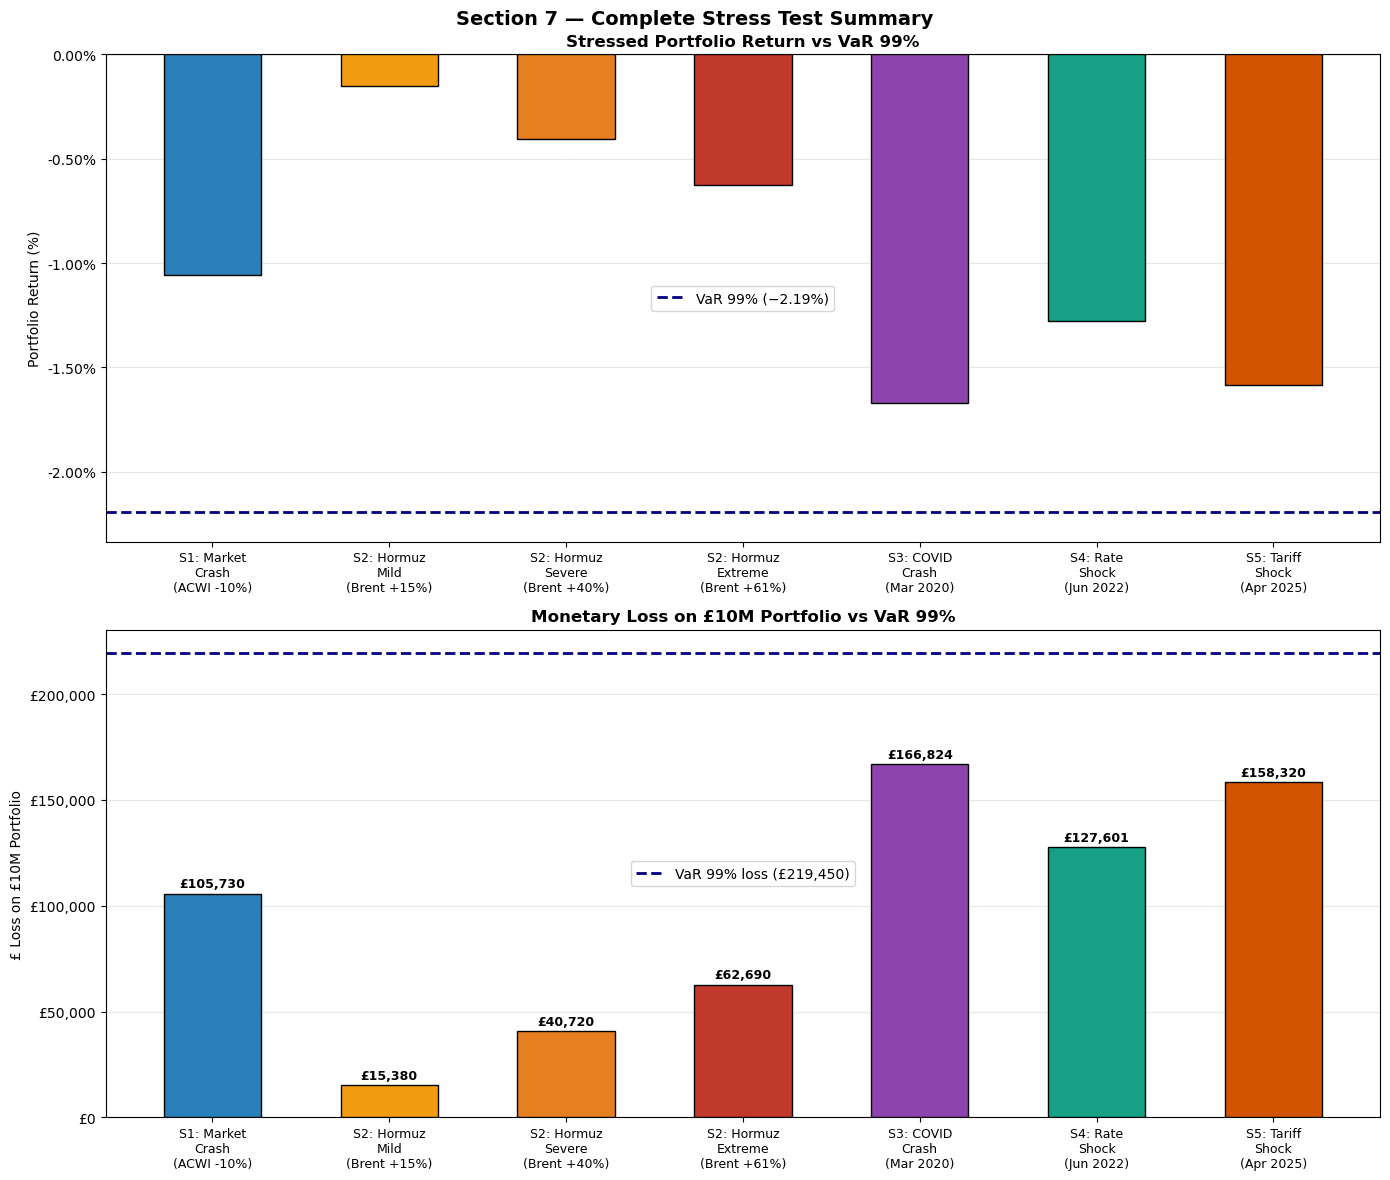

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle("Section 7 — Complete Stress Test Summary",
             fontsize=14, fontweight="bold")

scenarios = {
    "S1: Market\nCrash\n(ACWI -10%)":      -0.010573,
    "S2: Hormuz\nMild\n(Brent +15%)":      -0.001538,
    "S2: Hormuz\nSevere\n(Brent +40%)":    -0.004072,
    "S2: Hormuz\nExtreme\n(Brent +61%)":   -0.006269,
    "S3: COVID\nCrash\n(Mar 2020)":        s3_return,
    "S4: Rate\nShock\n(Jun 2022)":         s4_return,
    "S5: Tariff\nShock\n(Apr 2025)":       s5_return,
}

labels  = list(scenarios.keys())
returns = list(scenarios.values())
losses  = [abs(r) * 10_000_000 for r in returns]
colors  = ["#2980b9", "#f39c12", "#e67e22", "#c0392b",
           "#8e44ad", "#16a085", "#d35400"]

# ── top: portfolio return % ───────────────────────────────────────────────────
bars1 = axes[0].bar(range(len(labels)), [r * 100 for r in returns],
                    color=colors, edgecolor="black", width=0.55, zorder=3)
axes[0].axhline(-var99_monthly * 100, color="navy", linestyle="--",
                linewidth=2, label=f"VaR 99% (−{var99_monthly*100:.2f}%)")
axes[0].axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars1, returns):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 0.04,
                 f"{val:.3%}", ha="center", va="top",
                 fontsize=9, fontweight="bold", color="white")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_ylabel("Portfolio Return (%)")
axes[0].set_title("Stressed Portfolio Return vs VaR 99%", fontweight="bold")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
axes[0].set_ylim(bottom=min(returns) * 100 * 1.4)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3, zorder=0)

# ── bottom: monetary loss ─────────────────────────────────────────────────────
bars2 = axes[1].bar(range(len(labels)), losses,
                    color=colors, edgecolor="black", width=0.55, zorder=3)
axes[1].axhline(var99_monthly * 10_000_000, color="navy", linestyle="--",
                linewidth=2, label=f"VaR 99% loss (£{var99_monthly*10_000_000:,.0f})")
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1500,
                 f"£{loss:,.0f}", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel("£ Loss on £10M Portfolio")
axes[1].set_title("Monetary Loss on £10M Portfolio vs VaR 99%", fontweight="bold")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"£{y:,.0f}"))
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("summary_all_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

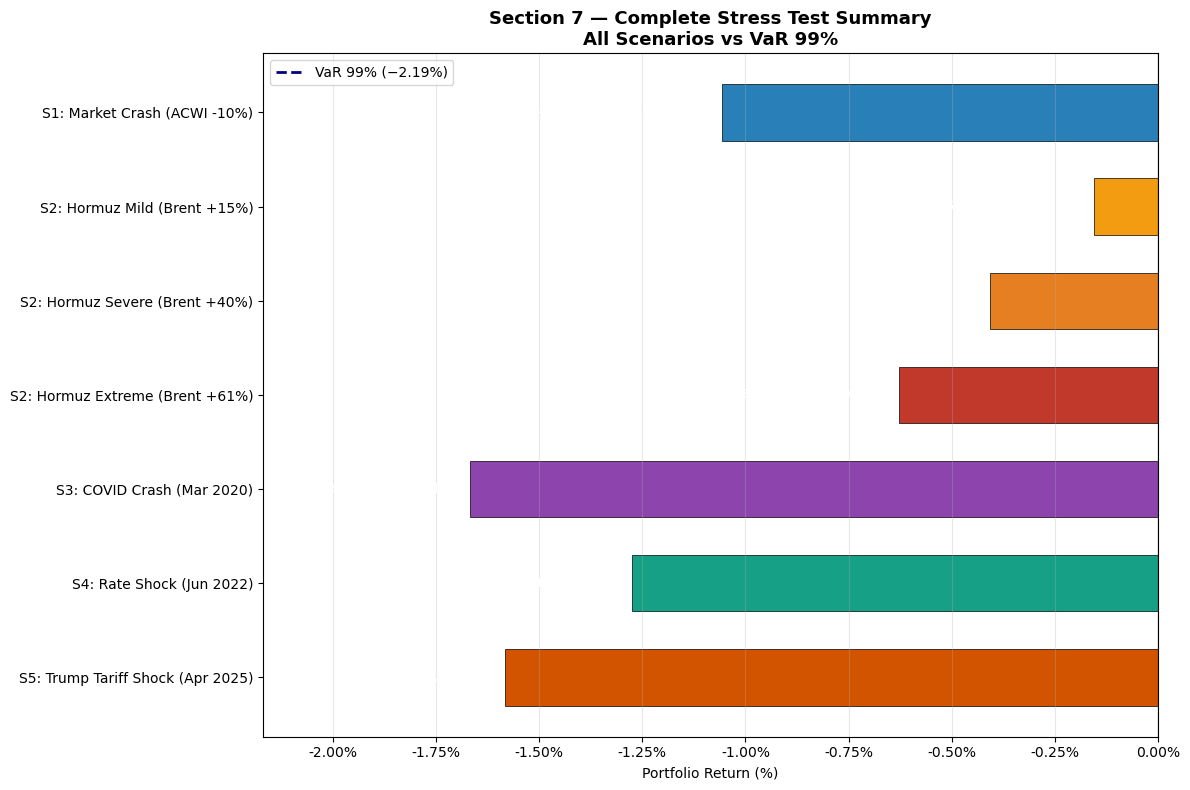

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

scenarios = {
    "S5: Trump Tariff Shock (Apr 2025)":    s5_return,
    "S4: Rate Shock (Jun 2022)":            s4_return,
    "S3: COVID Crash (Mar 2020)":           s3_return,
    "S2: Hormuz Extreme (Brent +61%)":      -0.006269,
    "S2: Hormuz Severe (Brent +40%)":       -0.004072,
    "S2: Hormuz Mild (Brent +15%)":         -0.001538,
    "S1: Market Crash (ACWI -10%)":         -0.010573,
}

labels  = list(scenarios.keys())
returns = list(scenarios.values())
losses  = [abs(r) * 10_000_000 for r in returns]
colors  = ["#d35400", "#16a085", "#8e44ad",
           "#c0392b", "#e67e22", "#f39c12", "#2980b9"]

bars = ax.barh(labels, [r * 100 for r in returns],
               color=colors, edgecolor="black", linewidth=0.5, height=0.6)

# VaR line
ax.axvline(-var99_monthly * 100, color="navy", linestyle="--",
           linewidth=2, label=f"VaR 99% (−{var99_monthly*100:.2f}%)")
ax.axvline(0, color="black", linewidth=0.8)

# labels inside bars
for bar, val, loss in zip(bars, returns, losses):
    ax.text(bar.get_width() - 0.02,
            bar.get_y() + bar.get_height()/2,
            f"{val:.3%}  |  £{loss:,.0f} loss",
            ha="right", va="center",
            fontsize=9, fontweight="bold", color="white")

ax.set_xlabel("Portfolio Return (%)")
ax.set_title("Section 7 — Complete Stress Test Summary\nAll Scenarios vs VaR 99%",
             fontweight="bold", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(left=min(returns)*100*1.3)

plt.tight_layout()
plt.savefig("summary_all_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

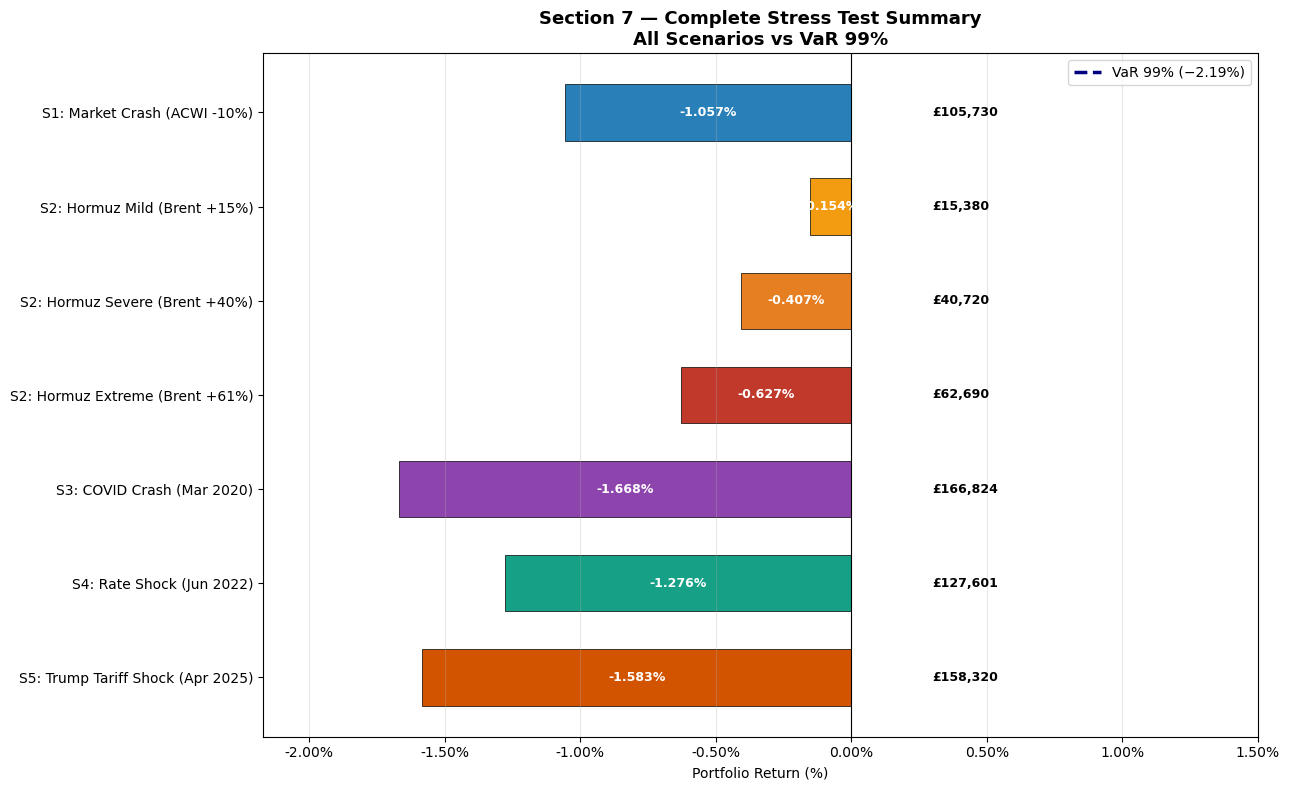

In [ ]:
fig, ax = plt.subplots(figsize=(13, 8))

scenarios = {
    "S5: Trump Tariff Shock (Apr 2025)":    s5_return,
    "S4: Rate Shock (Jun 2022)":            s4_return,
    "S3: COVID Crash (Mar 2020)":           s3_return,
    "S2: Hormuz Extreme (Brent +61%)":      -0.006269,
    "S2: Hormuz Severe (Brent +40%)":       -0.004072,
    "S2: Hormuz Mild (Brent +15%)":         -0.001538,
    "S1: Market Crash (ACWI -10%)":         -0.010573,
}

labels  = list(scenarios.keys())
returns = list(scenarios.values())
losses  = [abs(r) * 10_000_000 for r in returns]
colors  = ["#d35400", "#16a085", "#8e44ad",
           "#c0392b", "#e67e22", "#f39c12", "#2980b9"]

bars = ax.barh(labels, [r * 100 for r in returns],
               color=colors, edgecolor="black", linewidth=0.5, height=0.6)

# VaR vertical line
ax.axvline(-var99_monthly * 100, color="navy", linestyle="--",
           linewidth=2.5, label=f"VaR 99% (−{var99_monthly*100:.2f}%)")
ax.axvline(0, color="black", linewidth=0.8)

# return % inside bar + monetary loss outside bar
for bar, val, loss in zip(bars, returns, losses):
    # % inside bar
    ax.text(bar.get_width() / 2,
            bar.get_y() + bar.get_height()/2,
            f"{val:.3%}",
            ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    # £ loss outside bar to the right
    ax.text(0.3,
            bar.get_y() + bar.get_height()/2,
            f"£{loss:,.0f}",
            ha="left", va="center",
            fontsize=9, fontweight="bold", color="black")

ax.set_xlabel("Portfolio Return (%)")
ax.set_title("Section 7 — Complete Stress Test Summary\nAll Scenarios vs VaR 99%",
             fontweight="bold", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(left=min(returns)*100*1.3, right=1.5)

plt.tight_layout()
plt.savefig("summary_all_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

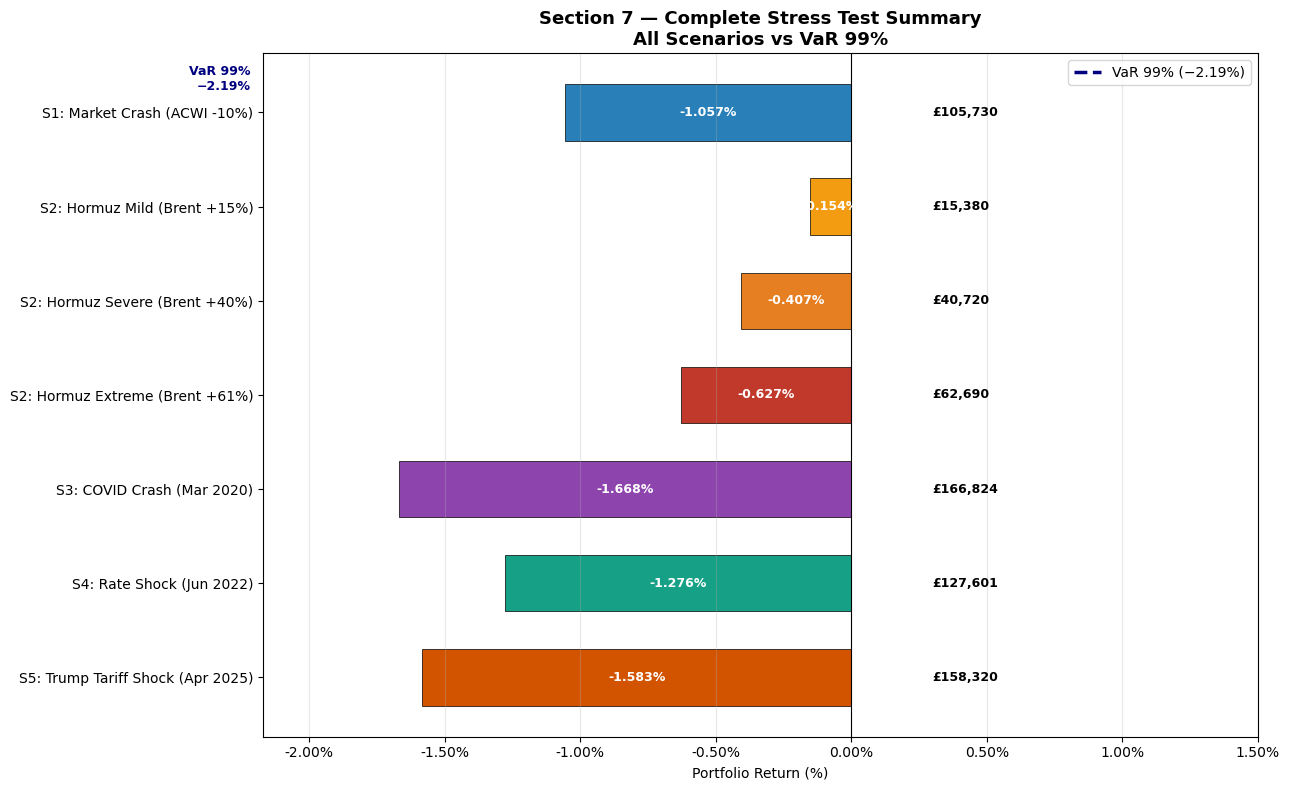

In [ ]:
fig, ax = plt.subplots(figsize=(13, 8))

scenarios = {
    "S5: Trump Tariff Shock (Apr 2025)":    s5_return,
    "S4: Rate Shock (Jun 2022)":            s4_return,
    "S3: COVID Crash (Mar 2020)":           s3_return,
    "S2: Hormuz Extreme (Brent +61%)":      -0.006269,
    "S2: Hormuz Severe (Brent +40%)":       -0.004072,
    "S2: Hormuz Mild (Brent +15%)":         -0.001538,
    "S1: Market Crash (ACWI -10%)":         -0.010573,
}

labels  = list(scenarios.keys())
returns = list(scenarios.values())
losses  = [abs(r) * 10_000_000 for r in returns]
colors  = ["#d35400", "#16a085", "#8e44ad",
           "#c0392b", "#e67e22", "#f39c12", "#2980b9"]

bars = ax.barh(labels, [r * 100 for r in returns],
               color=colors, edgecolor="black", linewidth=0.5, height=0.6)

# VaR vertical line — full height
ax.axvline(-var99_monthly * 100, color="navy", linestyle="--",
           linewidth=2.5, zorder=5,
           label=f"VaR 99% (−{var99_monthly*100:.2f}%)")

# VaR label directly on the line
ax.text(-var99_monthly * 100 - 0.02, 6.5,
        f"VaR 99%\n−{var99_monthly*100:.2f}%",
        ha="right", va="top", fontsize=9,
        fontweight="bold", color="navy")

ax.axvline(0, color="black", linewidth=0.8)

# % inside bar + £ outside
for bar, val, loss in zip(bars, returns, losses):
    ax.text(bar.get_width() / 2,
            bar.get_y() + bar.get_height()/2,
            f"{val:.3%}",
            ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    ax.text(0.3,
            bar.get_y() + bar.get_height()/2,
            f"£{loss:,.0f}",
            ha="left", va="center",
            fontsize=9, fontweight="bold", color="black")

ax.set_xlabel("Portfolio Return (%)")
ax.set_title("Section 7 — Complete Stress Test Summary\nAll Scenarios vs VaR 99%",
             fontweight="bold", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}%"))
ax.legend(fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(left=min(returns)*100*1.3, right=1.5)

plt.tight_layout()
plt.savefig("summary_all_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

# portfolio monthly returns from friend's data
port_returns = combined["Portfolio Return"] if "Portfolio Return" in combined.columns else df.loc[combined.index, "Portfolio Return"]

# calculate skewness and excess kurtosis
S = skew(port_returns.dropna())
K = kurtosis(port_returns.dropna(), fisher=True)  # excess kurtosis

print(f"Skewness:         {S:.4f}")
print(f"Excess kurtosis:  {K:.4f}")

# Cornish-Fisher adjusted z-score at 99%
from scipy.stats import norm
z = norm.ppf(0.99)

z_cf = (z +
        (z**2 - 1) * S / 6 +
        (z**3 - 3*z) * K / 24 -
        (2*z**3 - 5*z) * S**2 / 36)

print(f"\nNormal z (99%):          {z:.4f}")
print(f"Cornish-Fisher z (99%):  {z_cf:.4f}")

# VaR calculations
mu    = port_returns.mean()
sigma = port_returns.std(ddof=1)

var_normal = z    * sigma - mu
var_cf     = z_cf * sigma - mu

print(f"\nParametric VaR 99% (normal):          {var_normal:.4%}")
print(f"Cornish-Fisher VaR 99%:               {var_cf:.4%}")
print(f"Historical VaR 99% (from Section 6):  {var99_monthly:.4%}")
print(f"\nCF adjustment vs normal: {(var_cf - var_normal)*100:.4f} percentage points")
print(f"CF loss on £10M:  £{var_cf*10_000_000:,.0f}")
print(f"Normal loss on £10M: £{var_normal*10_000_000:,.0f}")

Skewness:         0.1797
Excess kurtosis:  -0.0435

Normal z (99%):          2.3263
Cornish-Fisher z (99%):  2.4362

Parametric VaR 99% (normal):          2.4886%
Cornish-Fisher VaR 99%:               2.6266%
Historical VaR 99% (from Section 6):  2.1945%

CF adjustment vs normal: 0.1380 percentage points
CF loss on £10M:  £262,661
Normal loss on £10M: £248,860


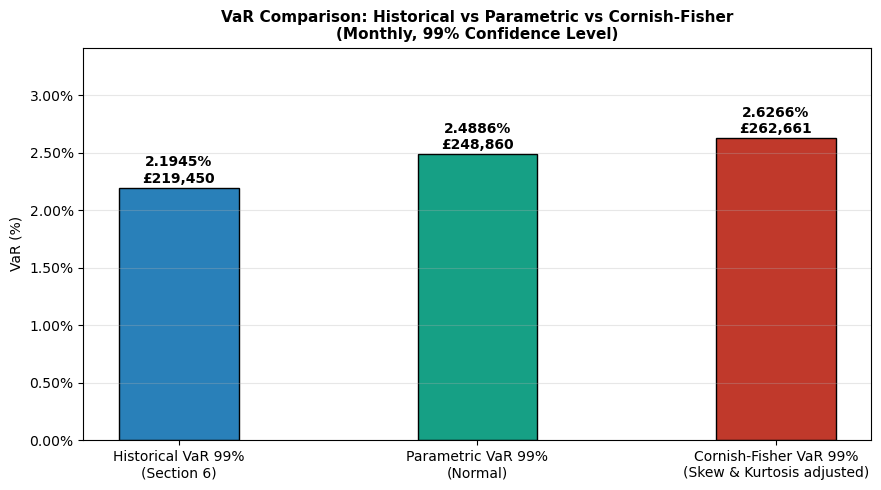

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

var_labels = ["Historical VaR 99%\n(Section 6)",
              "Parametric VaR 99%\n(Normal)",
              "Cornish-Fisher VaR 99%\n(Skew & Kurtosis adjusted)"]
var_values = [var99_monthly * 100, var_normal * 100, var_cf * 100]
var_losses = [var99_monthly * 10_000_000,
              var_normal * 10_000_000,
              var_cf * 10_000_000]
colors = ["#2980b9", "#16a085", "#c0392b"]

bars = ax.bar(var_labels, var_values, color=colors,
              edgecolor="black", width=0.4)

for bar, val, loss in zip(bars, var_values, var_losses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.4f}%\n£{loss:,.0f}",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_ylabel("VaR (%)")
ax.set_title("VaR Comparison: Historical vs Parametric vs Cornish-Fisher\n(Monthly, 99% Confidence Level)",
             fontweight="bold", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.set_ylim(0, max(var_values) * 1.3)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("cornish_fisher_var.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# find the worst 12-month rolling window in our data
port_returns_clean = port_returns.dropna()
losses_all = -port_returns_clean

# rolling 12-month window — find the one with highest average loss
rolling_mean_loss = losses_all.rolling(window=12).mean()
worst_window_end  = rolling_mean_loss.idxmax()
worst_window_start = worst_window_end - pd.DateOffset(months=11)

stressed_returns = port_returns_clean.loc[
    (port_returns_clean.index >= worst_window_start) &
    (port_returns_clean.index <= worst_window_end)]

print(f"Worst 12-month window: {worst_window_start.date()} → {worst_window_end.date()}")
print(f"Number of months: {len(stressed_returns)}")
print(f"Mean return in stressed period: {stressed_returns.mean():.4%}")
print(f"\nMonthly returns in stressed window:")
print(stressed_returns.round(4).to_string())

# calculate SVaR
svar99_hist  = np.quantile(-stressed_returns, 0.99)
svar95_hist  = np.quantile(-stressed_returns, 0.95)

mu_s    = stressed_returns.mean()
sigma_s = stressed_returns.std(ddof=1)
svar99_param = norm.ppf(0.99) * sigma_s - mu_s

print(f"\nSVaR 99% historical:  {svar99_hist:.4%}  £{svar99_hist*10_000_000:,.0f}")
print(f"SVaR 95% historical:  {svar95_hist:.4%}  £{svar95_hist*10_000_000:,.0f}")
print(f"SVaR 99% parametric:  {svar99_param:.4%}  £{svar99_param*10_000_000:,.0f}")
print(f"\nNormal VaR 99%:       {var99_monthly:.4%}  £{var99_monthly*10_000_000:,.0f}")
print(f"SVaR / VaR ratio:     {svar99_param/var_normal:.2f}x")

Worst 12-month window: 2022-08-31 → 2023-07-31
Number of months: 12
Mean return in stressed period: -0.1081%

Monthly returns in stressed window:
Date
2022-08-31   -0.0012
2022-09-30   -0.0207
2022-10-31    0.0149
2022-11-30    0.0080
2022-12-31   -0.0137
2023-01-31    0.0118
2023-02-28   -0.0141
2023-03-31    0.0123
2023-04-30   -0.0021
2023-05-31   -0.0096
2023-06-30   -0.0082
2023-07-31    0.0096

SVaR 99% historical:  1.9966%  £199,660
SVaR 95% historical:  1.7066%  £170,663
SVaR 99% parametric:  2.9448%  £294,483

Normal VaR 99%:       2.1945%  £219,450
SVaR / VaR ratio:     1.18x


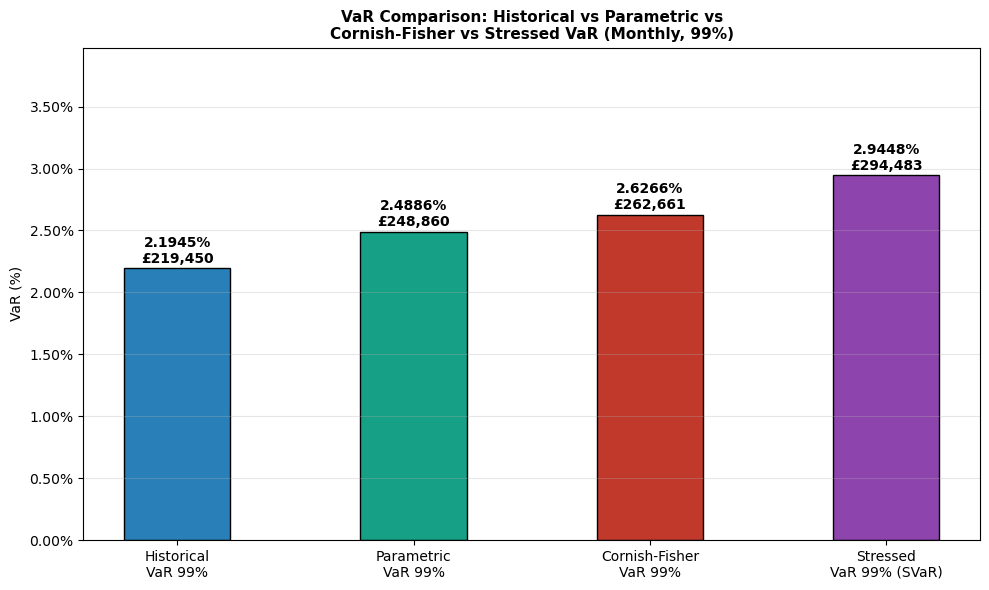

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

var_labels = [
    "Historical\nVaR 99%",
    "Parametric\nVaR 99%",
    "Cornish-Fisher\nVaR 99%",
    "Stressed\nVaR 99% (SVaR)",
]
var_values = [var99_monthly * 100, var_normal * 100,
              var_cf * 100, svar99_param * 100]
var_losses = [var99_monthly * 10_000_000, var_normal * 10_000_000,
              var_cf * 10_000_000, svar99_param * 10_000_000]
colors = ["#2980b9", "#16a085", "#c0392b", "#8e44ad"]

bars = ax.bar(var_labels, var_values, color=colors,
              edgecolor="black", width=0.45)

for bar, val, loss in zip(bars, var_values, var_losses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.4f}%\n£{loss:,.0f}",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_ylabel("VaR (%)")
ax.set_title("VaR Comparison: Historical vs Parametric vs\nCornish-Fisher vs Stressed VaR (Monthly, 99%)",
             fontweight="bold", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.set_ylim(0, max(var_values) * 1.35)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("var_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# bid-ask spreads per asset type — documented typical spreads
# source: standard ETF market microstructure literature
BID_ASK_SPREADS = {
    "SGLN LN Equity":  0.0020,
    "XLE US Equity":   0.0003,
    "ITA US Equity":   0.0005,
    "TAIL US Equity":  0.0010,
    "LT09TRUU Index":  0.0005,
    "LSG1TRGU Index":  0.0015,
    "WTMF US Equity":  0.0015,
    "QAI US Equity":   0.0010,
    "XLP US Equity":   0.0003,
    "BRK/B US Equity": 0.0002,
    "ITPS LN Equity":  0.0025,
    "ERNS LN Equity":  0.0020,
    "IGLS LN Equity":  0.0020,
    "SLXX LN Equity":  0.0020,
    "SCHD US Equity":  0.0003,
}

PORTFOLIO_VALUE = 10_000_000

# weighted average spread
spreads = pd.Series(BID_ASK_SPREADS)
weighted_spread = (WEIGHTS * spreads).sum()

# LVaR = VaR + liquidity cost
# liquidity cost = 0.5 * spread * portfolio value
liq_cost = 0.5 * weighted_spread * PORTFOLIO_VALUE
lvar99   = var99_monthly + 0.5 * weighted_spread

print(f"Weighted average bid-ask spread: {weighted_spread:.4%}")
print(f"Liquidity cost on £10M:          £{liq_cost:,.0f}")
print(f"\nNormal VaR 99%:   {var99_monthly:.4%}   £{var99_monthly*PORTFOLIO_VALUE:,.0f}")
print(f"LVaR 99%:         {lvar99:.4%}   £{lvar99*PORTFOLIO_VALUE:,.0f}")
print(f"Liquidity adjustment: +{0.5*weighted_spread:.4%}  £{liq_cost:,.0f}")

Weighted average bid-ask spread: 0.1359%
Liquidity cost on £10M:          £6,796

Normal VaR 99%:   2.1945%   £219,450
LVaR 99%:         2.2625%   £226,246
Liquidity adjustment: +0.0680%  £6,796


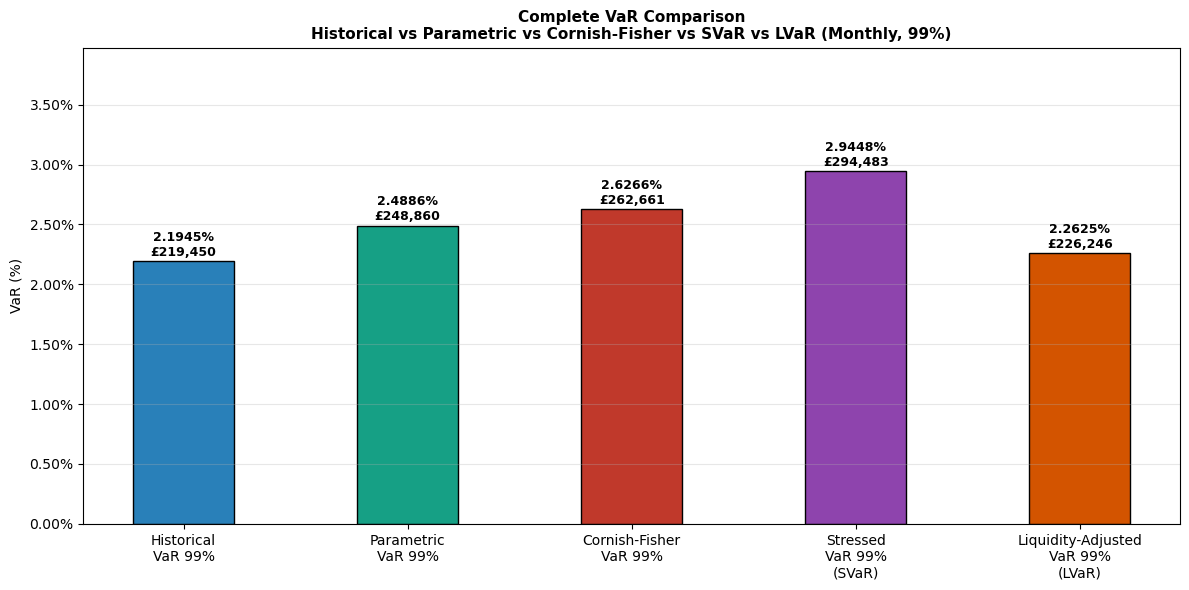

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

var_labels = [
    "Historical\nVaR 99%",
    "Parametric\nVaR 99%",
    "Cornish-Fisher\nVaR 99%",
    "Stressed\nVaR 99%\n(SVaR)",
    "Liquidity-Adjusted\nVaR 99%\n(LVaR)",
]
var_values = [var99_monthly * 100, var_normal * 100,
              var_cf * 100, svar99_param * 100, lvar99 * 100]
var_losses = [v * 10_000_000 / 100 for v in var_values]
colors = ["#2980b9", "#16a085", "#c0392b", "#8e44ad", "#d35400"]

bars = ax.bar(var_labels, var_values, color=colors,
              edgecolor="black", width=0.45)

for bar, val, loss in zip(bars, var_values, var_losses):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{val:.4f}%\n£{loss:,.0f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.set_ylabel("VaR (%)")
ax.set_title("Complete VaR Comparison\nHistorical vs Parametric vs Cornish-Fisher vs SVaR vs LVaR (Monthly, 99%)",
             fontweight="bold", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.set_ylim(0, max(var_values) * 1.35)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("var_comparison_complete.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import skew, kurtosis

# ---- configuration ----
PORTFOLIO_FILE = 'data_gross.xlsx'      # 17-instrument Total Return data
BENCHMARK_FILE = 'zx.xlsx'              # Bloomberg benchmark data
START_DATE     = '2017-04-01'           # analysis window start

# Final optimised portfolio weights (%)
WEIGHTS = {
    'SGLN LN Equity': 11.8057, 'XLE US Equity':   3.0280,
    'ITA US Equity':   1.5000, 'TAIL US Equity':  2.0000,
    'LT09TRUU Index': 13.3453, 'LSG1TRGU Index':  4.6547,
    'WTMF US Equity':  6.3605, 'QAI US Equity':   5.6395,
    'XLP US Equity':   2.1874, 'BRK/B US Equity': 5.0000,
    'ULVR LN Equity':  1.5000, 'ITPS LN Equity':  6.5000,
    'INXG LN Equity':  1.5000, 'ERNS LN Equity': 13.7653,
    'IGLS LN Equity':  9.5795, 'SLXX LN Equity':  3.6342,
    'SCHD US Equity':  8.0000,
}
print(f'{len(WEIGHTS)} instruments, weights sum to {sum(WEIGHTS.values()):.2f}%')

17 instruments, weights sum to 100.00%


## 2. Load Portfolio Data

`data_gross.xlsx` stores, for each instrument, three columns: PX_LAST,
Total Return (Gross Dividends), and Total Return (Net Dividends).
We use the **Gross Dividends Total Return Index** for return computation.

In [ ]:
def load_portfolio_prices(path, start_date):
    raw = pd.read_excel(path, sheet_name=0, header=None)
    ticker_row = raw.iloc[0]
    seen, ticker_to_col = set(), {}
    for i in range(1, len(ticker_row), 3):
        t = ticker_row.iloc[i]
        if pd.notna(t) and t not in seen:
            seen.add(t)
            ticker_to_col[t] = i
    data = {'Date': pd.to_datetime(raw.iloc[3:, 0]).reset_index(drop=True)}
    for ticker, col in ticker_to_col.items():
        # gross dividends total return is the column after PX_LAST
        data[ticker] = pd.to_numeric(raw.iloc[3:, col + 1],
                                     errors='coerce').reset_index(drop=True)
    prices = pd.DataFrame(data).set_index('Date').sort_index()
    return prices[prices.index >= start_date]

prices = load_portfolio_prices(PORTFOLIO_FILE, START_DATE)
print(f'Portfolio prices: {prices.shape[0]} months, '
      f'{prices.index.min().date()} to {prices.index.max().date()}')
prices.head()

Portfolio prices: 109 months, 2017-04-28 to 2026-04-30


,SGLN LN Equity,XLE US Equity,ITA US Equity,TAIL US Equity,LT09TRUU Index,LSG1TRGU Index,WTMF US Equity,QAI US Equity,XLP US Equity,BRK/B US Equity,ULVR LN Equity,ITPS LN Equity,INXG LN Equity,ERNS LN Equity,IGLS LN Equity,SLXX LN Equity,SCHD US Equity
Date,,,,,,,,,,,,,,,,,
2017-04-28,19.295,27.01508,60.19059,19.17375,452.07,270.7262,30.78031,22.51778,43.90784,127.57529,44.339,156.530,18.7592,101.2796,135.8077,151.9392,11.94008
2017-05-31,19.345,26.18066,62.06355,19.30077,455.99,272.0287,30.65167,22.72345,45.27938,128.22343,48.717,157.190,18.4165,101.3452,135.8128,154.3694,12.20503
2017-06-30,18.845,25.91137,61.46983,18.78271,453.30,266.3748,29.98924,22.60957,43.86094,130.20449,46.731,155.040,17.9208,101.4084,135.0739,152.4203,12.08233
2017-07-31,18.950,26.22300,63.53041,18.12724,455.02,267.1835,29.28734,22.50230,43.55492,132.65353,48.604,153.315,17.6527,101.4690,135.3896,154.0516,12.11377
2017-08-31,20.135,25.35529,67.37715,18.92546,461.69,272.6890,30.05677,23.13521,44.06349,140.49946,51.199,158.430,18.5024,101.5095,135.7700,155.4633,12.38915


## 3. Compute Portfolio Returns

Monthly **logarithmic returns** are used throughout. The TAIL holding has
missing values early in the sample; these are filled with zero (its 2%
weight makes the effect immaterial). Weights are normalised to sum to 1.

In [ ]:
log_returns = np.log(prices / prices.shift(1)).fillna(0).iloc[1:]

w = pd.Series({t: WEIGHTS[t] for t in prices.columns})
w = w / w.sum()                       # normalise to 1

portfolio_returns = (log_returns * w).sum(axis=1)
print(f'Portfolio return series: {len(portfolio_returns)} observations')
print(f'Annualised return: {portfolio_returns.mean()*12*100:.2f}%')
print(f'Annualised volatility: {portfolio_returns.std()*np.sqrt(12)*100:.2f}%')

Portfolio return series: 108 observations
Annualised return: 4.62%
Annualised volatility: 4.42%


## 4. Load Bloomberg Benchmark Data

`zx.xlsx` contains the Bloomberg series. Only three are needed to build
all benchmarks: SONIA overnight rate, MSCI ACWI Net Total Return, and the
Bloomberg Global Aggregate Total Return Index (the latter two GBP-translated).

In [ ]:
def load_benchmark_data(path, start_date):
    raw = pd.read_excel(path, sheet_name='Sheet1', header=None)
    idx_row = raw.iloc[3]
    idx_to_col = {idx_row.iloc[i]: i for i in range(4, len(idx_row), 3)
                  if pd.notna(idx_row.iloc[i])}
    dates = pd.to_datetime(raw.iloc[6:, 3], errors='coerce').reset_index(drop=True)
    data = {'Date': dates}
    for name in ['SONIO/N Index', 'LEGATRUU Index', 'NDDUWI Index']:
        data[name] = pd.to_numeric(raw.iloc[6:, idx_to_col[name]],
                                   errors='coerce').reset_index(drop=True)
    bench = pd.DataFrame(data).set_index('Date').sort_index()
    return bench[bench.index >= start_date]

bench = load_benchmark_data(BENCHMARK_FILE, START_DATE)
print(f'Benchmark data: {bench.shape[0]} months')
bench.head()

Benchmark data: 109 months


,SONIO/N Index,LEGATRUU Index,NDDUWI Index
Date,,,
2017-04-28,0.2108,464.4815,4037.6263
2017-05-31,0.2087,471.6692,4142.2320
2017-06-30,0.1940,471.2553,4120.4490
2017-07-31,0.2034,479.1785,4160.8453
2017-08-31,0.2109,483.9256,4262.3569


## 5. Construct the Three Benchmarks

**SONIA + 4%** — monthly SONIA rate plus a 4%/12 spread.

**Conservative (volatility-matched)** — a three-asset blend of MSCI ACWI,
Global Aggregate and cash. The equity/bond split is solved numerically so
the benchmark's annualised volatility equals the portfolio's exactly. A
cash weight of 35% is required because a pure equity/bond blend cannot
reach the portfolio's low volatility.

**60/40** — the conventional 60% equity / 40% bond reference.

In [ ]:
# benchmark building blocks
sonia_monthly = bench['SONIO/N Index'] / 100 / 12
acwi_ret = np.log(bench['NDDUWI Index'] / bench['NDDUWI Index'].shift(1))
agg_ret  = np.log(bench['LEGATRUU Index'] / bench['LEGATRUU Index'].shift(1))

# align to portfolio dates
df = pd.DataFrame({'cash': sonia_monthly, 'acwi': acwi_ret, 'agg': agg_ret})
df = df.dropna().reindex(portfolio_returns.index).dropna()
p  = portfolio_returns.reindex(df.index)

target_vol = p.std() * np.sqrt(12)
print(f'Target (portfolio) volatility: {target_vol*100:.3f}%')

# --- solve Conservative benchmark: fix cash = 35%, solve equity weight ---
CASH_W = 0.35
remain = 1 - CASH_W

def vol_gap(equity_w):
    bond_w = remain - equity_w
    r = equity_w*df['acwi'] + bond_w*df['agg'] + CASH_W*df['cash']
    return r.std()*np.sqrt(12) - target_vol

equity_w = brentq(vol_gap, 0, remain)
bond_w   = remain - equity_w
print(f'Conservative weights: Equity {equity_w*100:.1f}% / '
      f'Bond {bond_w*100:.1f}% / Cash {CASH_W*100:.0f}%')

Target (portfolio) volatility: 4.416%
Conservative weights: Equity 20.8% / Bond 44.2% / Cash 35%


In [ ]:
benchmarks = pd.DataFrame({
    'SONIA + 4%':   sonia_monthly + 0.04/12,
    'Conservative': equity_w*acwi_ret + bond_w*agg_ret + CASH_W*sonia_monthly,
    '60/40':        0.60*acwi_ret + 0.40*agg_ret,
}).dropna().reindex(p.index).dropna()

p = p.reindex(benchmarks.index)
rf = sonia_monthly.reindex(p.index).ffill().bfill()   # risk-free proxy

print('Benchmark annualised volatilities:')
for col in benchmarks.columns:
    print(f'  {col:15s}: {benchmarks[col].std()*np.sqrt(12)*100:.2f}%')

Benchmark annualised volatilities:
  SONIA + 4%     : 0.59%
  Conservative   : 4.42%
  60/40          : 8.59%


## 6. Metric Definitions

In [ ]:
def ann_return(r):       return r.mean() * 12
def ann_volatility(r):   return r.std() * np.sqrt(12)
def sharpe(r, rf):       return (r-rf).mean()*12 / (r.std()*np.sqrt(12))

def sortino(r, rf):
    downside = r[r < rf.mean()]
    if downside.std() == 0: return np.nan
    return (r-rf).mean()*12 / (downside.std()*np.sqrt(12))

def max_drawdown(r):
    cum = (1+r).cumprod()
    peak = cum.expanding().max()
    return ((cum-peak)/peak).min()

def calmar(r):
    mdd = max_drawdown(r)
    return ann_return(r)/abs(mdd) if mdd < 0 else np.nan

def adverse_vol(r):      return r[r < 0].std() * np.sqrt(12)
def var99_param(r):      return -(r.mean() - 2.326*r.std())
def var99_hist(r):       return -r.quantile(0.01)

def tracking_error(p, b):  return (p-b).std() * np.sqrt(12)
def information_ratio(p, b):
    e = p - b
    return e.mean()*12 / (e.std()*np.sqrt(12)) if e.std() > 0 else np.nan

def jensen_alpha_beta(p, b, rf):
    pe, be = p-rf, b-rf
    if be.var() < 1e-8:                       # cash-plus has no variance
        return np.nan, np.nan
    beta = np.cov(pe, be)[0,1] / be.var()
    alpha = (pe.mean() - beta*be.mean()) * 12
    return alpha, beta

## 7. Performance & Risk Table (reproduces report Table 2)

In [ ]:
series = {'Portfolio': p,
          'SONIA + 4%':   benchmarks['SONIA + 4%'],
          'Conservative': benchmarks['Conservative'],
          '60/40':        benchmarks['60/40']}

rows = {}
for name, r in series.items():
    rows[name] = {
        'Ann Return %':   ann_return(r)*100,
        'Ann Vol %':      ann_volatility(r)*100,
        'Sharpe':         sharpe(r, rf),
        'Sortino':        sortino(r, rf),
        'Max DD %':       max_drawdown(r)*100,
        'Calmar':         calmar(r),
        'Adverse Vol %':  adverse_vol(r)*100,
        'VaR99 param %':  var99_param(r)*100,
        'VaR99 hist %':   var99_hist(r)*100,
        'Skewness':       skew(r),
        'Excess Kurtosis':kurtosis(r),
    }

performance = pd.DataFrame(rows).round(3)
performance

,Portfolio,SONIA + 4%,Conservative,60/40
Ann Return %,4.622,6.033,3.424,7.062
Ann Vol %,4.416,0.587,4.416,8.587
Sharpe,0.586,6.818,0.315,0.586
Sortino,1.039,NaN,0.425,0.817
Max DD %,-4.666,0.000,-11.193,-14.242
Calmar,0.991,NaN,0.306,0.496
Adverse Vol %,2.409,NaN,3.182,6.129
VaR99 param %,2.580,-0.109,2.680,5.178
VaR99 hist %,2.424,-0.337,3.366,5.317
Skewness,0.056,0.480,-0.478,-0.512


## 8. Relative Metrics (reproduces report Appendix B.3)

In [ ]:
rel = {}
for name in ['SONIA + 4%', 'Conservative', '60/40']:
    b = benchmarks[name]
    alpha, beta = jensen_alpha_beta(p, b, rf)
    rel[name] = {
        'Tracking Error %':   tracking_error(p, b)*100,
        'Information Ratio':  information_ratio(p, b),
        "Jensen's Alpha %":   alpha*100 if not np.isnan(alpha) else np.nan,
        'Beta':               beta,
    }

relative = pd.DataFrame(rel).T.round(3)
relative

,Tracking Error %,Information Ratio,Jensen's Alpha %,Beta
SONIA + 4%,4.408,-0.320,NaN,NaN
Conservative,4.024,0.298,1.777,0.584
60/40,6.739,-0.362,0.963,0.323


## 9. Cumulative Return & Drawdown Chart (reproduces report Figure B1)

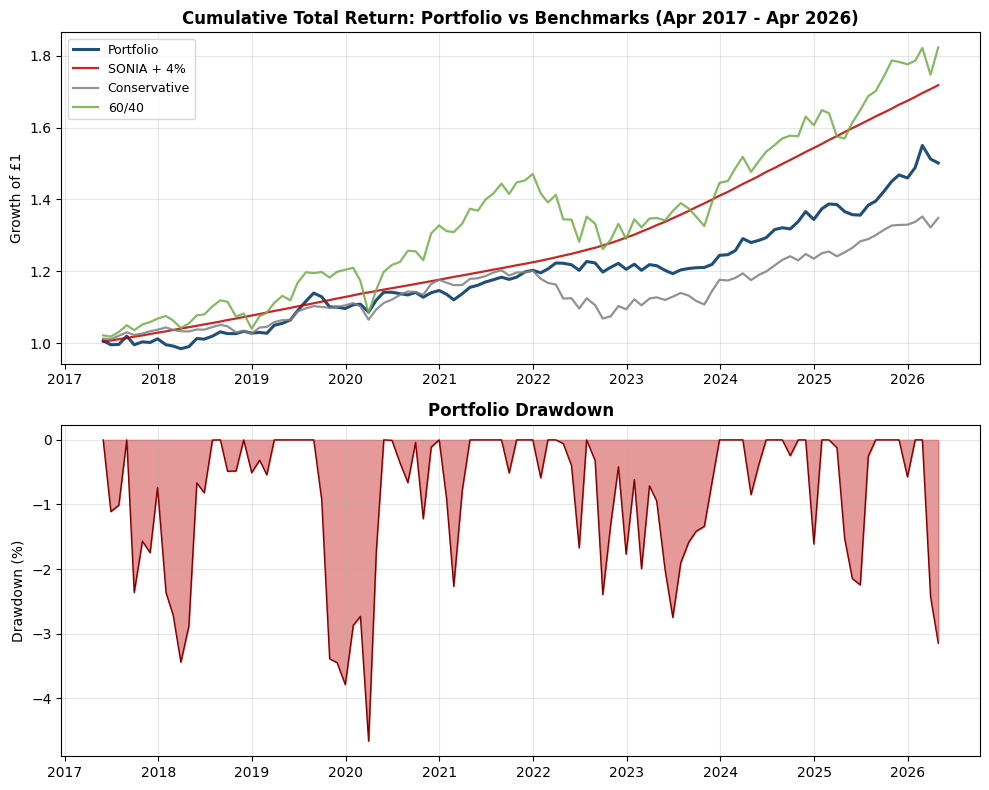

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# cumulative return
cum_p = (1+p).cumprod()
axes[0].plot(cum_p.index, cum_p.values, label='Portfolio',
             linewidth=2.2, color='#1F4E78')
for name, col in zip(benchmarks.columns, ['#C00000', '#7F7F7F', '#70AD47']):
    cum_b = (1+benchmarks[name]).cumprod()
    axes[0].plot(cum_b.index, cum_b.values, label=name,
                 linewidth=1.6, color=col, alpha=0.85)
axes[0].set_title('Cumulative Total Return: Portfolio vs Benchmarks '
                  '(Apr 2017 - Apr 2026)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Growth of \u00a31')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

# drawdown
cum = (1+p).cumprod()
dd = (cum - cum.expanding().max()) / cum.expanding().max() * 100
axes[1].fill_between(dd.index, dd.values, 0, color='#C00000', alpha=0.4)
axes[1].plot(dd.index, dd.values, color='#7F0000', linewidth=1)
axes[1].set_title('Portfolio Drawdown', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('s4_chart.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Summary of Reported Figures

| Metric | Portfolio | SONIA + 4% | Conservative | 60/40 |
|---|---|---|---|---|
| Annualised Return | 4.62% | 6.03% | 3.42% | 7.06% |
| Annualised Volatility | 4.42% | 0.59% | 4.42% | 8.59% |
| Sharpe Ratio | 0.59 | — | 0.32 | 0.59 |
| Sortino Ratio | 1.04 | — | 0.43 | 0.82 |
| Maximum Drawdown | -4.67% | 0.00% | -11.19% | -14.24% |
| Skewness | +0.06 | +0.48 | -0.48 | -0.51 |

**Relative to the volatility-matched Conservative benchmark:**
Information Ratio +0.30, Jensen's Alpha +1.78%, Beta 0.58.

**Key conclusions**
- The portfolio meets its capital-preservation objective: a -4.67% maximum
  drawdown against -11.19% / -14.24% for the multi-asset benchmarks.
- Against a benchmark of *identical* 4.42% volatility, the portfolio earns
  a positive information ratio and positive Jensen's alpha — evidence of
  genuine risk-adjusted skill rather than risk-taking.
- The portfolio avoids the negative skewness of both conventional
  multi-asset benchmarks.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, jarque_bera

PORTFOLIO_FILE = 'data_gross.xlsx'
START_DATE     = '2017-04-01'

# Final optimised portfolio weights (%)
WEIGHTS = {
    'SGLN LN Equity': 11.8057, 'XLE US Equity':   3.0280,
    'ITA US Equity':   1.5000, 'TAIL US Equity':  2.0000,
    'LT09TRUU Index': 13.3453, 'LSG1TRGU Index':  4.6547,
    'WTMF US Equity':  6.3605, 'QAI US Equity':   5.6395,
    'XLP US Equity':   2.1874, 'BRK/B US Equity': 5.0000,
    'ULVR LN Equity':  1.5000, 'ITPS LN Equity':  6.5000,
    'INXG LN Equity':  1.5000, 'ERNS LN Equity': 13.7653,
    'IGLS LN Equity':  9.5795, 'SLXX LN Equity':  3.6342,
    'SCHD US Equity':  8.0000,
}

# functional sleeve of each holding
SLEEVE = {
    'SGLN LN Equity': 'Geopolitical Hedge', 'XLE US Equity': 'Geopolitical Hedge',
    'ITA US Equity':  'Geopolitical Hedge', 'TAIL US Equity':'Geopolitical Hedge',
    'LT09TRUU Index': 'Recession Protection','LSG1TRGU Index':'Recession Protection',
    'WTMF US Equity': 'Liquid Alternatives','QAI US Equity':  'Liquid Alternatives',
    'XLP US Equity':  'Defensive Growth',  'BRK/B US Equity': 'Defensive Growth',
    'ULVR LN Equity': 'Defensive Growth',  'SCHD US Equity':  'Defensive Growth',
    'ITPS LN Equity': 'Inflation Hedge',   'INXG LN Equity':  'Inflation Hedge',
    'ERNS LN Equity': 'Liquidity Reserve', 'IGLS LN Equity':  'Liquidity Reserve',
    'SLXX LN Equity': 'Income / Carry',
}
print(f'{len(WEIGHTS)} instruments configured')

17 instruments configured


## 2. Load Data and Compute Returns

`data_gross.xlsx` stores three columns per instrument (PX_LAST, gross-
and net-dividend Total Return). We use the **gross-dividend Total Return
Index** and compute monthly **logarithmic returns**.

In [ ]:
def load_portfolio_prices(path, start_date):
    raw = pd.read_excel(path, sheet_name=0, header=None)
    ticker_row = raw.iloc[0]
    seen, ticker_to_col = set(), {}
    for i in range(1, len(ticker_row), 3):
        t = ticker_row.iloc[i]
        if pd.notna(t) and t not in seen:
            seen.add(t)
            ticker_to_col[t] = i
    data = {'Date': pd.to_datetime(raw.iloc[3:, 0]).reset_index(drop=True)}
    for ticker, col in ticker_to_col.items():
        data[ticker] = pd.to_numeric(raw.iloc[3:, col + 1],
                                     errors='coerce').reset_index(drop=True)
    prices = pd.DataFrame(data).set_index('Date').sort_index()
    return prices[prices.index >= start_date]

prices = load_portfolio_prices(PORTFOLIO_FILE, START_DATE)
log_returns = np.log(prices / prices.shift(1)).iloc[1:]

print(f'Price data : {prices.shape[0]} months, '
      f'{prices.index.min().date()} to {prices.index.max().date()}')
print(f'Return data: {log_returns.shape[0]} monthly observations')

Price data : 109 months, 2017-04-28 to 2026-04-30
Return data: 108 monthly observations


## 3. Descriptive Statistics — Individual Holdings

For every instrument we report annualised return and volatility, skewness,
excess kurtosis, and the minimum and maximum single-month return.

In [ ]:
def describe(returns):
    r = returns.dropna()
    return {
        'Ann Ret %':  r.mean()*12*100,
        'Ann Vol %':  r.std()*np.sqrt(12)*100,
        'Skew':       skew(r),
        'Ex. Kurt':   kurtosis(r),
        'Min %':      r.min()*100,
        'Max %':      r.max()*100,
    }

stats = {}
for ticker in WEIGHTS:
    row = {'Sleeve': SLEEVE[ticker], 'Wt %': WEIGHTS[ticker]}
    row.update(describe(log_returns[ticker]))
    stats[ticker] = row

holdings_stats = pd.DataFrame(stats).T
holdings_stats = holdings_stats[['Sleeve','Wt %','Ann Ret %','Ann Vol %',
                                 'Skew','Ex. Kurt','Min %','Max %']]
holdings_stats.round(2)

,Sleeve,Wt %,Ann Ret %,Ann Vol %,Skew,Ex. Kurt,Min %,Max %
SGLN LN Equity,Geopolitical Hedge,11.8057,13.672956,13.737907,-0.03573,0.680357,-10.549313,12.644911
XLE US Equity,Geopolitical Hedge,3.028,9.999064,29.564507,-0.610447,4.005055,-39.07032,25.349166
ITA US Equity,Geopolitical Hedge,1.5,12.089702,20.233425,-1.264994,6.333138,-29.969688,17.05866
TAIL US Equity,Geopolitical Hedge,2.0,-7.787097,15.318871,0.402246,0.999613,-12.235059,13.69052
LT09TRUU Index,Recession Protection,13.3453,1.141155,6.641781,-0.086997,-0.076655,-4.802131,4.440768
LSG1TRGU Index,Recession Protection,4.6547,-1.84241,8.520074,-0.764885,1.330376,-8.844101,5.597268
WTMF US Equity,Liquid Alternatives,6.3605,3.642672,9.463782,-0.022907,-0.361319,-6.948228,6.534302
QAI US Equity,Liquid Alternatives,5.6395,3.460532,6.308202,-0.022205,-0.009897,-4.181744,4.324929
XLP US Equity,Defensive Growth,2.1874,6.876611,11.797771,-0.065275,0.140245,-9.264992,9.328464
BRK/B US Equity,Defensive Growth,5.0,11.175452,15.596994,-0.037915,-0.487391,-11.039992,11.236899


## 4. Portfolio-Level Statistics

In [ ]:
# normalise weights and build the portfolio return series
w = pd.Series({t: WEIGHTS[t] for t in prices.columns})
w = w / w.sum()
portfolio_returns = (log_returns.fillna(0) * w).sum(axis=1)

port_stats = describe(portfolio_returns)
port_stats['Wt %'] = 100.0
port_stats['Sleeve'] = 'All 17 holdings'

print('Portfolio descriptive statistics:')
for k in ['Ann Ret %','Ann Vol %','Skew','Ex. Kurt','Min %','Max %']:
    print(f'  {k:12s}: {port_stats[k]:+.2f}')

Portfolio descriptive statistics:
  Ann Ret %   : +4.62
  Ann Vol %   : +4.42
  Skew        : +0.06
  Ex. Kurt    : -0.10
  Min %       : -2.49
  Max %       : +4.14


## 5. Normality Test and Diversification Check

A **Jarque-Bera test** assesses whether the portfolio return distribution
departs from normality. The **average pairwise correlation** across the
seventeen holdings quantifies the diversification benefit of the
seven-sleeve construction.

In [ ]:
# Jarque-Bera normality test on portfolio returns
jb_stat, jb_pvalue = jarque_bera(portfolio_returns)
print(f'Jarque-Bera statistic: {jb_stat:.2f}')
print(f'Jarque-Bera p-value  : {jb_pvalue:.4f}')
if jb_pvalue < 0.05:
    print('-> reject normality (fat-tailed / skewed distribution)')
else:
    print('-> cannot reject normality (distribution is approximately normal)')

# average pairwise correlation across the 17 holdings
corr = log_returns.fillna(0).corr()
n = len(corr)
avg_corr = (corr.values.sum() - n) / (n*(n-1))
print(f'\nAverage pairwise correlation: {avg_corr:.3f}')

# weighted-average individual volatility vs portfolio volatility
wavg_vol = sum(w[t] * log_returns[t].dropna().std()*np.sqrt(12)
               for t in w.index)
port_vol = portfolio_returns.std()*np.sqrt(12)
print(f'Weighted-average individual volatility: {wavg_vol*100:.2f}%')
print(f'Actual portfolio volatility           : {port_vol*100:.2f}%')
print(f'Diversification reduction             : '
      f'{(wavg_vol-port_vol)*100:.2f} percentage points')

Jarque-Bera statistic: 0.10
Jarque-Bera p-value  : 0.9516
-> cannot reject normality (distribution is approximately normal)

Average pairwise correlation: 0.204
Weighted-average individual volatility: 9.04%
Actual portfolio volatility           : 4.42%
Diversification reduction             : 4.63 percentage points


## 6. Full Descriptive-Statistics Table (reproduces Appendix C.5)

In [ ]:
# append the portfolio row to the holdings table
full_table = holdings_stats.copy()
port_row = pd.DataFrame([{
    'Sleeve': 'All 17 holdings', 'Wt %': 100.0,
    'Ann Ret %': port_stats['Ann Ret %'], 'Ann Vol %': port_stats['Ann Vol %'],
    'Skew': port_stats['Skew'], 'Ex. Kurt': port_stats['Ex. Kurt'],
    'Min %': port_stats['Min %'], 'Max %': port_stats['Max %'],
}], index=['Portfolio'])
full_table = pd.concat([full_table, port_row])

# round numeric columns for presentation
numeric_cols = ['Wt %','Ann Ret %','Ann Vol %','Skew','Ex. Kurt','Min %','Max %']
full_table[numeric_cols] = full_table[numeric_cols].astype(float).round(2)
full_table

,Sleeve,Wt %,Ann Ret %,Ann Vol %,Skew,Ex. Kurt,Min %,Max %
SGLN LN Equity,Geopolitical Hedge,11.81,13.67,13.74,-0.04,0.68,-10.55,12.64
XLE US Equity,Geopolitical Hedge,3.03,10.00,29.56,-0.61,4.01,-39.07,25.35
ITA US Equity,Geopolitical Hedge,1.50,12.09,20.23,-1.26,6.33,-29.97,17.06
TAIL US Equity,Geopolitical Hedge,2.00,-7.79,15.32,0.40,1.00,-12.24,13.69
LT09TRUU Index,Recession Protection,13.35,1.14,6.64,-0.09,-0.08,-4.80,4.44
LSG1TRGU Index,Recession Protection,4.65,-1.84,8.52,-0.76,1.33,-8.84,5.60
WTMF US Equity,Liquid Alternatives,6.36,3.64,9.46,-0.02,-0.36,-6.95,6.53
QAI US Equity,Liquid Alternatives,5.64,3.46,6.31,-0.02,-0.01,-4.18,4.32
XLP US Equity,Defensive Growth,2.19,6.88,11.80,-0.07,0.14,-9.26,9.33
BRK/B US Equity,Defensive Growth,5.00,11.18,15.60,-0.04,-0.49,-11.04,11.24


## 7. Summary of Reported Figures

**Methodology**
- Sampling frequency: **monthly** — appropriate for a long-term multi-asset
  fund; avoids spurious autocorrelation from non-synchronous daily pricing.
- Period: **April 2017 – April 2026**, 108 monthly observations — long
  enough for stable estimation and spanning the COVID-19 crash, the 2022
  inflation shock and the UK gilt dislocation.
- Returns: **monthly logarithmic returns**; annualised by ×12 (mean) and
  ×√12 (volatility).

**Portfolio descriptive statistics (Apr 2017 – Apr 2026)**

| Statistic | Value |
|---|---|
| Annualised return | 4.62% |
| Annualised volatility | 4.42% |
| Skewness | +0.06 |
| Excess kurtosis | -0.10 |
| Worst month | -2.49% |
| Best month | +4.14% |

**Key observations**
- **Wide risk dispersion:** holdings range from ~0.9% volatility
  (ERNS, cash-equivalent) to ~29.6% (XLE, energy equity), allowing the
  optimisation to combine return engines with stabilisers.
- **Low average correlation (~0.20):** the seven-sleeve construction
  drives the portfolio's volatility well below the weighted-average of
  the individual holdings' volatilities — a genuine diversification
  benefit.
- **Near-normal, well-behaved distribution:** the portfolio return series
  has skewness near zero and slightly negative excess kurtosis, and the
  Jarque-Bera test does not reject normality — the portfolio shows no
  fat-tail behaviour, consistent with the capital-preservation objective.
- **Narrow return range:** the worst (-2.49%) and best (+4.14%) months
  form a far tighter band than almost any individual holding — direct
  evidence the capital-preservation objective is met.

## Risk_analysis

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm

In [ ]:
#data import
df = pd.read_csv('~/Downloads/data_gross.csv')
date_col = df.columns[0]
df = df.iloc[2:].copy()
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")
df = df.set_index(date_col)
df.index.name = "Date"
df = df[~df.index.isna()]

In [ ]:
# Data cleaning
df = df.sort_index()
print(df.head())
print(df.index)
cols = list(df.columns)
selected_cols = []
selected_names = []
for i in range(0, len(cols), 3):
    asset_name = cols[i]
    target_col = cols[i + 2]
    selected_cols.append(target_col)
    selected_names.append(asset_name)
prices = df[selected_cols].copy()
prices.columns = selected_names
prices = prices.apply(pd.to_numeric, errors="coerce")
print(prices.head())
print(prices.shape)
print(prices.isna().sum())
prices = prices.drop(prices.columns[8], axis=1)
prices = prices.loc[prices.index > "2017-03-31"].copy()

           SGLN LN Equity Unnamed: 2 Unnamed: 3 XLE US Equity Unnamed: 5  \
Date                                                                       
2016-01-29         15.575     15.575     15.575      20.46333   20.46333   
2016-02-29        17.5025    17.5025    17.5025       20.3335    20.3335   
2016-03-31         16.945     16.945     16.945      21.49854   21.65173   
2016-04-29        17.4525    17.4525    17.4525      23.07535   23.23976   
2016-05-31         16.465     16.465     16.465      23.03479   23.19892   

           Unnamed: 6 ITA US Equity Unnamed: 8 Unnamed: 9 TAIL US Equity  ...  \
Date                                                                      ...   
2016-01-29   20.46333      38.46587   38.46587   38.46587            NaN  ...   
2016-02-29    20.3335      40.31122   40.31122   40.31122            NaN  ...   
2016-03-31   21.65173      40.60372    40.7136    40.7136            NaN  ...   
2016-04-29   23.23976      41.66211   41.77485   41.77485     

In [ ]:
#Return
returns = prices.pct_change().dropna()

weights = pd.Series({
    "SGLN LN Equity": 0.113081,
    "XLE US Equity": 0.041437,
    "ITA US Equity": 0.002867,
    "TAIL US Equity": 0.020000,
    "LT09TRUU Index": 0.130301,
    "LSG1TRGU Index": 0.049699,
    "WTMF US Equity": 0.059526,
    "QAI US Equity": 0.060474,
    "XLP US Equity": 0.029143,
    "BRK/B US Equity": 0.050000,
    "ULVR LN Equity": 0.000000,
    "ITPS LN Equity": 0.080000,
    "INXG LN Equity": 0.000000,
    "ERNS LN Equity": 0.140681,
    "IGLS LN Equity": 0.097012,
    "SLXX LN Equity": 0.045780,
    "SCHD US Equity": 0.080000
})


print(weights)
print("Total weight:", weights.sum())
print("In weights but not in returns:")

selected_returns = returns[weights.index].copy()
portfolio_returns = selected_returns @ weights
portfolio_returns.name = "Base RC Medium Portfolio Return"
print(portfolio_returns.head())
print(portfolio_returns.describe())

SGLN LN Equity     0.113081
XLE US Equity      0.041437
ITA US Equity      0.002867
TAIL US Equity     0.020000
LT09TRUU Index     0.130301
LSG1TRGU Index     0.049699
WTMF US Equity     0.059526
QAI US Equity      0.060474
XLP US Equity      0.029143
BRK/B US Equity    0.050000
ULVR LN Equity     0.000000
ITPS LN Equity     0.080000
INXG LN Equity     0.000000
ERNS LN Equity     0.140681
IGLS LN Equity     0.097012
SLXX LN Equity     0.045780
SCHD US Equity     0.080000
dtype: float64
Total weight: 1.0000010000000001
In weights but not in returns:
Date
2017-05-31    0.005011
2017-06-30   -0.010361
2017-07-31    0.000348
2017-08-31    0.021487
2017-09-29   -0.022039
Name: Base RC Medium Portfolio Return, dtype: float64
count    108.000000
mean       0.004349
std        0.012567
min       -0.023585
25%       -0.003349
50%        0.004433
75%        0.012415
max        0.041827
Name: Base RC Medium Portfolio Return, dtype: float64


In [ ]:
#portfolio data describe
rp = portfolio_returns.dropna()
summary_stats = pd.Series({
    "Mean monthly return": rp.mean(),
    "Monthly volatility": rp.std(ddof=1),
    "Annualised return": (1 + rp.mean()) ** 12 - 1,
    "Annualised volatility": rp.std(ddof=1) * np.sqrt(12),
    "Skewness": skew(rp),
    "Excess kurtosis": kurtosis(rp, fisher=True),
    "Minimum monthly return": rp.min(),
    "Maximum monthly return": rp.max(),
    "Number of observations": rp.count()
})
print(summary_stats)

Mean monthly return         0.004349
Monthly volatility          0.012567
Annualised return           0.053460
Annualised volatility       0.043534
Skewness                    0.179705
Excess kurtosis            -0.043498
Minimum monthly return     -0.023585
Maximum monthly return      0.041827
Number of observations    108.000000
dtype: float64


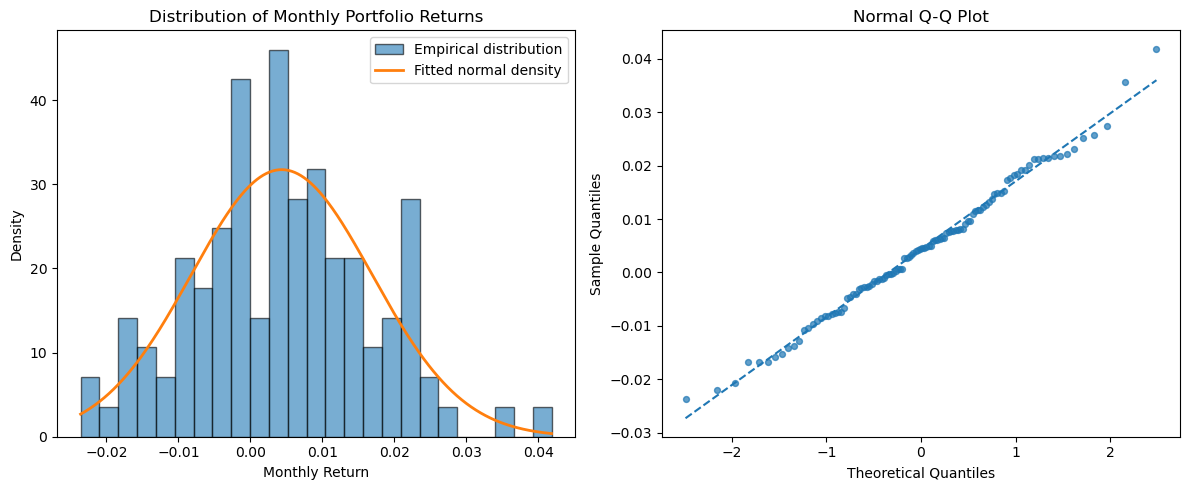

In [ ]:
#plot histogram
# Estimate normal distribution parameters
mu = rp.mean()
sigma = rp.std(ddof=1)

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------
# 1. Histogram + fitted normal
# -----------------------------
x = np.linspace(rp.min(), rp.max(), 300)
pdf = norm.pdf(x, mu, sigma)

axes[0].hist(
    rp,
    bins=25,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Empirical distribution"
)

axes[0].plot(
    x,
    pdf,
    linewidth=2,
    label="Fitted normal density"
)

axes[0].set_title("Distribution of Monthly Portfolio Returns")
axes[0].set_xlabel("Monthly Return")
axes[0].set_ylabel("Density")
axes[0].legend()

# -----------------------------
# 2. Normal QQ plot
# -----------------------------
(osm, osr), (slope, intercept, r) = stats.probplot(rp, dist="norm")

axes[1].scatter(
    osm,
    osr,
    s=18,
    alpha=0.7
)

axes[1].plot(
    osm,
    slope * osm + intercept,
    linestyle="--",
    linewidth=1.5
)
axes[1].set_title("Normal Q-Q Plot")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")
plt.tight_layout()
plt.show()

In [ ]:
# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(rp)
# Jarque-Bera test
jb_stat, jb_p = stats.jarque_bera(rp)
# D'Agostino-Pearson normality test
dagostino_stat, dagostino_p = stats.normaltest(rp)
normality_results = pd.DataFrame({
    "Test": [
        "Shapiro-Wilk",
        "Jarque-Bera",
        "D'Agostino-Pearson"
    ],
    "Test Statistic": [
        shapiro_stat,
        jb_stat,
        dagostino_stat
    ],
    "p-value": [
        shapiro_p,
        jb_p,
        dagostino_p
    ]
})
normality_results["Interpretation at 1% level"] = normality_results["p-value"].apply(
    lambda p: "Reject normality" if p < 0.01 else "Do not reject normality"
)
print(normality_results)

                 Test  Test Statistic   p-value Interpretation at 1% level
0        Shapiro-Wilk        0.991975  0.780358    Do not reject normality
1         Jarque-Bera        0.589806  0.744604    Do not reject normality
2  D'Agostino-Pearson        0.689074  0.708548    Do not reject normality


In [ ]:
#VaR calculation
#99%VaR
losses = -rp
# Historical VaR and CVaR
var95_hist = np.quantile(losses, 0.95)
cvar95_hist = losses[losses >= var95_hist].mean()
var99_hist = np.quantile(losses, 0.99)
cvar99_hist = losses[losses >= var99_hist].mean()
# Parametric VaR
mu = rp.mean()
sigma = rp.std(ddof=1)
z95 = norm.ppf(0.95)
z99 = norm.ppf(0.99)
var95_param = z95 * sigma - mu
var99_param = z99 * sigma - mu
# Downside / adverse volatility
downside_returns = rp[rp < 0]
downside_vol_monthly = downside_returns.std(ddof=1)
downside_vol_annualised = downside_vol_monthly * np.sqrt(12)
risk_summary = pd.Series({
    "Historical VaR 95% monthly": var95_hist,
    "Historical CVaR 95% monthly": cvar95_hist,
    "Historical VaR 99% monthly": var99_hist,
    "Historical CVaR 99% monthly": cvar99_hist,
    "Parametric VaR 95% monthly": var95_param,
    "Parametric VaR 99% monthly": var99_param,
    "Downside volatility monthly": downside_vol_monthly,
    "Downside volatility annualised": downside_vol_annualised
})
print(risk_summary)

Historical VaR 95% monthly        0.016385
Historical CVaR 95% monthly       0.019394
Historical VaR 99% monthly        0.021945
Historical CVaR 99% monthly       0.022812
Parametric VaR 95% monthly        0.016322
Parametric VaR 99% monthly        0.024886
Downside volatility monthly       0.006503
Downside volatility annualised    0.022527
dtype: float64


Bootstrap VaR 99% mean             0.021018
Bootstrap VaR 99% median           0.021945
Bootstrap VaR 99% 2.5% CI          0.016580
Bootstrap VaR 99% 97.5% CI         0.023585
Number of bootstrap samples    10000.000000
dtype: float64


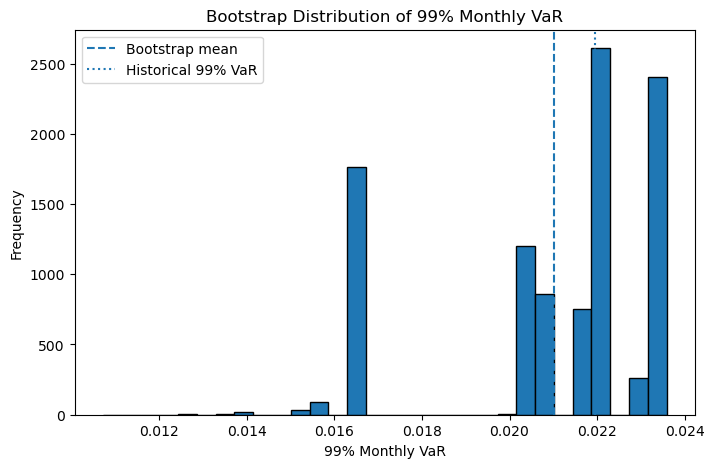

In [ ]:
#Bootstrap check
n_bootstrap = 10000
alpha = 0.99
sample_size = len(losses)
bootstrap_vars = []
np.random.seed(42)
for _ in range(n_bootstrap):
    sample_losses = np.random.choice(losses, size=sample_size, replace=True)
    var_estimate = np.quantile(sample_losses, alpha)
    bootstrap_vars.append(var_estimate)
bootstrap_vars = np.array(bootstrap_vars)
bootstrap_summary = pd.Series({
    "Bootstrap VaR 99% mean": bootstrap_vars.mean(),
    "Bootstrap VaR 99% median": np.median(bootstrap_vars),
    "Bootstrap VaR 99% 2.5% CI": np.quantile(bootstrap_vars, 0.025),
    "Bootstrap VaR 99% 97.5% CI": np.quantile(bootstrap_vars, 0.975),
    "Number of bootstrap samples": n_bootstrap
})
print(bootstrap_summary)
plt.figure(figsize=(8, 5))
plt.hist(bootstrap_vars, bins=30, edgecolor="black")
plt.axvline(bootstrap_vars.mean(), linestyle="--", label="Bootstrap mean")
plt.axvline(np.quantile(losses, 0.99), linestyle=":", label="Historical 99% VaR")
plt.title("Bootstrap Distribution of 99% Monthly VaR")
plt.xlabel("99% Monthly VaR")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
#Backtesting VaR
var95 = np.quantile(losses, 0.95)
var99 = np.quantile(losses, 0.99)
# Exceptions: realised loss > VaR
exceptions95 = losses > var95
exceptions99 = losses > var99
backtest_summary = pd.DataFrame({
    "Confidence Level": ["95%", "99%"],
    "VaR": [var95, var99],
    "Expected Exception Rate": [0.05, 0.01],
    "Expected Exceptions": [0.05 * len(losses), 0.01 * len(losses)],
    "Actual Exceptions": [exceptions95.sum(), exceptions99.sum()],
    "Actual Exception Rate": [exceptions95.mean(), exceptions99.mean()],
    "Observations": [len(losses), len(losses)]
})
print(backtest_summary)

  Confidence Level       VaR  Expected Exception Rate  Expected Exceptions  \
0              95%  0.016385                     0.05                 5.40   
1              99%  0.021945                     0.01                 1.08   

   Actual Exceptions  Actual Exception Rate  Observations  
0                  6               0.055556           108  
1                  2               0.018519           108  


In [ ]:
#Marginal VaR
# Parameters
alpha = 0.99
z = norm.ppf(alpha)
mu_p = portfolio_returns.mean()
sigma_p = portfolio_returns.std(ddof=1)
# Full parametric VaR for reporting
portfolio_var_99 = z * sigma_p - mu_p
# Risk-only VaR for decomposition
portfolio_var_risk_only = z * sigma_p
cov_with_portfolio = selected_returns.apply(
    lambda x: x.cov(portfolio_returns)
)
mvar_risk_only = z * cov_with_portfolio / sigma_p
component_var = weights * mvar_risk_only
component_var_pct = component_var / portfolio_var_risk_only
mvar_table = pd.DataFrame({
    "Weight": weights,
    "Weight (%)": weights * 100,
    "Marginal VaR": mvar_risk_only,
    "Component VaR": component_var,
    "Component VaR (%)": component_var_pct * 100
})
mvar_table = mvar_table.sort_values("Component VaR (%)", ascending=False)
print("Reporting 99% Parametric VaR:", portfolio_var_99)
print("Risk-only VaR used for decomposition:", portfolio_var_risk_only)
print("Sum Component VaR (%):", mvar_table["Component VaR (%)"].sum())
print(mvar_table)

category_map = {
    "SGLN LN Equity": "Geopolitical Hedge",
    "XLE US Equity": "Geopolitical Hedge",
    "ITA US Equity": "Geopolitical Hedge",
    "TAIL US Equity": "Geopolitical Hedge",
    "LT09TRUU Index": "Recession Protection",
    "LSG1TRGU Index": "Recession Protection",
    "WTMF US Equity": "Liquid Alternatives",
    "QAI US Equity": "Liquid Alternatives",
    "XLP US Equity": "Defensive Growth",
    "BRK/B US Equity": "Defensive Growth",
    "ITPS LN Equity": "Inflation Hedge",
    "ERNS LN Equity": "Liquidity Reserve",
    "IGLS LN Equity": "Liquidity Reserve",
    "SLXX LN Equity": "Income / Carry",
    "SCHD US Equity": "Defensive Growth"
}
mvar_table["Category"] = mvar_table.index.map(category_map)
category_component_var = mvar_table.groupby("Category").agg({
    "Weight (%)": "sum",
    "Component VaR (%)": "sum"
}).sort_values("Component VaR (%)", ascending=False)
print(category_component_var)

Reporting 99% Parametric VaR: 0.02488602674518694
Risk-only VaR used for decomposition: 0.02923547173335032
Sum Component VaR (%): 99.99999999999994
                   Weight  Weight (%)  Marginal VaR  Component VaR  \
SGLN LN Equity   0.113081     11.3081      0.045523       0.005148   
SCHD US Equity   0.080000      8.0000      0.059777       0.004782   
XLE US Equity    0.041437      4.1437      0.083050       0.003441   
BRK/B US Equity  0.050000      5.0000      0.049613       0.002481   
ITPS LN Equity   0.080000      8.0000      0.029932       0.002395   
LT09TRUU Index   0.130301     13.0301      0.017265       0.002250   
QAI US Equity    0.060474      6.0474      0.026427       0.001598   
LSG1TRGU Index   0.049699      4.9699      0.031795       0.001580   
XLP US Equity    0.029143      2.9143      0.051930       0.001513   
SLXX LN Equity   0.045780      4.5780      0.031501       0.001442   
WTMF US Equity   0.059526      5.9526      0.022847       0.001360   
IGLS LN Equ

In [ ]:
#Weight evaluation
def evaluate_portfolio(returns, weights, alpha=0.99, periods_per_year=12):
    weights = weights[weights > 0].copy()
    selected_returns = returns[weights.index].copy()

    rp = selected_returns @ weights
    rp = rp.dropna()
    losses = -rp

    ann_return = (1 + rp).prod() ** (periods_per_year / len(rp)) - 1
    ann_vol = rp.std(ddof=1) * np.sqrt(periods_per_year)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    downside = rp[rp < 0]
    downside_vol = downside.std(ddof=1) * np.sqrt(periods_per_year)
    sortino = ann_return / downside_vol if downside_vol != 0 else np.nan

    cumulative = (1 + rp).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_drawdown = drawdown.min()

    hist_var = np.quantile(losses, alpha)
    hist_cvar = losses[losses >= hist_var].mean()

    mu = rp.mean()
    sigma = rp.std(ddof=1)
    z = norm.ppf(alpha)
    param_var = z * sigma - mu

    return pd.Series({
        "Annualised Return": ann_return,
        "Annualised Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Downside Volatility": downside_vol,
        "Sortino Ratio": sortino,
        "Maximum Drawdown": max_drawdown,
        f"Historical VaR {int(alpha*100)}% monthly": hist_var,
        f"Historical CVaR {int(alpha*100)}% monthly": hist_cvar,
        f"Parametric VaR {int(alpha*100)}% monthly": param_var,
        "Number of Observations": len(rp)
    })

current_weights = pd.Series({
    "SGLN LN Equity": 0.113081,
    "XLE US Equity": 0.041437,
    "ITA US Equity": 0.002867,
    "TAIL US Equity": 0.020000,
    "LT09TRUU Index": 0.130301,
    "LSG1TRGU Index": 0.049699,
    "WTMF US Equity": 0.059526,
    "QAI US Equity": 0.060474,
    "XLP US Equity": 0.029143,
    "BRK/B US Equity": 0.050000,
    "ULVR LN Equity": 0.000000,
    "ITPS LN Equity": 0.080000,
    "INXG LN Equity": 0.000000,
    "ERNS LN Equity": 0.140681,
    "IGLS LN Equity": 0.097012,
    "SLXX LN Equity": 0.045780,
    "SCHD US Equity": 0.080000
})

print("Current total weight:", current_weights.sum())
#1 Conservative
mvar_adjusted_weights = current_weights.copy()

# Reduce high MVaR / high Component VaR assets
mvar_adjusted_weights["SCHD US Equity"] -= 0.015
mvar_adjusted_weights["XLE US Equity"] -= 0.010
mvar_adjusted_weights["BRK/B US Equity"] -= 0.005
mvar_adjusted_weights["XLP US Equity"] -= 0.005

# Add to low-MVaR stabilisers
mvar_adjusted_weights["ERNS LN Equity"] += 0.015
mvar_adjusted_weights["IGLS LN Equity"] += 0.010
mvar_adjusted_weights["LT09TRUU Index"] += 0.005
mvar_adjusted_weights["TAIL US Equity"] += 0.005

print("MVaR-adjusted total weight:", mvar_adjusted_weights.sum())
print(mvar_adjusted_weights[mvar_adjusted_weights != current_weights])

#2 More conservative
conservative_weights = current_weights.copy()
# Larger reduction in equity-like / higher MVaR assets
conservative_weights["SCHD US Equity"] -= 0.025
conservative_weights["XLE US Equity"] -= 0.015
conservative_weights["BRK/B US Equity"] -= 0.010
conservative_weights["XLP US Equity"] -= 0.005
conservative_weights["SGLN LN Equity"] -= 0.005

# Add to liquidity and recession protection
conservative_weights["ERNS LN Equity"] += 0.020
conservative_weights["IGLS LN Equity"] += 0.015
conservative_weights["LT09TRUU Index"] += 0.015
conservative_weights["LSG1TRGU Index"] += 0.010

print("Conservative total weight:", conservative_weights.sum())
print(conservative_weights[conservative_weights != current_weights])

comparison = pd.DataFrame({
    "Current Base RC Medium": evaluate_portfolio(returns, current_weights),
    "MVaR-Adjusted": evaluate_portfolio(returns, mvar_adjusted_weights),
    "More Conservative": evaluate_portfolio(returns, conservative_weights)
})
print(comparison)

Current total weight: 1.0000010000000001
MVaR-adjusted total weight: 1.000001
XLE US Equity      0.031437
TAIL US Equity     0.025000
LT09TRUU Index     0.135301
XLP US Equity      0.024143
BRK/B US Equity    0.045000
ERNS LN Equity     0.155681
IGLS LN Equity     0.107012
SCHD US Equity     0.065000
dtype: float64
Conservative total weight: 1.000001
SGLN LN Equity     0.108081
XLE US Equity      0.026437
LT09TRUU Index     0.145301
LSG1TRGU Index     0.059699
XLP US Equity      0.024143
BRK/B US Equity    0.040000
ERNS LN Equity     0.160681
IGLS LN Equity     0.112012
SCHD US Equity     0.055000
dtype: float64
                             Current Base RC Medium  MVaR-Adjusted  \
Annualised Return                          0.052481       0.048293   
Annualised Volatility                      0.043534       0.040805   
Sharpe Ratio                               1.205534       1.183514   
Downside Volatility                        0.022527       0.020805   
Sortino Ratio                 